In [1]:
# ==========================================
# 1. BEZPIECZNA INSTALACJA PAKIETÓW
# ==========================================
import sys
import subprocess

required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'scikit-learn': 'sklearn',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'scipy': 'scipy',
    'umap-learn': 'umap',
    'statsmodels': 'statsmodels',   # część II: regresja jako test istotności
    'shap': 'shap',                 # część II: XAI dla Random Forest
}

for pip_name, module_name in required_packages.items():
    try:
        __import__(module_name)
    except ImportError:
        print(f"Brak modułu '{module_name}'. Instalowanie pakietu '{pip_name}'...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name],
                              stdout=subprocess.DEVNULL)

# ==========================================
# 2. SEKCJA IMPORTÓW
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.preprocessing import StandardScaler as SS, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, adjusted_rand_score)

import umap  # UMAP - alternatywa dla t-SNE: lepiej zachowuje strukturę globalną

# ----- Część II (nadzorowana) -----
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              balanced_accuracy_score, f1_score)
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import shap

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats

from cluster_naming import assign_cluster_names
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


/Users/nazar.ostrowski/Documents/PG/MGR/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# 2b. POMOCNIKI WYKRESÓW: BEZPIECZNY ZAKRES OSI Y
# ==========================================
def safe_ylim(*dataframes, pad_frac=0.05):
    """Zwraca (min, max) z paddingiem, ignorując NaN/inf.
    Zwraca None gdy nie ma żadnych skończonych wartości."""
    arrs = [np.asarray(df.values).ravel() for df in dataframes if df is not None]
    if not arrs:
        return None
    combined = np.concatenate(arrs)
    finite = combined[np.isfinite(combined)]
    if finite.size == 0:
        return None
    lo, hi = float(finite.min()), float(finite.max())
    if lo == hi:
        return (lo - 1.0, hi + 1.0)
    span = hi - lo
    return (lo - span * pad_frac, hi + span * pad_frac)


def apply_ylim(ax, ylim):
    """Stosuje ylim tylko jeśli jest poprawny (skończony). W innym wypadku auto-scale."""
    if ylim is None:
        return
    lo, hi = ylim
    if np.isfinite(lo) and np.isfinite(hi) and lo < hi:
        ax.set_ylim(lo, hi)


# ---- GLOBALNE POWIĘKSZENIE I POGRUBIENIE NAPISÓW ----
plt.rcParams.update({
    'font.size':             13,      # baza (domyślnie 10) -> +1
    'font.weight':           'bold',  # pogrubia WSZYSTKO, co nie ma jawnego weight
    'axes.titlesize':        14,      # tytuły paneli (domyślnie 12)
    'axes.titleweight':      'bold',
    'axes.labelsize':        12,      # etykiety osi X/Y
    'axes.labelweight':      'bold',
    'xtick.labelsize':       12,
    'ytick.labelsize':       12,
    'legend.fontsize':       12,
    'legend.title_fontsize': 12,
    'figure.titlesize':      14,      # suptitle
    'figure.titleweight':    'bold',
})

In [3]:
# ==========================================
# 3. WCZYTANIE DANYCH I DEFINICJA CECH
# ==========================================
print("="*70)
print("WCZYTYWANIE DANYCH ELA")
print("="*70)

file_path = 'graduates-major-data.csv'
df = pd.read_csv(file_path, sep=';', decimal=',', encoding='utf-8', on_bad_lines='skip')

# Pomocnik: pozostaw tylko te kolumny, które faktycznie są w pliku
def existing(cols):
    return [c for c in cols if c in df.columns]

# ----- Grupy cech (rozszerzony zestaw) -----
# Każda grupa to jeden "wymiar" losów absolwentów, w 5 punktach czasowych P1-P5
features_wwz_dosw   = existing([f'P_WWZ_DOSW_P{i}'   for i in range(1, 6)])  # zarobki względne, z doświadczeniem
features_wwb_dosw   = existing([f'P_WWB_DOSW_P{i}'   for i in range(1, 6)])  # bezrobocie względne, z doświadczeniem
features_wwz_ndosw  = existing([f'P_WWZ_NDOSW_P{i}'  for i in range(1, 6)])  # zarobki względne, bez doświadczenia
features_wwb_ndosw  = existing([f'P_WWB_NDOSW_P{i}'  for i in range(1, 6)])  # bezrobocie względne, bez doświadczenia
# NOWE: kompozycja zatrudnienia
features_etat_dosw  = existing([f'P_CZY_ETAT_DOSW_P{i}'  for i in range(1, 6)])  # P(umowa o pracę), DOSW
features_etat_ndosw = existing([f'P_CZY_ETAT_NDOSW_P{i}' for i in range(1, 6)])  # P(umowa o pracę), NDOSW
features_samoz_dosw  = existing([f'P_CZY_SAMOZ_DOSW_P{i}'  for i in range(1, 6)])  # P(samozatrudnienie), DOSW
features_samoz_ndosw = existing([f'P_CZY_SAMOZ_NDOSW_P{i}' for i in range(1, 6)])  # P(samozatrudnienie), NDOSW
# NOWE: agregaty (nie-szeregowe)
features_czas = existing(['P_CZAS_PRACA_DOSW', 'P_CZAS_PRACA_NDOSW'])  # m-ce do pierwszej pracy
features_kontynuacja = existing(['P_PROC_STUDIA'])                      # % kontynuujących studia

# Słownik grup z opisami (wykorzystamy go w biplocie, heatmapie i legendach)
feature_groups = {
    'WWZ DOSW (zarobki, z doświadczeniem)':       features_wwz_dosw,
    'WWZ NDOSW (zarobki, bez doświadczenia)':     features_wwz_ndosw,
    'WWB DOSW (bezrobocie, z doświadczeniem)':    features_wwb_dosw,
    'WWB NDOSW (bezrobocie, bez doświadczenia)':  features_wwb_ndosw,
    'ETAT DOSW (umowa o pracę, z dośw.)':         features_etat_dosw,
    'ETAT NDOSW (umowa o pracę, bez dośw.)':      features_etat_ndosw,
    'SAMOZ DOSW (samozatrudnienie, z dośw.)':     features_samoz_dosw,
    'SAMOZ NDOSW (samozatrudnienie, bez dośw.)':  features_samoz_ndosw,
    'CZAS (m-ce do pierwszej pracy)':             features_czas,
    'KONTYNUACJA (% kontynuujących studia)':      features_kontynuacja,
}
# usuń puste grupy (gdyby któreś kolumny były nieobecne)
feature_groups = {k: v for k, v in feature_groups.items() if v}

features = [c for group in feature_groups.values() for c in group]
identyfikatory = ['P_NAZWA_UCZELNI', 'P_KIERUNEK_NAZWA', 'P_DZIEDZINA']

# Filtrowanie + imputacja medianą (zamiast dropna - traci mniej obserwacji przy dużej liczbie cech)
df_analiza = df[identyfikatory + features].copy()

# 1. Usuwamy wiersze bez identyfikatorów
df_analiza = df_analiza.dropna(subset=identyfikatory)

# 2. Zamieniamy ±inf na NaN, by były obsłużone razem z brakami
df_analiza[features] = df_analiza[features].replace([np.inf, -np.inf], np.nan)

# 3. Usuwamy wiersze, w których brakuje >30% cech
threshold_nonnull = int(0.7 * len(features))
df_analiza = df_analiza.dropna(subset=features, thresh=threshold_nonnull).reset_index(drop=True)

# 4. Usuwamy cechy, które po filtrach pozostały całkowicie puste
#    (median z samych NaN-ów = NaN, czyli imputer ich nie naprawi)
all_nan_features = [f for f in features if df_analiza[f].isna().all()]
if all_nan_features:
    print(f"UWAGA: usuwam {len(all_nan_features)} cech bez żadnych wartości:")
    for f in all_nan_features:
        print(f"  - {f}")
    features = [f for f in features if f not in all_nan_features]
    # zaktualizuj słownik grup
    for gname in list(feature_groups.keys()):
        feature_groups[gname] = [f for f in feature_groups[gname] if f in features]
        if not feature_groups[gname]:
            del feature_groups[gname]

# 5. Imputacja medianą pozostałych braków
imputer = SimpleImputer(strategy='median')
df_analiza[features] = imputer.fit_transform(df_analiza[features])

# 6. Asercja: po imputacji NIE może być NaN ani inf w macierzy cech
assert np.isfinite(df_analiza[features].values).all(), \
    "Po imputacji nadal są NaN/inf - sprawdź dane wejściowe."

X = df_analiza[features].copy()

print(f"Obserwacje (kierunek × uczelnia): {len(df_analiza)}")
print(f"Cech łącznie:                     {len(features)}")
print(f"Grup cech (wymiarów analizy):     {len(feature_groups)}")
print(f"Liczba dziedzin:                  {df_analiza['P_DZIEDZINA'].nunique()}")
print(f"Liczba uczelni:                   {df_analiza['P_NAZWA_UCZELNI'].nunique()}")

print("\nPodział cech wg grup:")
for name, cols in feature_groups.items():
    print(f"  {name}: {len(cols)} cech")

WCZYTYWANIE DANYCH ELA
Obserwacje (kierunek × uczelnia): 37180
Cech łącznie:                     43
Grup cech (wymiarów analizy):     10
Liczba dziedzin:                  8
Liczba uczelni:                   463

Podział cech wg grup:
  WWZ DOSW (zarobki, z doświadczeniem): 5 cech
  WWZ NDOSW (zarobki, bez doświadczenia): 5 cech
  WWB DOSW (bezrobocie, z doświadczeniem): 5 cech
  WWB NDOSW (bezrobocie, bez doświadczenia): 5 cech
  ETAT DOSW (umowa o pracę, z dośw.): 5 cech
  ETAT NDOSW (umowa o pracę, bez dośw.): 5 cech
  SAMOZ DOSW (samozatrudnienie, z dośw.): 5 cech
  SAMOZ NDOSW (samozatrudnienie, bez dośw.): 5 cech
  CZAS (m-ce do pierwszej pracy): 2 cech
  KONTYNUACJA (% kontynuujących studia): 1 cech



EKSPLORACYJNA ANALIZA DANYCH


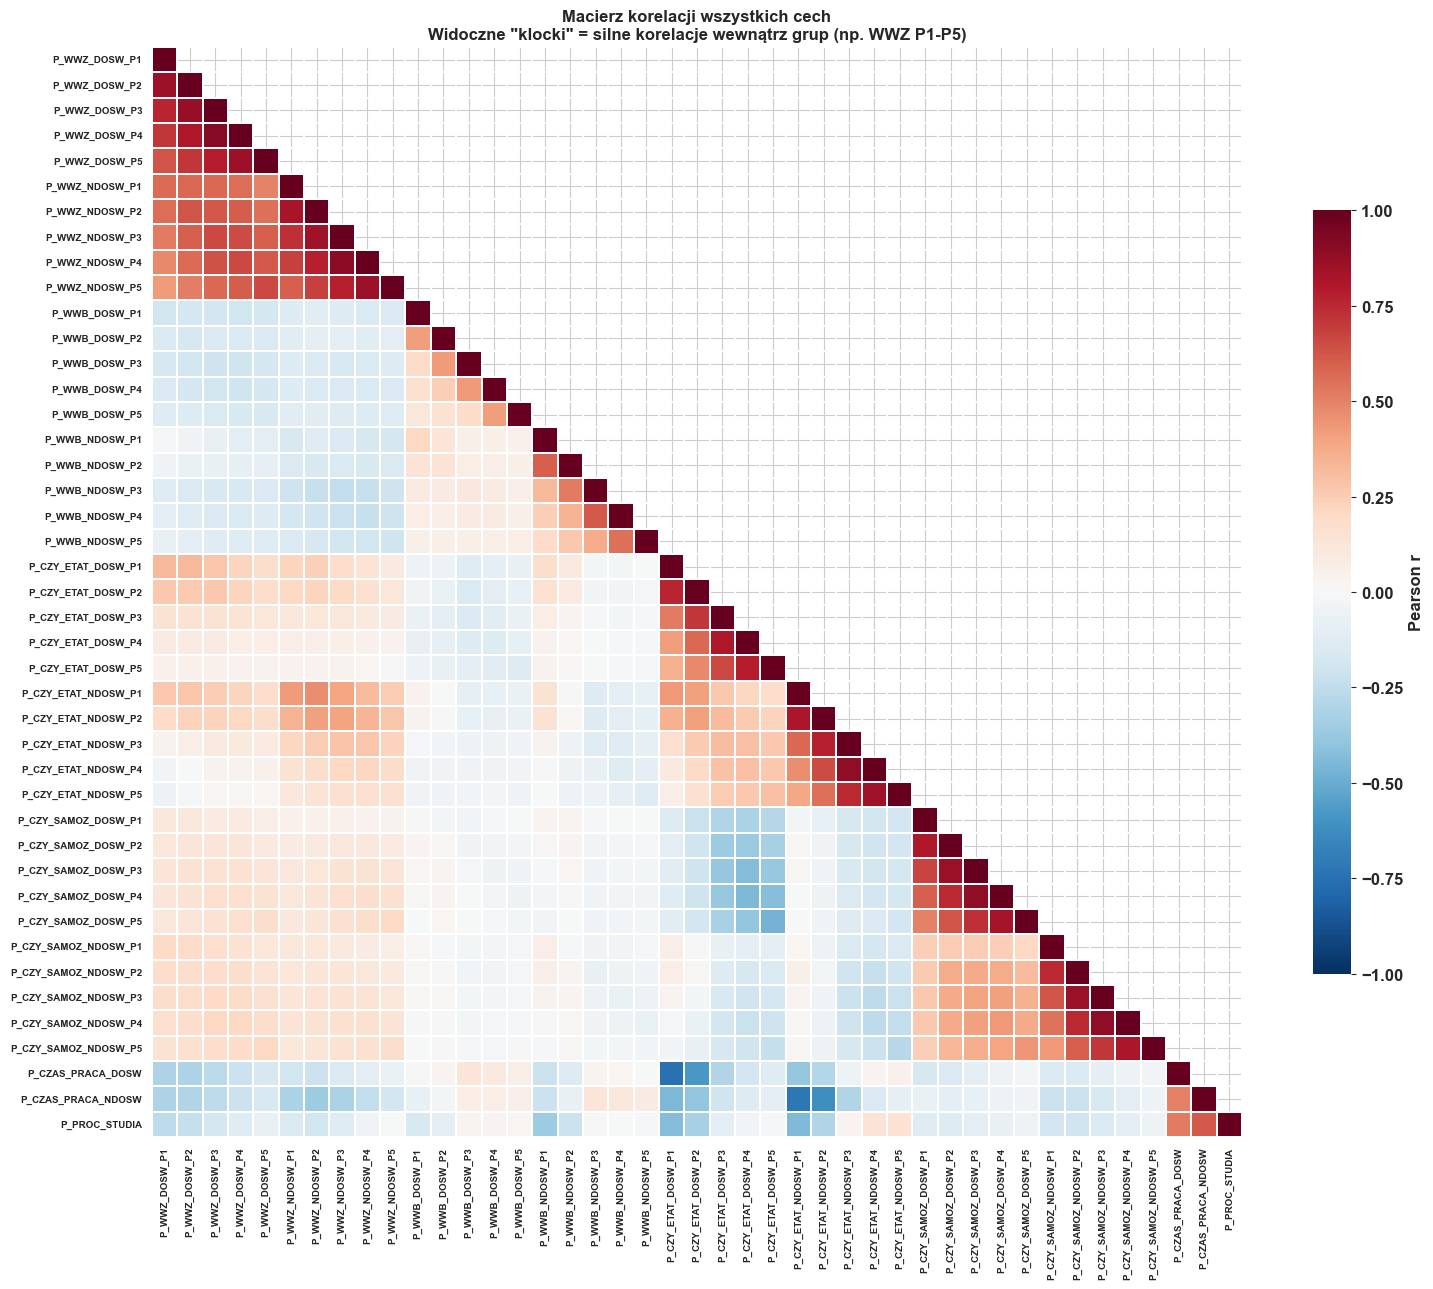


Średnia korelacja wewnątrz każdej grupy (im wyższa, tym bardziej redundantne cechy):
  WWZ DOSW (zarobki, z doświadczeniem)                ⟨r⟩ = 0.790
  WWZ NDOSW (zarobki, bez doświadczenia)              ⟨r⟩ = 0.767
  WWB DOSW (bezrobocie, z doświadczeniem)             ⟨r⟩ = 0.275
  WWB NDOSW (bezrobocie, bez doświadczenia)           ⟨r⟩ = 0.403
  ETAT DOSW (umowa o pracę, z dośw.)                  ⟨r⟩ = 0.609
  ETAT NDOSW (umowa o pracę, bez dośw.)               ⟨r⟩ = 0.670
  SAMOZ DOSW (samozatrudnienie, z dośw.)              ⟨r⟩ = 0.728
  SAMOZ NDOSW (samozatrudnienie, bez dośw.)           ⟨r⟩ = 0.700
  CZAS (m-ce do pierwszej pracy)                      ⟨r⟩ = 0.505


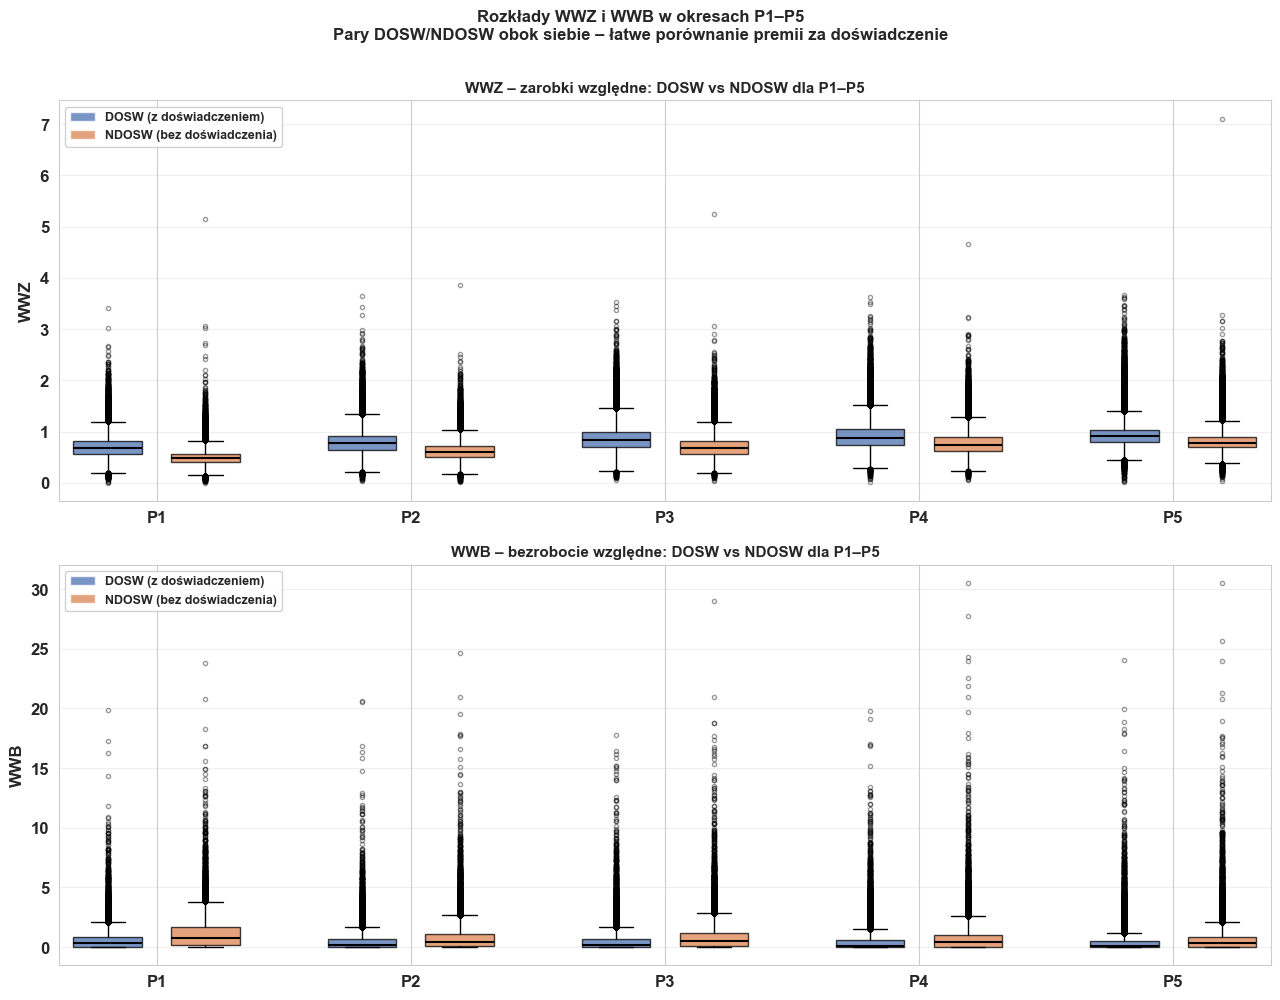

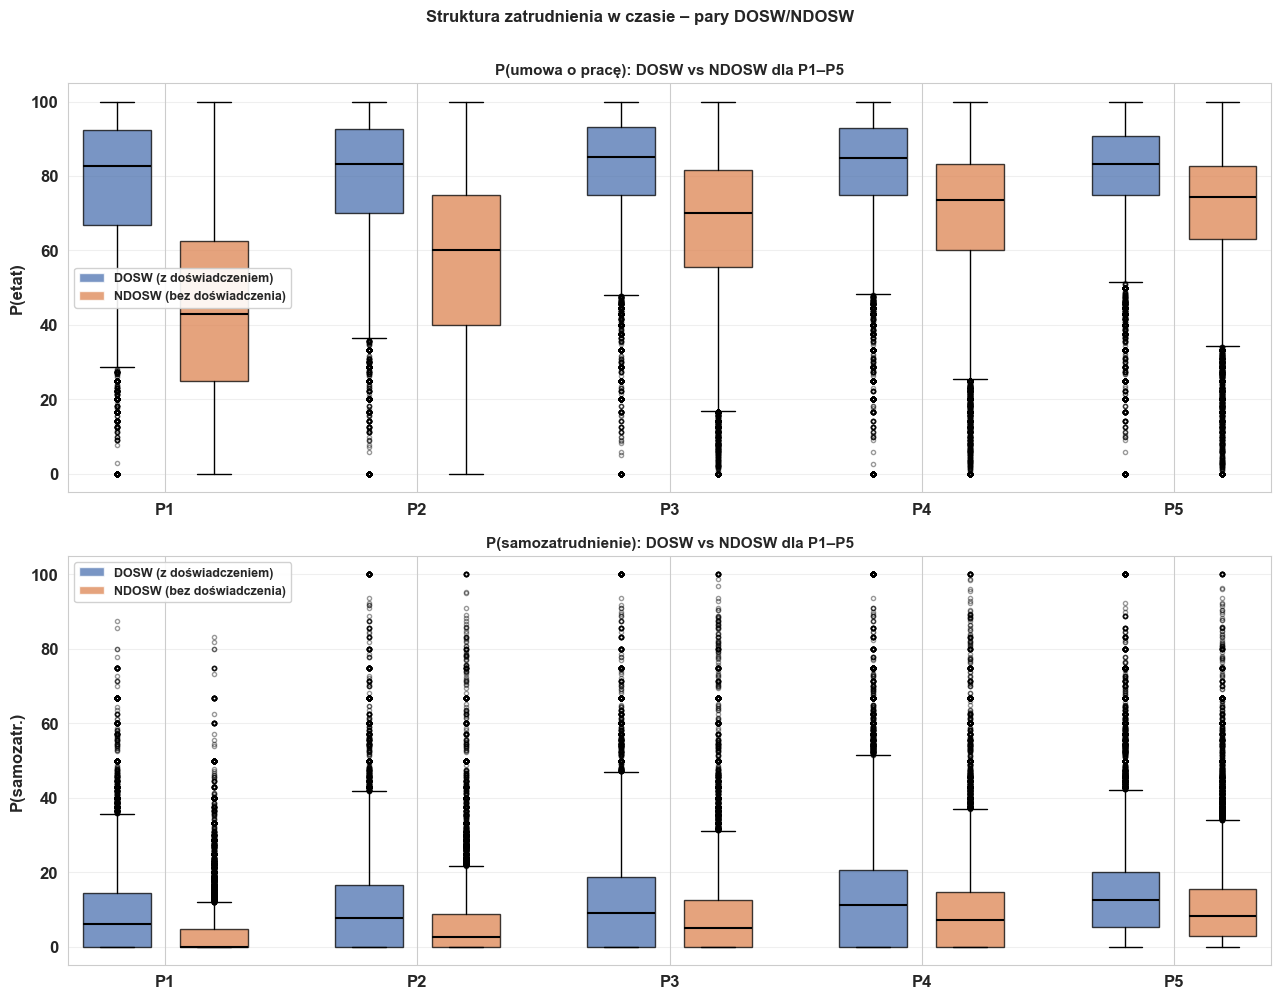

In [4]:
# ==========================================
# 4. EKSPLORACJA: KORELACJE I ROZKŁADY
# ==========================================
print("\n" + "="*70)
print("EKSPLORACYJNA ANALIZA DANYCH")
print("="*70)

# Macierz korelacji - duża, ale uporządkowana wg grup cech
fig, ax = plt.subplots(figsize=(16, 13))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.7, 'label': 'Pearson r'},
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
plt.title('Macierz korelacji wszystkich cech\n'
          'Widoczne "klocki" = silne korelacje wewnątrz grup (np. WWZ P1-P5)', fontsize=12)
plt.tight_layout()
plt.show()

# Statystyki opisowe per grupa - syntetyczna informacja
print("\nŚrednia korelacja wewnątrz każdej grupy (im wyższa, tym bardziej redundantne cechy):")
for name, cols in feature_groups.items():
    if len(cols) > 1:
        sub_corr = X[cols].corr().values
        avg_corr = sub_corr[np.triu_indices_from(sub_corr, k=1)].mean()
        print(f"  {name[:50]:50s}  ⟨r⟩ = {avg_corr:.3f}")

# ----- BOXPLOTY: DOSW vs NDOSW SĄSIADUJĄCO w obrębie każdego P -----
# Dla każdego okresu P1-P5 stawiamy obok siebie pudełka DOSW i NDOSW,
# żeby gołym okiem porównać premię za doświadczenie w każdym roku.
# Zachowujemy WSPÓLNĄ skalę Y w obrębie pary (WWZ na górze, WWB na dole).

def paired_boxplot(ax, cols_dosw, cols_ndosw, title, ylim, ylabel=''):
    """Rysuje pudełka DOSW i NDOSW na przemian: P1_DOSW, P1_NDOSW, P2_DOSW, P2_NDOSW, ..."""
    n_periods = min(len(cols_dosw), len(cols_ndosw))
    data, positions, colors, period_labels = [], [], [], []
    pos = 1
    for i in range(n_periods):
        # DOSW
        data.append(X[cols_dosw[i]].dropna().values)
        positions.append(pos)
        colors.append('#4C72B0')  # niebieski = DOSW
        pos += 1
        # NDOSW
        data.append(X[cols_ndosw[i]].dropna().values)
        positions.append(pos)
        colors.append('#DD8452')  # pomarańczowy = NDOSW
        pos += 1.6  # większy odstęp między okresami
        period_labels.append(f'P{i+1}')

    bp = ax.boxplot(data, positions=positions, widths=0.7, patch_artist=True,
                    medianprops=dict(color='black', linewidth=1.5),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    # Tickery: środek pary DOSW/NDOSW
    pair_centers = [(positions[2*i] + positions[2*i+1]) / 2 for i in range(n_periods)]
    ax.set_xticks(pair_centers)
    ax.set_xticklabels(period_labels)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    apply_ylim(ax, ylim)
    ax.grid(axis='y', alpha=0.3)

    # Legenda (raz)
    legend_handles = [
        Patch(facecolor='#4C72B0', alpha=0.75, label='DOSW (z doświadczeniem)'),
        Patch(facecolor='#DD8452', alpha=0.75, label='NDOSW (bez doświadczenia)'),
    ]
    ax.legend(handles=legend_handles, loc='best', fontsize=9, framealpha=0.9)


# Wspólne zakresy: WWZ vs WWZ, WWB vs WWB (odporne na NaN/inf)
wwz_ylim = safe_ylim(X[features_wwz_dosw], X[features_wwz_ndosw])
wwb_ylim = safe_ylim(X[features_wwb_dosw], X[features_wwb_ndosw])

fig, axes = plt.subplots(2, 1, figsize=(13, 10))
paired_boxplot(axes[0], features_wwz_dosw, features_wwz_ndosw,
               'WWZ – zarobki względne: DOSW vs NDOSW dla P1–P5',
               wwz_ylim, ylabel='WWZ')
paired_boxplot(axes[1], features_wwb_dosw, features_wwb_ndosw,
               'WWB – bezrobocie względne: DOSW vs NDOSW dla P1–P5',
               wwb_ylim, ylabel='WWB')
plt.suptitle('Rozkłady WWZ i WWB w okresach P1–P5\n'
             'Pary DOSW/NDOSW obok siebie – łatwe porównanie premii za doświadczenie',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

# Analogicznie dla nowych grup (etat, samozatrudnienie) - jeśli kolumny istnieją
if features_etat_dosw and features_etat_ndosw:
    etat_ylim_eda = safe_ylim(X[features_etat_dosw], X[features_etat_ndosw])
    samoz_ylim_eda = safe_ylim(X[features_samoz_dosw], X[features_samoz_ndosw]) \
                     if features_samoz_dosw and features_samoz_ndosw else None

    n_panels = 1 + int(bool(features_samoz_dosw and features_samoz_ndosw))
    fig, axes = plt.subplots(n_panels, 1, figsize=(13, 5*n_panels))
    if n_panels == 1:
        axes = [axes]
    paired_boxplot(axes[0], features_etat_dosw, features_etat_ndosw,
                   'P(umowa o pracę): DOSW vs NDOSW dla P1–P5',
                   etat_ylim_eda, ylabel='P(etat)')
    if n_panels == 2:
        paired_boxplot(axes[1], features_samoz_dosw, features_samoz_ndosw,
                       'P(samozatrudnienie): DOSW vs NDOSW dla P1–P5',
                       samoz_ylim_eda, ylabel='P(samozatr.)')
    plt.suptitle('Struktura zatrudnienia w czasie – pary DOSW/NDOSW',
                 fontsize=12, y=1.00)
    plt.tight_layout()
    plt.show()



DETEKCJA WARTOŚCI ODSTAJĄCYCH (Isolation Forest)
Wykryto 1859 kierunków odstających (5.0%)


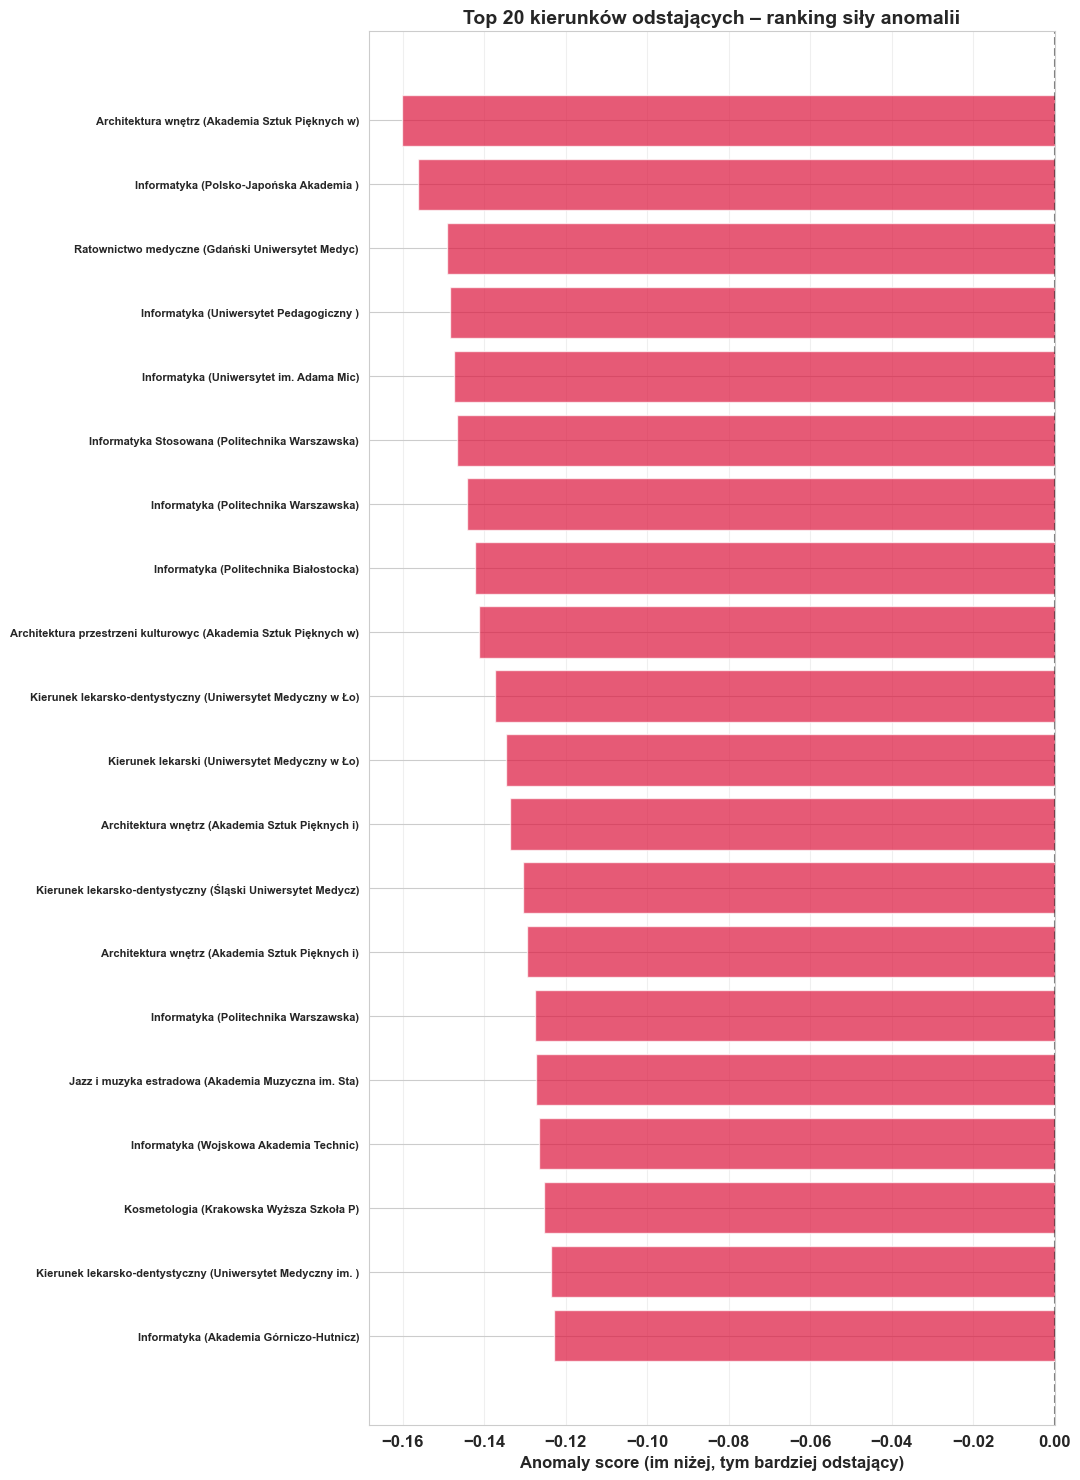

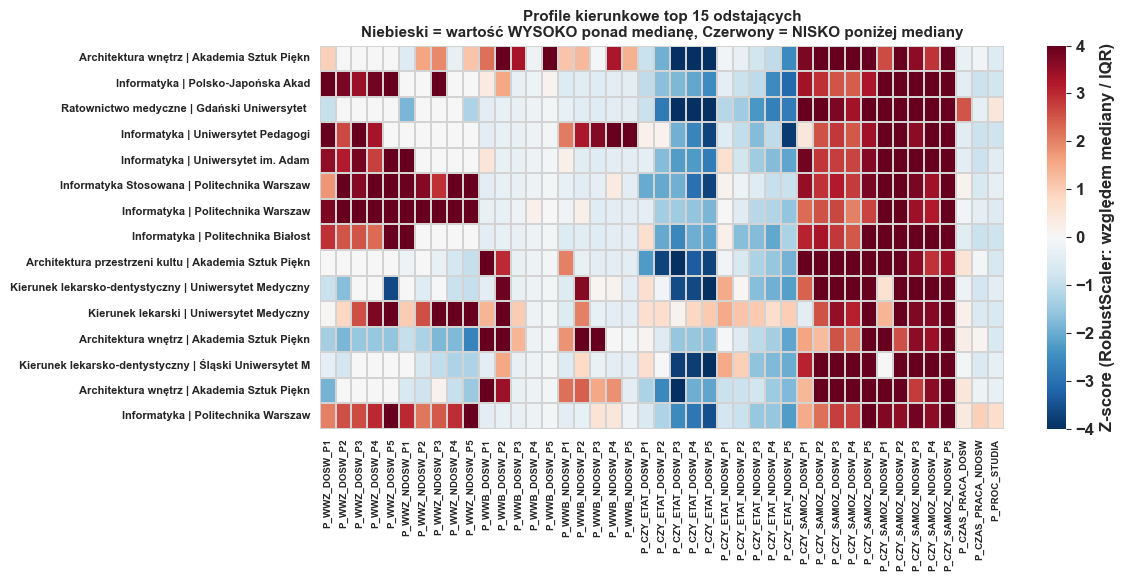


----------------------------------------------------------------------
ANALIZA KIERUNKOWA – co konkretnie odstaje u każdego z 10 najbardziej dziwnych?
----------------------------------------------------------------------

► Architektura wnętrz  |  Akademia Sztuk Pięknych w Warszawie
  Dziedzina: Dziedzina sztuki  |  anomaly score: -0.160
  NISKO (poniżej mediany populacji):
    P_CZY_ETAT_DOSW_P5              z = -5.27   raw = 0.000
    P_CZY_ETAT_DOSW_P4              z = -4.74   raw = 0.000
    P_CZY_ETAT_DOSW_P3              z = -4.70   raw = 0.000
    P_CZY_ETAT_NDOSW_P5             z = -2.55   raw = 25.000
  WYSOKO (powyżej mediany populacji):
    P_WWB_DOSW_P5                   z = +13.98   raw = 6.620
    P_CZY_SAMOZ_DOSW_P3             z = +4.84   raw = 100.000
    P_WWB_DOSW_P2                   z = +4.61   raw = 3.250
    P_CZY_SAMOZ_DOSW_P5             z = +4.56   raw = 80.000
    P_CZY_SAMOZ_NDOSW_P5            z = +4.36   raw = 62.500

► Informatyka  |  Polsko-Japońska Ak

In [5]:
# ==========================================
# 5. DETEKCJA WARTOŚCI ODSTAJĄCYCH – Z KIERUNKIEM I DIAGNOZĄ
# ==========================================
print("\n" + "="*70)
print("DETEKCJA WARTOŚCI ODSTAJĄCYCH (Isolation Forest)")
print("="*70)

X_robust = RobustScaler().fit_transform(X)
iso = IsolationForest(contamination=0.05, random_state=42)
df_analiza['outlier'] = iso.fit_predict(X_robust)
# anomaly score: im niżej (bardziej ujemnie) tym bardziej odstający
df_analiza['outlier_score'] = iso.decision_function(X_robust)

n_outliers = (df_analiza['outlier'] == -1).sum()
print(f"Wykryto {n_outliers} kierunków odstających "
      f"({n_outliers/len(df_analiza)*100:.1f}%)")

# ----- KIERUNKOWOŚĆ ODSTAJANIA -----
# Dla każdego odstającego wiersza liczymy z-score względem mediany populacji
# (RobustScaler już to skaluje przez IQR). Wartości |z|>2 to faktyczne odstępstwa.
# Pokazujemy CO JEST WYSOKIE, a CO NISKIE - kluczowa wskazówka interpretacyjna.

X_robust_df = pd.DataFrame(X_robust, columns=features, index=df_analiza.index)

outlier_mask = df_analiza['outlier'] == -1
outliers_idx = df_analiza[outlier_mask].index

# Sortujemy odstające od "najdziwniejszych" (najniższy outlier_score)
outliers_sorted = df_analiza.loc[outliers_idx].sort_values('outlier_score')

# ----- WYKRES 1: ranking odstających + ich anomaly score -----
fig, ax = plt.subplots(figsize=(11, max(5, min(15, n_outliers * 0.35))))
top_n_plot = min(20, n_outliers)
top_outliers = outliers_sorted.head(top_n_plot)
labels = [f"{row['P_KIERUNEK_NAZWA'][:35]} ({row['P_NAZWA_UCZELNI'][:25]})"
          for _, row in top_outliers.iterrows()]
y_pos = np.arange(len(labels))
ax.barh(y_pos, top_outliers['outlier_score'].values, color='crimson', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Anomaly score (im niżej, tym bardziej odstający)')
ax.set_title(f'Top {top_n_plot} kierunków odstających – ranking siły anomalii')
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ----- WYKRES 2: heatmapa kierunkowości - które cechy odstają WYSOKO, które NISKO -----
# Dla top 15 odstających rysujemy ich profil z-score
top_n_heatmap = min(15, n_outliers)
top_outliers_heat = outliers_sorted.head(top_n_heatmap)
heat_data = X_robust_df.loc[top_outliers_heat.index]
heat_labels = [f"{row['P_KIERUNEK_NAZWA'][:30]} | {row['P_NAZWA_UCZELNI'][:20]}"
               for _, row in top_outliers_heat.iterrows()]

fig, ax = plt.subplots(figsize=(max(12, len(features) * 0.28), max(6, top_n_heatmap * 0.4)))
sns.heatmap(heat_data.values, cmap='RdBu_r', center=0, vmin=-4, vmax=4,
            xticklabels=features, yticklabels=heat_labels,
            cbar_kws={'label': 'Z-score (RobustScaler: względem mediany / IQR)'},
            ax=ax, linewidths=0.3, linecolor='lightgray')
ax.set_title(f'Profile kierunkowe top {top_n_heatmap} odstających\n'
             'Niebieski = wartość WYSOKO ponad medianę, Czerwony = NISKO poniżej mediany',
             fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# ----- ANALIZA TEKSTOWA: w którą stronę i CO odstaje -----
print("\n" + "-"*70)
print("ANALIZA KIERUNKOWA – co konkretnie odstaje u każdego z 10 najbardziej dziwnych?")
print("-"*70)

Z_THRESHOLD = 2.0  # cechy z |z|>2 traktujemy jako rzeczywiście ekstremalne

for idx in outliers_sorted.head(10).index:
    row = df_analiza.loc[idx]
    z_scores = X_robust_df.loc[idx]
    extreme = z_scores[z_scores.abs() > Z_THRESHOLD].sort_values()
    if extreme.empty:
        # mimo flagi Isolation Forest, nic skrajnego pojedynczo - odstaje przez WIELOWYMIAROWĄ konfigurację
        extreme = z_scores.reindex(z_scores.abs().sort_values(ascending=False).index).head(5)
        marker = "  (brak ekstremalnych |z|>2 - odstaje przez nietypową KOMBINACJĘ cech)"
    else:
        marker = ""

    print(f"\n► {row['P_KIERUNEK_NAZWA']}  |  {row['P_NAZWA_UCZELNI']}")
    print(f"  Dziedzina: {row['P_DZIEDZINA']}  |  anomaly score: {row['outlier_score']:.3f}{marker}")

    low_feats = extreme[extreme < 0].sort_values().head(5)
    high_feats = extreme[extreme > 0].sort_values(ascending=False).head(5)

    if not low_feats.empty:
        print("  NISKO (poniżej mediany populacji):")
        for f, z in low_feats.items():
            raw_val = df_analiza.loc[idx, f]
            print(f"    {f:30s}  z = {z:+.2f}   raw = {raw_val:.3f}")
    if not high_feats.empty:
        print("  WYSOKO (powyżej mediany populacji):")
        for f, z in high_feats.items():
            raw_val = df_analiza.loc[idx, f]
            print(f"    {f:30s}  z = {z:+.2f}   raw = {raw_val:.3f}")

# ----- PODSUMOWANIE: które cechy najczęściej napędzają odstawanie? -----
print("\n" + "-"*70)
print("Które cechy najczęściej powodują odstawanie? (jak często |z|>2 wśród outlierów)")
print("-"*70)
outlier_z = X_robust_df.loc[outliers_idx].abs()
extreme_counts = (outlier_z > Z_THRESHOLD).sum().sort_values(ascending=False)
extreme_pct = (extreme_counts / n_outliers * 100).round(1)
direction_summary = []
for feat in extreme_counts.head(15).index:
    z_vals = X_robust_df.loc[outliers_idx, feat]
    n_high = (z_vals > Z_THRESHOLD).sum()
    n_low = (z_vals < -Z_THRESHOLD).sum()
    direction_summary.append({
        'Cecha': feat,
        '% outlierów ekstremalnych w tej cesze': extreme_pct[feat],
        'Liczba WYSOKO': n_high,
        'Liczba NISKO': n_low,
        'Dominujący kierunek': 'WYSOKO' if n_high > n_low else ('NISKO' if n_low > n_high else 'mieszany'),
    })
direction_df = pd.DataFrame(direction_summary)
print(direction_df.to_string(index=False))


In [6]:
# ==========================================
# 6. STANDARYZACJA
# ==========================================
scaler = SS()
X_scaled = scaler.fit_transform(X)


ANALIZA SKŁADOWYCH GŁÓWNYCH (PCA)
Pytanie: skąd bierze się wariancja w danych?


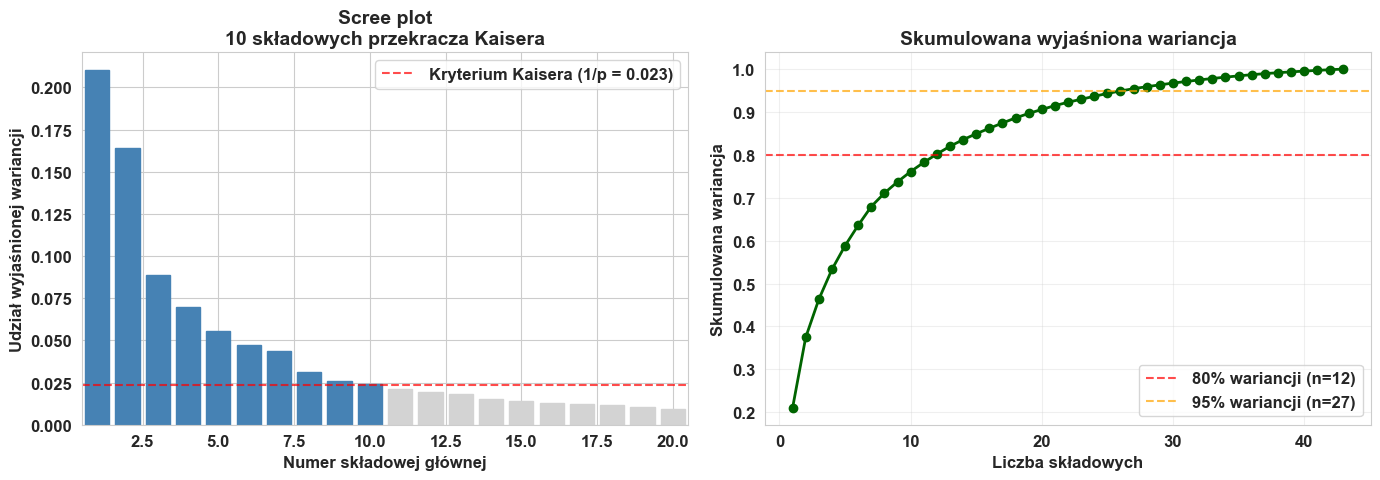

Składowych powyżej kryterium Kaisera:     10
Składowych dla 80% wariancji:             12
Składowych dla 95% wariancji:             27
Pierwsze 2 składowe wyjaśniają:           37.5% wariancji
Pierwsze 10 składowych wyjaśnia:           76.1% wariancji


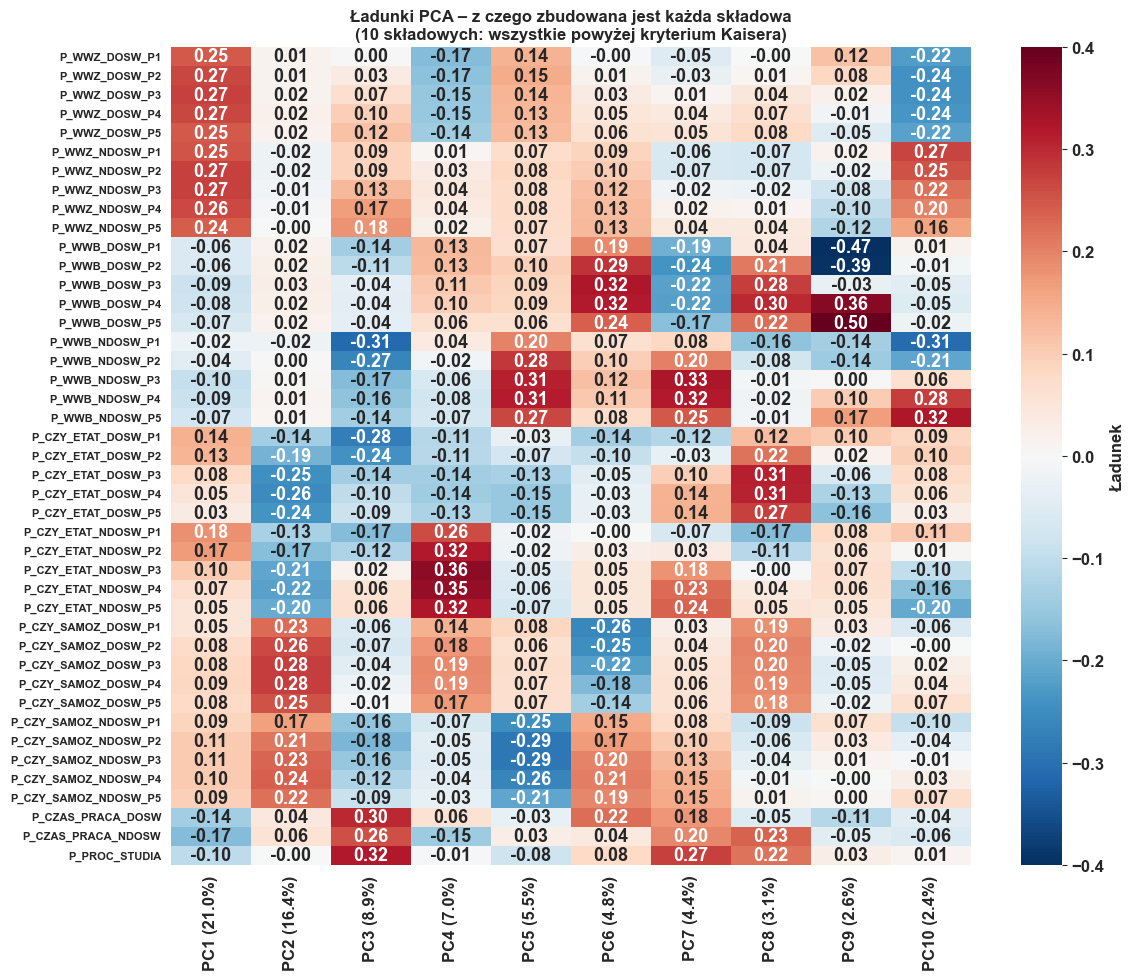


--- INTERPRETACJA SKŁADOWYCH ---
Dla każdej PC: top 3 cechy o największej wartości bezwzględnej ładunku
(znak pokazuje kierunek: + i - oznaczają biegunowe końce składowej)

PC1 (21.0% wariancji)
  Biegun (+): {'P_WWZ_NDOSW_P3': np.float64(0.275), 'P_WWZ_DOSW_P3': np.float64(0.274), 'P_WWZ_NDOSW_P2': np.float64(0.272)}
  Biegun (-): {'P_CZAS_PRACA_NDOSW': np.float64(-0.174), 'P_CZAS_PRACA_DOSW': np.float64(-0.138), 'P_PROC_STUDIA': np.float64(-0.105)}

PC2 (16.4% wariancji)
  Biegun (+): {'P_CZY_SAMOZ_DOSW_P4': np.float64(0.277), 'P_CZY_SAMOZ_DOSW_P3': np.float64(0.276), 'P_CZY_SAMOZ_DOSW_P2': np.float64(0.263)}
  Biegun (-): {'P_CZY_ETAT_DOSW_P4': np.float64(-0.256), 'P_CZY_ETAT_DOSW_P3': np.float64(-0.246), 'P_CZY_ETAT_DOSW_P5': np.float64(-0.24)}

PC3 (8.9% wariancji)
  Biegun (+): {'P_PROC_STUDIA': np.float64(0.319), 'P_CZAS_PRACA_DOSW': np.float64(0.3), 'P_CZAS_PRACA_NDOSW': np.float64(0.258)}
  Biegun (-): {'P_WWB_NDOSW_P1': np.float64(-0.31), 'P_CZY_ETAT_DOSW_P1': np.float64(-0.

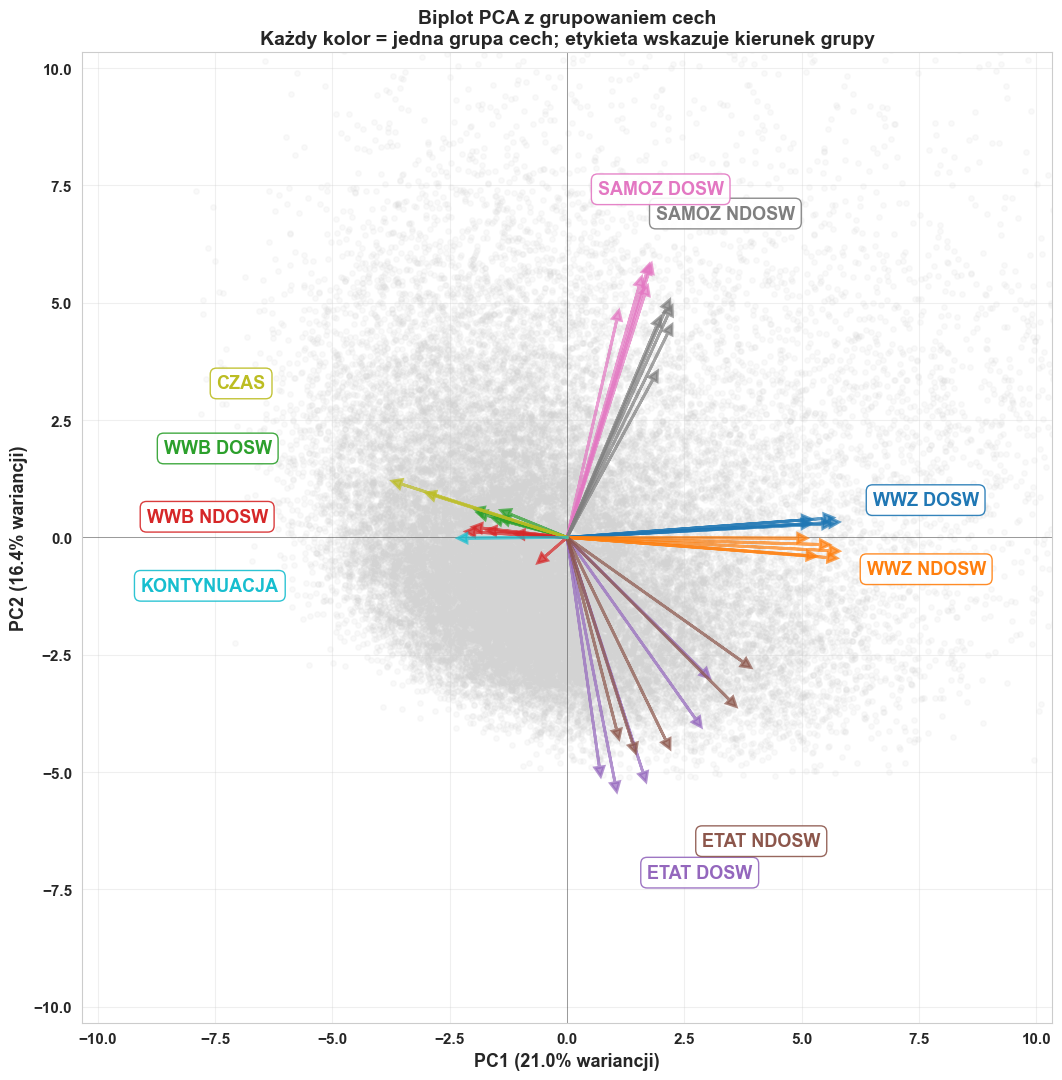

In [7]:
# ==========================================
# 7. PCA – ANALIZA: SKĄD BIERZE SIĘ WARIANCJA?
# ==========================================
print("\n" + "="*70)
print("ANALIZA SKŁADOWYCH GŁÓWNYCH (PCA)")
print("Pytanie: skąd bierze się wariancja w danych?")
print("="*70)

pca_full = PCA().fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Liczba PCs powyżej Kaisera (wariancja > 1/p) - dla danych standaryzowanych odpowiada eigenvalue > 1
kaiser_threshold = 1.0 / len(features)
n_kaiser = int((pca_full.explained_variance_ratio_ > kaiser_threshold).sum())
n_pc_80 = int(np.argmax(cumvar >= 0.80) + 1)
n_pc_95 = int(np.argmax(cumvar >= 0.95) + 1)

# Scree plot + skumulowana wariancja
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
bars = ax1.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
               pca_full.explained_variance_ratio_, edgecolor='black')
# wyróżnij PCi powyżej Kaisera
for i, bar in enumerate(bars):
    bar.set_color('steelblue' if pca_full.explained_variance_ratio_[i] > kaiser_threshold else 'lightgray')
ax1.axhline(y=kaiser_threshold, color='red', linestyle='--', alpha=0.7,
            label=f'Kryterium Kaisera (1/p = {kaiser_threshold:.3f})')
ax1.set_xlabel('Numer składowej głównej')
ax1.set_ylabel('Udział wyjaśnionej wariancji')
ax1.set_title(f'Scree plot\n{n_kaiser} składowych przekracza Kaisera')
ax1.legend()
ax1.set_xlim(0.5, min(20, len(pca_full.explained_variance_ratio_)) + 0.5)

ax2.plot(range(1, len(cumvar) + 1), cumvar, marker='o', color='darkgreen', linewidth=2)
ax2.axhline(y=0.80, color='red', linestyle='--', alpha=0.7, label=f'80% wariancji (n={n_pc_80})')
ax2.axhline(y=0.95, color='orange', linestyle='--', alpha=0.7, label=f'95% wariancji (n={n_pc_95})')
ax2.set_xlabel('Liczba składowych')
ax2.set_ylabel('Skumulowana wariancja')
ax2.set_title('Skumulowana wyjaśniona wariancja')
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Składowych powyżej kryterium Kaisera:     {n_kaiser}")
print(f"Składowych dla 80% wariancji:             {n_pc_80}")
print(f"Składowych dla 95% wariancji:             {n_pc_95}")
print(f"Pierwsze 2 składowe wyjaśniają:           {cumvar[1]*100:.1f}% wariancji")
print(f"Pierwsze {n_kaiser} składowych wyjaśnia:           {cumvar[n_kaiser-1]*100:.1f}% wariancji")

# ----- ŁADUNKI dla wszystkich składowych powyżej Kaisera -----
# To jest źródło odpowiedzi na pytanie "skąd bierze się wariancja"
n_components_show = max(5, n_kaiser)  # pokażemy co najmniej 5, lub tyle ile powyżej Kaisera
loadings = pd.DataFrame(
    pca_full.components_[:n_components_show].T,
    columns=[f'PC{i+1} ({pca_full.explained_variance_ratio_[i]*100:.1f}%)'
             for i in range(n_components_show)],
    index=features
)

# Heatmapa ładunków z grupowaniem cech po lewej stronie
fig, ax = plt.subplots(figsize=(12, max(10, len(features) * 0.22)))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Ładunek'}, vmin=-0.4, vmax=0.4, ax=ax,
            yticklabels=True)
ax.set_title(f'Ładunki PCA – z czego zbudowana jest każda składowa\n'
             f'({n_components_show} składowych: wszystkie powyżej kryterium Kaisera)', fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
plt.tight_layout()
plt.show()

# Wypisz interpretację każdej składowej powyżej Kaisera
print("\n--- INTERPRETACJA SKŁADOWYCH ---")
print("Dla każdej PC: top 3 cechy o największej wartości bezwzględnej ładunku")
print("(znak pokazuje kierunek: + i - oznaczają biegunowe końce składowej)\n")
for i in range(n_components_show):
    pc_loadings = loadings.iloc[:, i]
    top_pos = pc_loadings.nlargest(3)
    top_neg = pc_loadings.nsmallest(3)
    print(f"PC{i+1} ({pca_full.explained_variance_ratio_[i]*100:.1f}% wariancji)")
    print(f"  Biegun (+): {dict(top_pos.round(3))}")
    print(f"  Biegun (-): {dict(top_neg.round(3))}")
    print()

# ----- BIPLOT z grupowaniem kolorystycznym (wersja czytelna) -----
pca_2d = PCA(n_components=2)
X_pca2 = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(15, 11))

# Tło: obserwacje
ax.scatter(X_pca2[:, 0], X_pca2[:, 1], alpha=0.12, s=15, color='lightgray', zorder=1)

# --- 1. Przycinamy widok do 1-99 percentyla obserwacji (outliery poza kadrem) ---
x_lo, x_hi = np.percentile(X_pca2[:, 0], [1, 99])
y_lo, y_hi = np.percentile(X_pca2[:, 1], [1, 99])
half_range = max(abs(x_lo), abs(x_hi), abs(y_lo), abs(y_hi))

# --- 2. Skalujemy strzałki tak, by najdłuższa sięgała ~60% widoku ---
max_loading = max(
    np.sqrt(pca_2d.components_[0, idx]**2 + pca_2d.components_[1, idx]**2)
    for idx in range(len(features))
)
scale_arrow = 0.6 * half_range / max_loading

group_colors = sns.color_palette('tab10', n_colors=len(feature_groups))

# --- 3. Najpierw zbieramy pozycje etykiet, potem rozsuwamy kolizje ---
label_data = []  # (nazwa, kolor, kąt grupy)
for color, (group_name, group_features) in zip(group_colors, feature_groups.items()):
    indices = [features.index(f) for f in group_features if f in features]
    if not indices:
        continue
    xs, ys = [], []
    for idx in indices:
        x_arrow = pca_2d.components_[0, idx] * scale_arrow
        y_arrow = pca_2d.components_[1, idx] * scale_arrow
        ax.arrow(0, 0, x_arrow, y_arrow,
                 head_width=0.02 * half_range, head_length=0.02 * half_range,
                 fc=color, ec=color, alpha=0.7, linewidth=2.0, zorder=3)
        xs.append(x_arrow)
        ys.append(y_arrow)
    mean_x, mean_y = np.mean(xs), np.mean(ys)
    angle = np.arctan2(mean_y, mean_x)
    label_data.append([group_name.split(' (')[0], color, angle])

# Etykiety na stałym promieniu poza strzałkami, rozsuwane gdy kąty zbyt bliskie
label_radius = 0.78 * half_range
min_angle_gap = np.deg2rad(11)  # minimalny odstęp kątowy między etykietami
label_data.sort(key=lambda d: d[2])
for _ in range(50):  # kilka iteracji rozsuwania
    moved = False
    for i in range(len(label_data)):
        j = (i + 1) % len(label_data)
        gap = label_data[j][2] - label_data[i][2]
        if j == 0:
            gap += 2 * np.pi
        if gap < min_angle_gap:
            shift = (min_angle_gap - gap) / 2
            label_data[i][2] -= shift
            label_data[j][2] += shift
            moved = True
    if not moved:
        break

for short_label, color, angle in label_data:
    lx = label_radius * np.cos(angle)
    ly = label_radius * np.sin(angle)
    ax.annotate(short_label,
                xy=(lx, ly),
                fontsize=13, color=color, fontweight='bold',
                ha='center', va='center', zorder=4,
                bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                          edgecolor=color, alpha=0.9))

ax.axhline(y=0, color='black', linewidth=0.5, alpha=0.5)
ax.axvline(x=0, color='black', linewidth=0.5, alpha=0.5)
ax.set_xlim(-half_range * 1.05, half_range * 1.05)
ax.set_ylim(-half_range * 1.05, half_range * 1.05)
ax.set_aspect('equal')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% wariancji)', fontsize=13)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% wariancji)', fontsize=13)
ax.set_title('Biplot PCA z grupowaniem cech\n'
             'Każdy kolor = jedna grupa cech; etykieta wskazuje kierunek grupy',
             fontsize=14)
ax.tick_params(labelsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


WYZNACZANIE LICZBY KLASTRÓW – CZTERY NIEZALEŻNE METRYKI


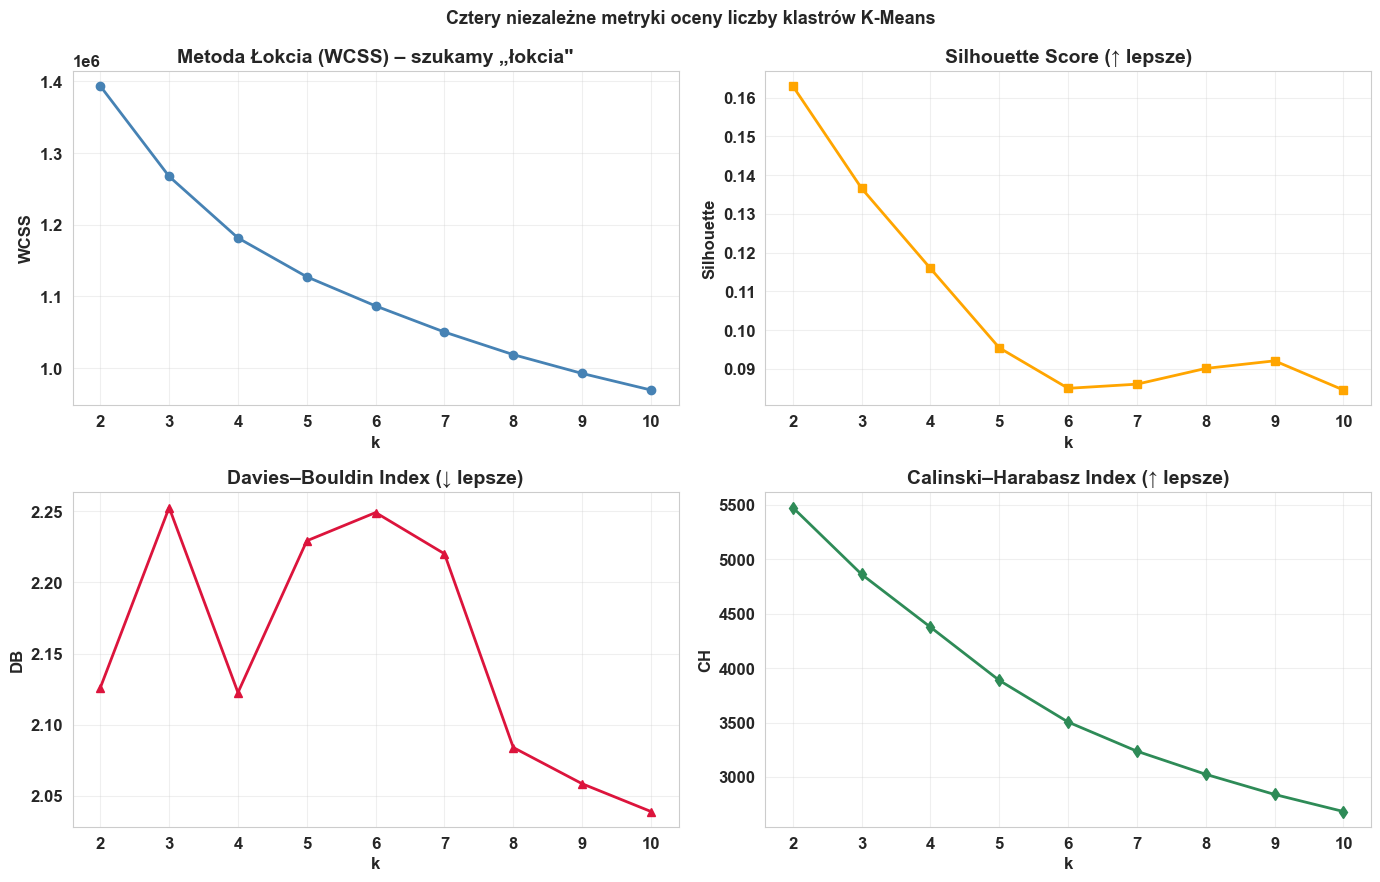

 k      WCSS  Silhouette (↑)  Davies-Bouldin (↓)  Calinski-Harabasz (↑)
 2 1393506.8           0.163               2.126                 5475.5
 3 1267308.3           0.137               2.253                 4861.3
 4 1181486.5           0.116               2.123                 4376.4
 5 1127275.1           0.095               2.229                 3887.0
 6 1086614.1           0.085               2.249                 3504.1
 7 1050183.4           0.086               2.220                 3236.2
 8 1018656.1           0.090               2.084                 3024.0
 9  992413.0           0.092               2.059                 2838.8
10  969280.4           0.085               2.039                 2682.1

Najlepsze k wg Silhouette:         2
Najlepsze k wg Davies-Bouldin:     10
Najlepsze k wg Calinski-Harabasz:  2

--- GŁOSOWANIE METRYK ---
  Silhouette           → k = 2  ← rekomendacja
  Davies-Bouldin       → k = 10
  Calinski-Harabasz    → k = 2  ← rekomendacja

Majority vote

In [8]:
# ==========================================
# 8. WYZNACZANIE LICZBY KLASTRÓW – CZTERY METRYKI
# ==========================================
print("\n" + "="*70)
print("WYZNACZANIE LICZBY KLASTRÓW – CZTERY NIEZALEŻNE METRYKI")
print("="*70)

K_range = range(2, 11)
wcss, silhouette_scores, davies_bouldin, calinski_harabasz = [], [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels_k))
    davies_bouldin.append(davies_bouldin_score(X_scaled, labels_k))
    calinski_harabasz.append(calinski_harabasz_score(X_scaled, labels_k))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(K_range, wcss, marker='o', color='steelblue', linewidth=2)
axes[0, 0].set_title('Metoda Łokcia (WCSS) – szukamy „łokcia"')
axes[0, 0].set_xlabel('k'); axes[0, 0].set_ylabel('WCSS'); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(K_range, silhouette_scores, marker='s', color='orange', linewidth=2)
axes[0, 1].set_title('Silhouette Score (↑ lepsze)')
axes[0, 1].set_xlabel('k'); axes[0, 1].set_ylabel('Silhouette'); axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(K_range, davies_bouldin, marker='^', color='crimson', linewidth=2)
axes[1, 0].set_title('Davies–Bouldin Index (↓ lepsze)')
axes[1, 0].set_xlabel('k'); axes[1, 0].set_ylabel('DB'); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(K_range, calinski_harabasz, marker='d', color='seagreen', linewidth=2)
axes[1, 1].set_title('Calinski–Harabasz Index (↑ lepsze)')
axes[1, 1].set_xlabel('k'); axes[1, 1].set_ylabel('CH'); axes[1, 1].grid(alpha=0.3)

plt.suptitle('Cztery niezależne metryki oceny liczby klastrów K-Means', fontsize=13)
plt.tight_layout()
plt.show()

results_k = pd.DataFrame({
    'k': list(K_range),
    'WCSS': np.round(wcss, 1),
    'Silhouette (↑)': np.round(silhouette_scores, 3),
    'Davies-Bouldin (↓)': np.round(davies_bouldin, 3),
    'Calinski-Harabasz (↑)': np.round(calinski_harabasz, 1),
})
print(results_k.to_string(index=False))

best_k_sil = list(K_range)[int(np.argmax(silhouette_scores))]
best_k_db = list(K_range)[int(np.argmin(davies_bouldin))]
best_k_ch = list(K_range)[int(np.argmax(calinski_harabasz))]
print(f"\nNajlepsze k wg Silhouette:         {best_k_sil}")
print(f"Najlepsze k wg Davies-Bouldin:     {best_k_db}")
print(f"Najlepsze k wg Calinski-Harabasz:  {best_k_ch}")

# ----- GŁOSOWANIE METRYK -----
# Każda metryka mierzy coś innego; bierzemy "głos większości".
# Uwaga: DB i CH są systematycznie obciążone w stronę małej liczby klastrów,
# więc gdy wskazują k=2, najczęściej oznacza to silną DYCHOTOMIĘ w danych
# (jedną dominującą oś podziału), a nie brak dalszej, drobniejszej struktury.
from collections import Counter
metric_votes = {
    'Silhouette':         best_k_sil,
    'Davies-Bouldin':     best_k_db,
    'Calinski-Harabasz':  best_k_ch,
}
vote_counts = Counter(metric_votes.values())
recommended_k, n_votes = vote_counts.most_common(1)[0]

print("\n--- GŁOSOWANIE METRYK ---")
for metric, k in metric_votes.items():
    mark = "  ← rekomendacja" if k == recommended_k else ""
    print(f"  {metric:20s} → k = {k}{mark}")
print(f"\nMajority vote: k = {recommended_k} ({n_votes}/{len(metric_votes)} metryk)")

print("\nINTERPRETACJA:")
if n_votes >= 2 and recommended_k == 2:
    print(f"  k=2 wybrane przez {n_votes}/3 metryki → w danych dominuje pojedyncza,")
    print("  silna oś podziału: kierunki dobrego vs trudnego startu na rynku pracy.")
    print("  Sub-struktury wewnątrz obu grup bada porównanie k=2/4/5 w sekcji 11b.")
elif n_votes < 2:
    print("  Metryki się nie zgadzają - struktura klastrów jest niejednoznaczna;")
    print("  o wyborze k decyduje interpretowalność profili i dendrogram (sekcja 10).")


PORÓWNANIE KLASTERYZACJI: PRZESTRZEŃ ORYGINALNA vs PCA (n=10)


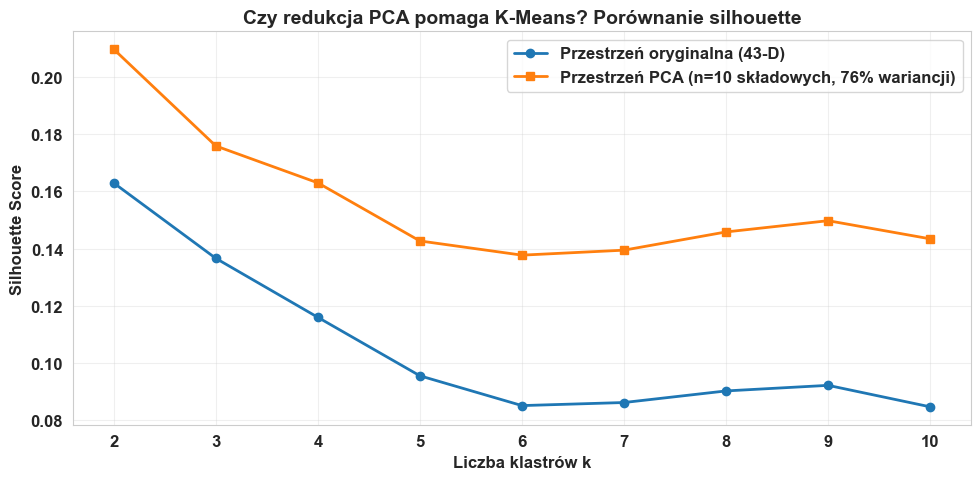

Wniosek: jeśli silhouette w przestrzeni PCA jest wyższy, to PC-y > Kaiser zawierają
sygnał, a pozostałe wymiary były szumem.



In [9]:
# ==========================================
# 9. KLASTRY W PRZESTRZENI PCA (n=Kaiser) vs PRZESTRZENI ORYGINALNEJ
# ==========================================
# Składowych powyżej progu Kaisera jest więcej niż 2, więc klasteryzację warto prowadzić
# w przestrzeni PCA o n_kaiser wymiarach: odcina szumowe wymiary i często daje
# stabilniejsze klastry niż pełna przestrzeń cech.
print("\n" + "="*70)
print(f"PORÓWNANIE KLASTERYZACJI: PRZESTRZEŃ ORYGINALNA vs PCA (n={n_kaiser})")
print("="*70)

pca_kaiser = PCA(n_components=n_kaiser)
X_pca_reduced = pca_kaiser.fit_transform(X_scaled)

sil_orig, sil_pca = [], []
for k in K_range:
    km_orig = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    km_pca = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pca_reduced)
    sil_orig.append(silhouette_score(X_scaled, km_orig.labels_))
    sil_pca.append(silhouette_score(X_pca_reduced, km_pca.labels_))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, sil_orig, marker='o', label=f'Przestrzeń oryginalna ({len(features)}-D)', linewidth=2)
ax.plot(K_range, sil_pca, marker='s',
        label=f'Przestrzeń PCA (n={n_kaiser} składowych, {cumvar[n_kaiser-1]*100:.0f}% wariancji)',
        linewidth=2)
ax.set_xlabel('Liczba klastrów k')
ax.set_ylabel('Silhouette Score')
ax.set_title('Czy redukcja PCA pomaga K-Means? Porównanie silhouette')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Wniosek: jeśli silhouette w przestrzeni PCA jest wyższy, to PC-y > Kaiser zawierają")
print("sygnał, a pozostałe wymiary były szumem.\n")

KLASTROWANIE HIERARCHICZNE (Ward) – DENDROGRAM


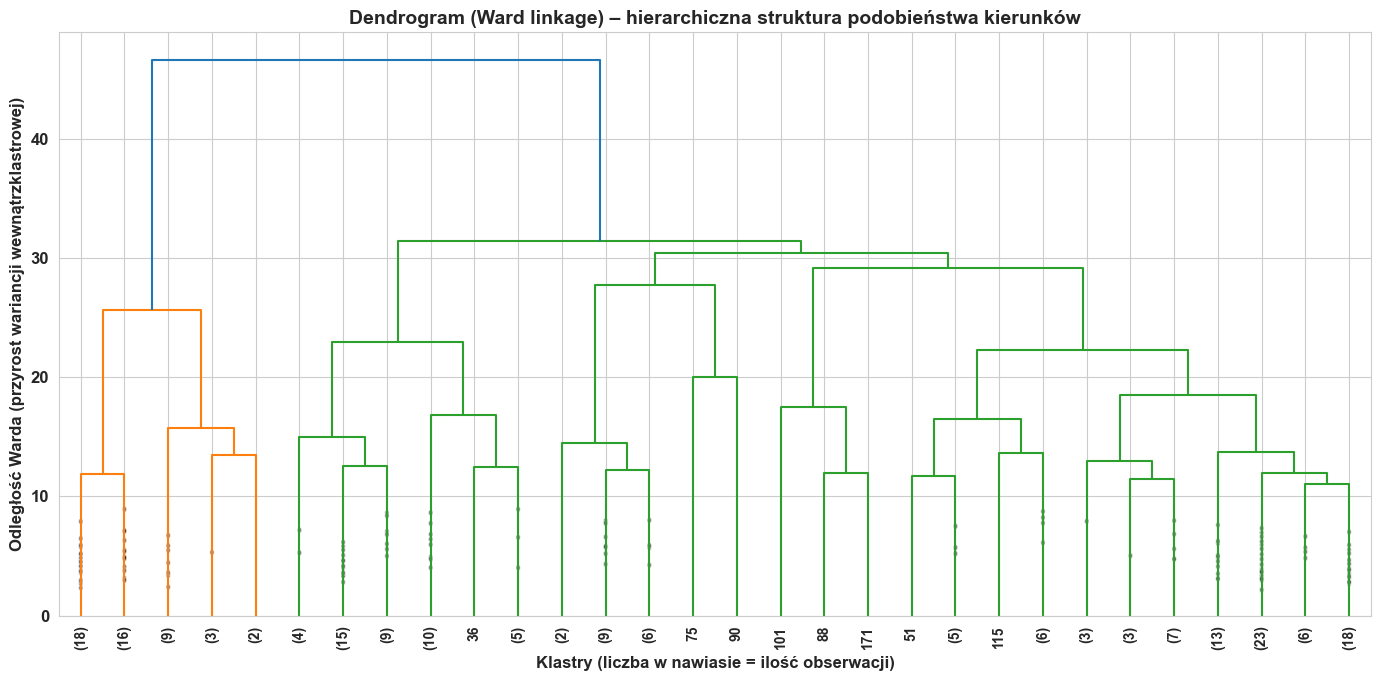

In [10]:
# ==========================================
# 10. KLASTROWANIE HIERARCHICZNE – DENDROGRAM
# ==========================================
print("="*70)
print("KLASTROWANIE HIERARCHICZNE (Ward) – DENDROGRAM")
print("="*70)

if len(X_scaled) > 200:
    sample_idx = np.random.RandomState(42).choice(len(X_scaled), 200, replace=False)
    X_dendro = X_scaled[sample_idx]
else:
    X_dendro = X_scaled

Z = linkage(X_dendro, method='ward')
fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10,
           show_contracted=True, ax=ax)
ax.set_title('Dendrogram (Ward linkage) – hierarchiczna struktura podobieństwa kierunków')
ax.set_xlabel('Klastry (liczba w nawiasie = ilość obserwacji)')
ax.set_ylabel('Odległość Warda (przyrost wariancji wewnątrzklastrowej)')
plt.tight_layout()
plt.show()

In [11]:
# ==========================================
# 11. FINALNY MODEL + PORÓWNANIE 3 METOD
# ==========================================
# Punkt wyjścia: k z głosowania metryk (sekcja 8). Drobniejsze podziały (k=4, k=5)
# porównują sekcje 11b-11c i tam zapada finalna decyzja o k.
docelowe_k = recommended_k
print(f"\nGłówna analiza: k = {docelowe_k}  (z głosowania metryk)")

# Decyzja: trenujemy K-Means na przestrzeni PCA (n_kaiser) - to zalecane,
# bo używamy tylko prawdziwego sygnału. Pozostałe metody dla porównania.
kmeans_final = KMeans(n_clusters=docelowe_k, random_state=42, n_init=10)
df_analiza['KlasterKMeans_PCA']  = kmeans_final.fit_predict(X_pca_reduced)

kmeans_orig = KMeans(n_clusters=docelowe_k, random_state=42, n_init=10)
df_analiza['KlasterKMeans_orig'] = kmeans_orig.fit_predict(X_scaled)

agg = AgglomerativeClustering(n_clusters=docelowe_k, linkage='ward')
df_analiza['Klaster_Hier'] = agg.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=docelowe_k, random_state=42, n_init=5)
df_analiza['Klaster_GMM'] = gmm.fit_predict(X_scaled)


print("\nZgodność metod (Adjusted Rand Index, 1 = identyczne, 0 = losowe):")
print(f"  KMeans-PCA vs KMeans-orig: {adjusted_rand_score(df_analiza['KlasterKMeans_PCA'], df_analiza['KlasterKMeans_orig']):.3f}")
print(f"  KMeans-PCA vs Hierarchical: {adjusted_rand_score(df_analiza['KlasterKMeans_PCA'], df_analiza['Klaster_Hier']):.3f}")
print(f"  KMeans-PCA vs GMM:          {adjusted_rand_score(df_analiza['KlasterKMeans_PCA'], df_analiza['Klaster_GMM']):.3f}")
print(f"  Hierarchical vs GMM:        {adjusted_rand_score(df_analiza['Klaster_Hier'], df_analiza['Klaster_GMM']):.3f}")

# Bazowy klaster do dalszej analizy: KMeans na PCA-reduced
df_analiza['Klaster'] = df_analiza['KlasterKMeans_PCA']



Główna analiza: k = 2  (z głosowania metryk)

Zgodność metod (Adjusted Rand Index, 1 = identyczne, 0 = losowe):
  KMeans-PCA vs KMeans-orig: 0.987
  KMeans-PCA vs Hierarchical: 0.443
  KMeans-PCA vs GMM:          -0.002
  Hierarchical vs GMM:        0.011


Silhouette (przestrzeń PCA):
  k=2 → 0.210
  k=4 → 0.163
  k=5 → 0.143
Spadek silhouette przy większym k jest normalny: dane są kontinuum, nie odseparowane wyspy.

Liczę t-SNE (chwilę zajmie)...
Liczę UMAP...


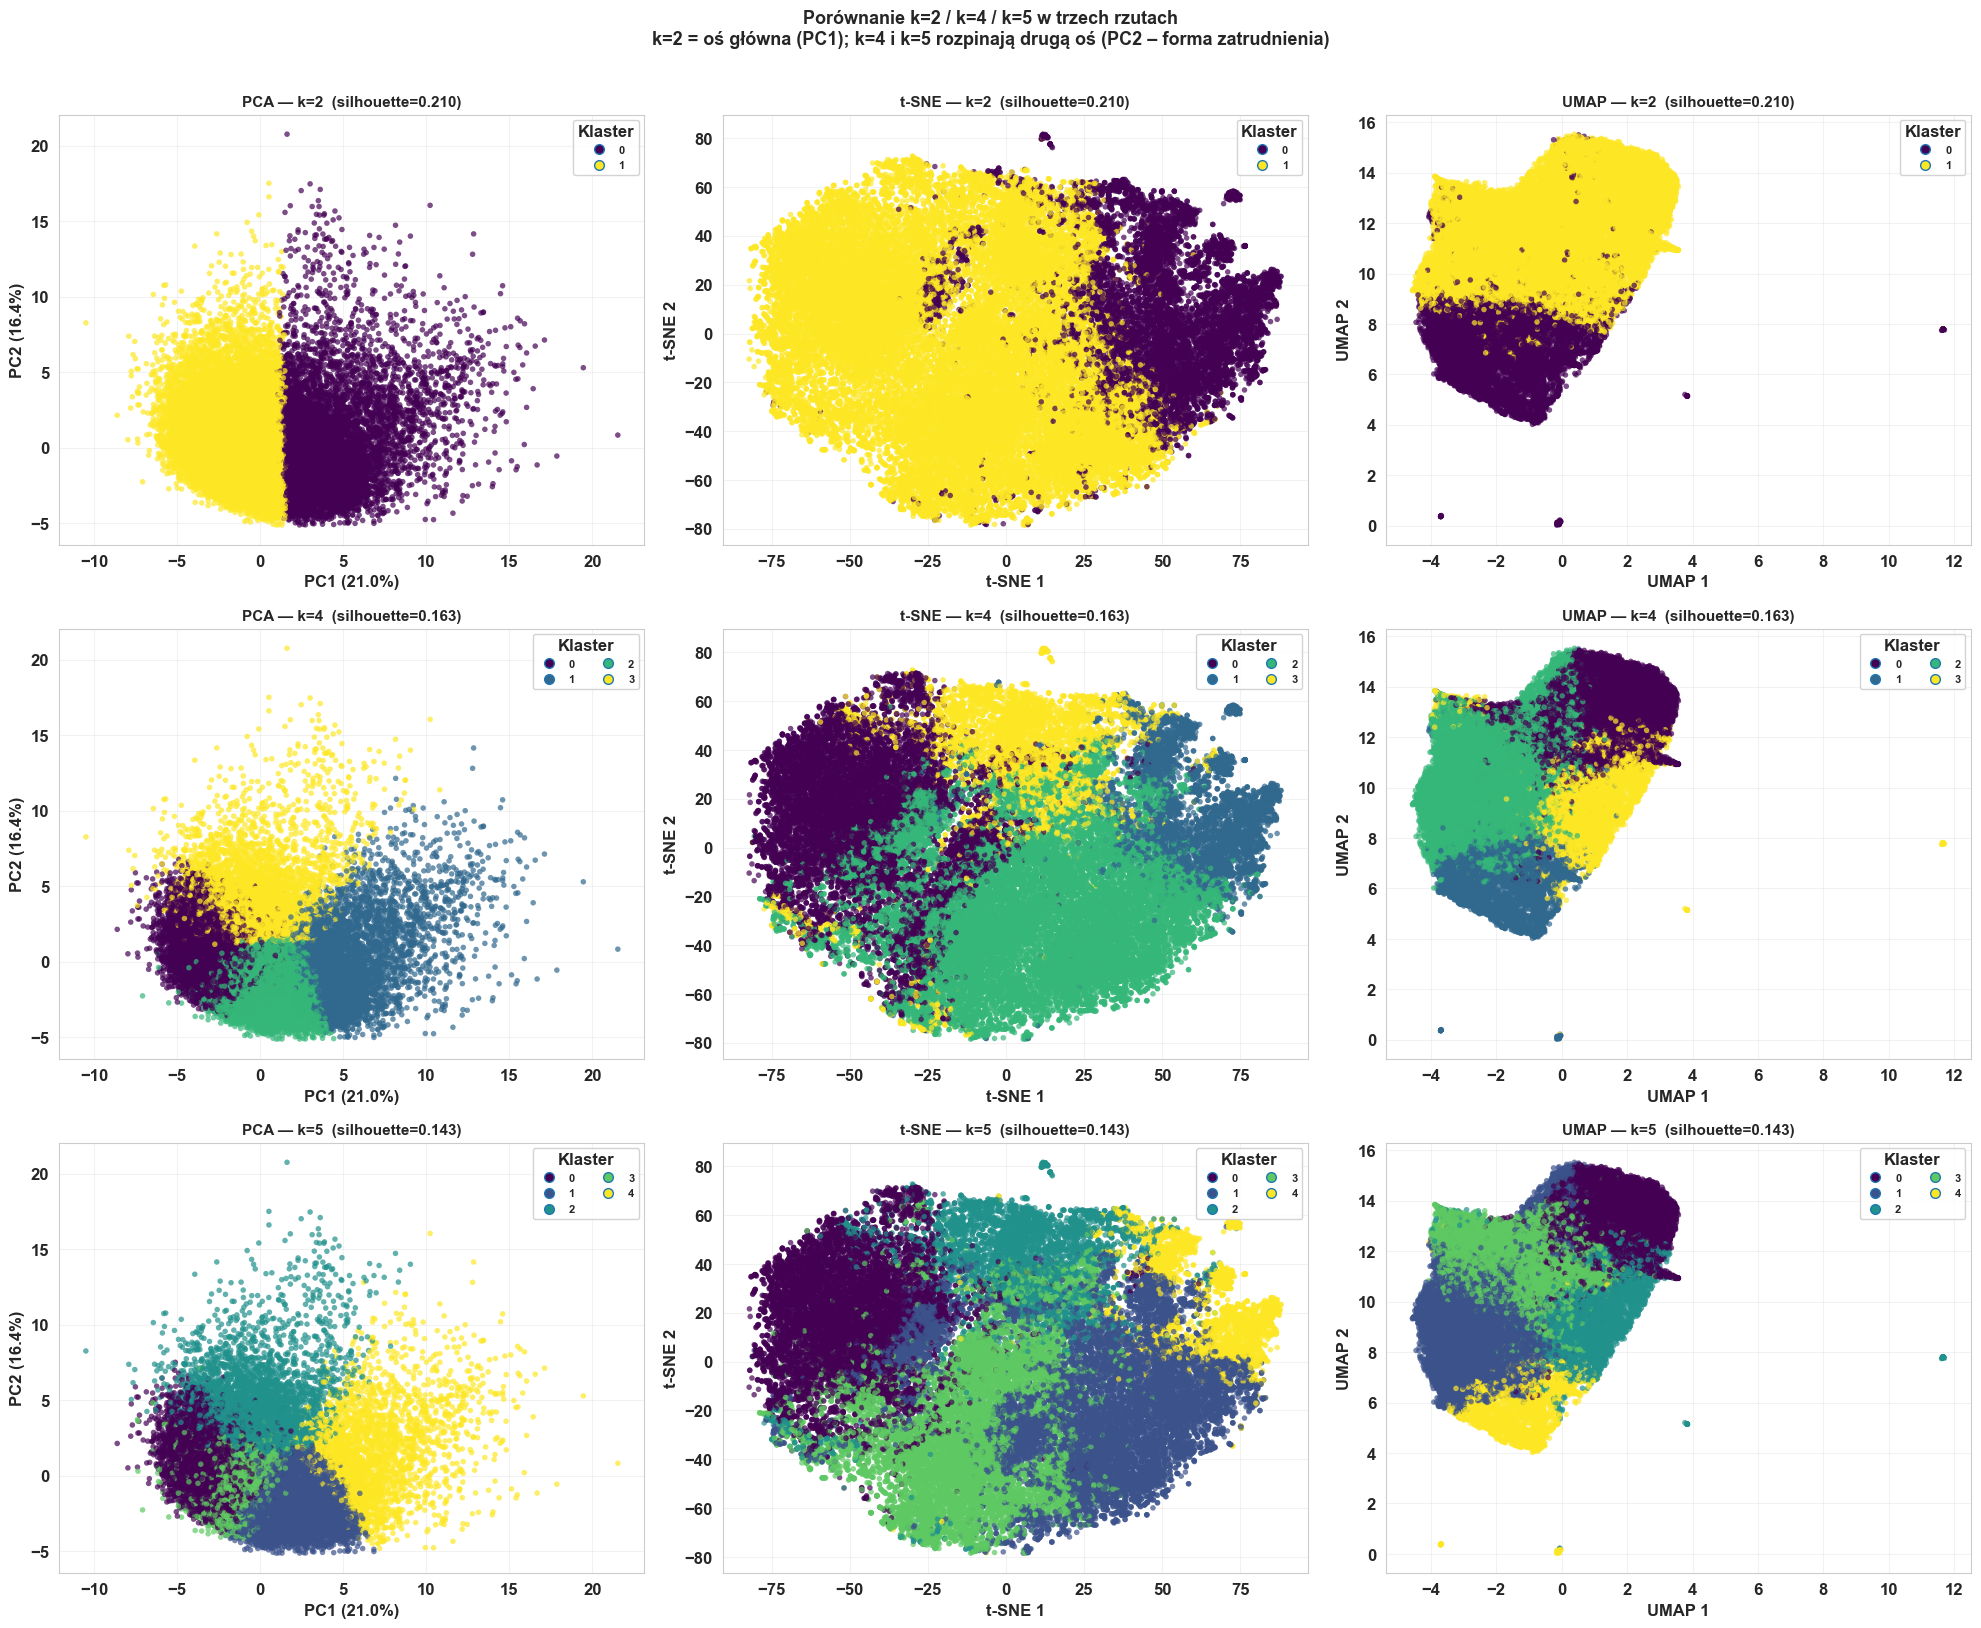

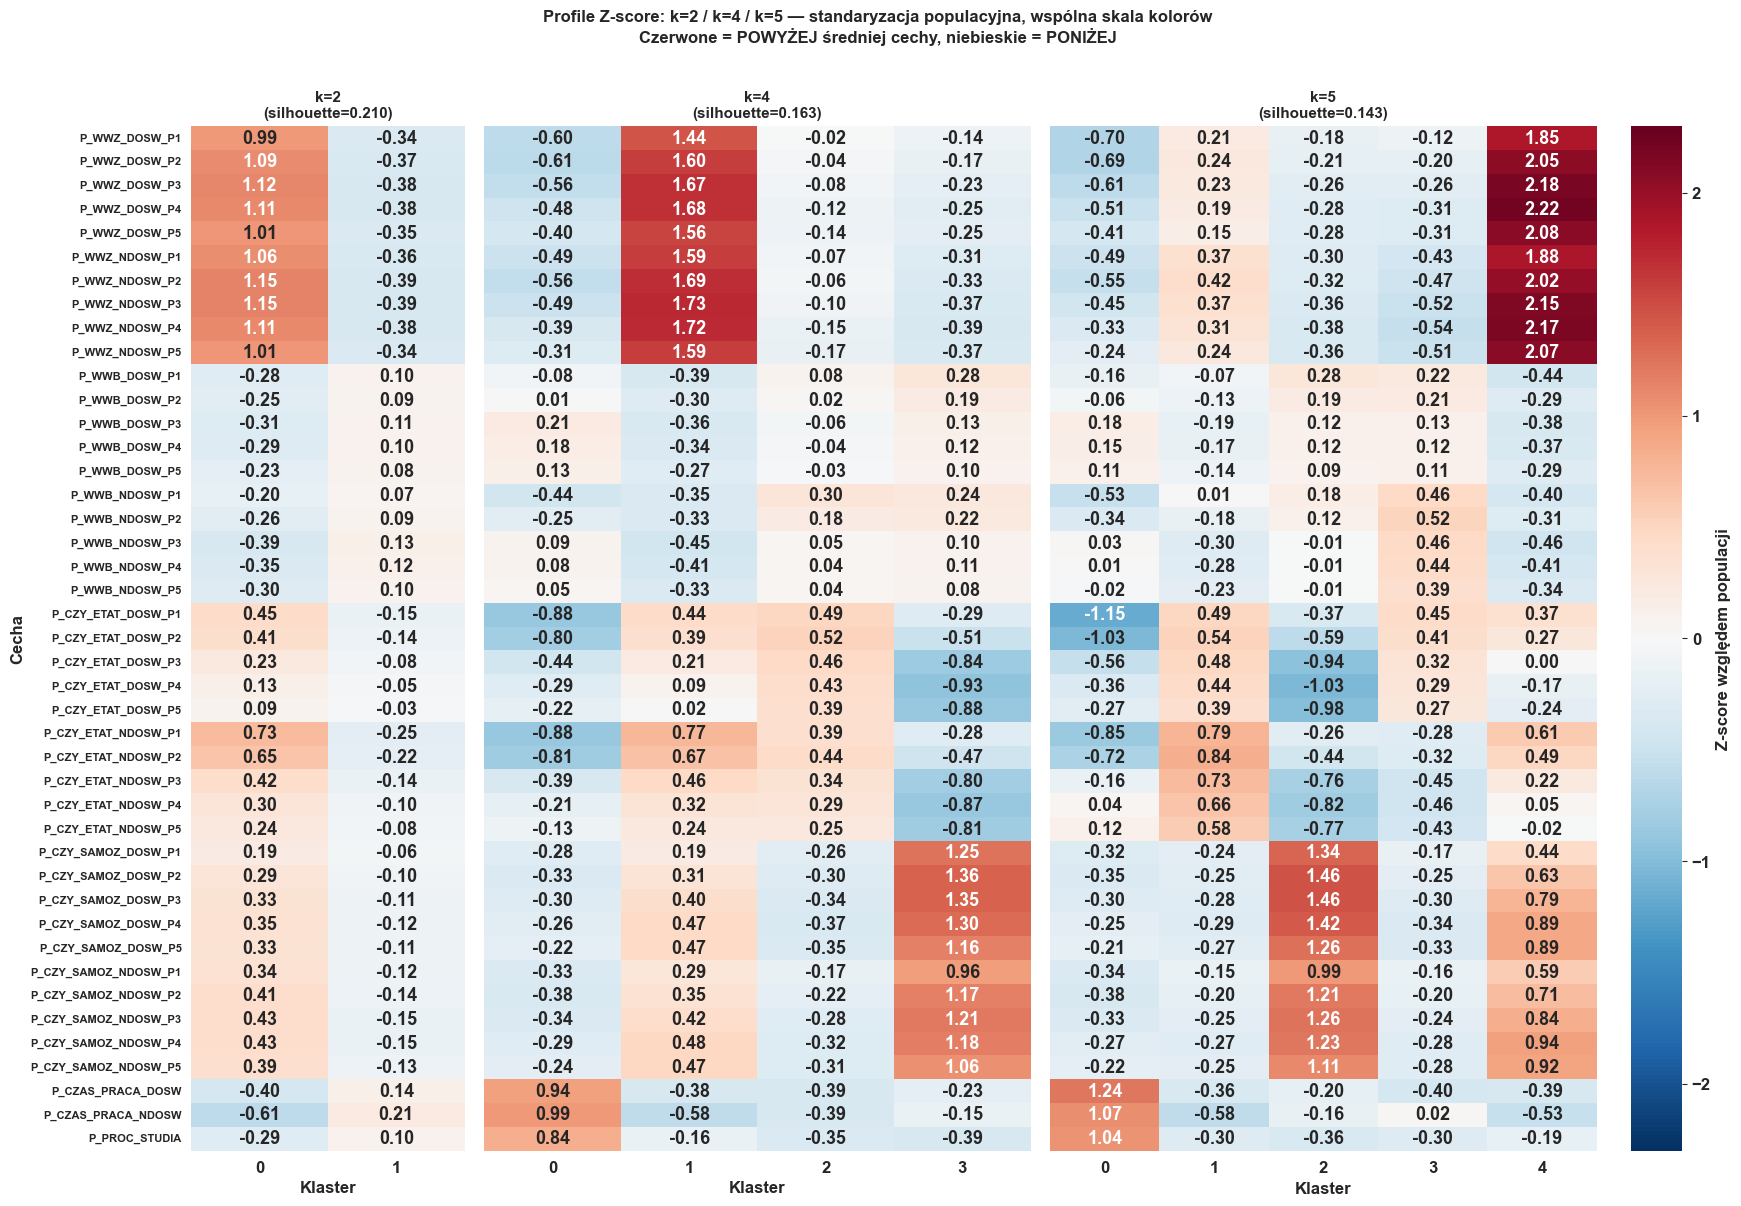


=== Zagnieżdżenie k=4 wewnątrz k=2 ===
Liczności:
Klaster_k4      0     1      2     3
Klaster_k2                          
0              85  4949   3365  1071
1           10197     0  13535  3978

% każdego klastra k4 trafiające do danego k2:
Klaster_k4     0      1     2     3
Klaster_k2                         
0            0.8  100.0  19.9  21.2
1           99.2    0.0  80.1  78.8

Czystość (max udział w jednym klastrze k2):
  klaster 0: 99%  → CZYSTY pod-typ
  klaster 1: 100%  → CZYSTY pod-typ
  klaster 2: 80%  → mieszany
  klaster 3: 79%  → mieszany

=== Zagnieżdżenie k=5 wewnątrz k=2 ===
Liczności:
Klaster_k5     0     1     2     3     4
Klaster_k2                              
0             70  5446   990   111  2853
1           8195  6203  3454  9858     0

% każdego klastra k5 trafiające do danego k2:
Klaster_k5     0     1     2     3      4
Klaster_k2                               
0            0.8  46.8  22.3   1.1  100.0
1           99.2  53.2  77.7  98.9    0.0

Czyst

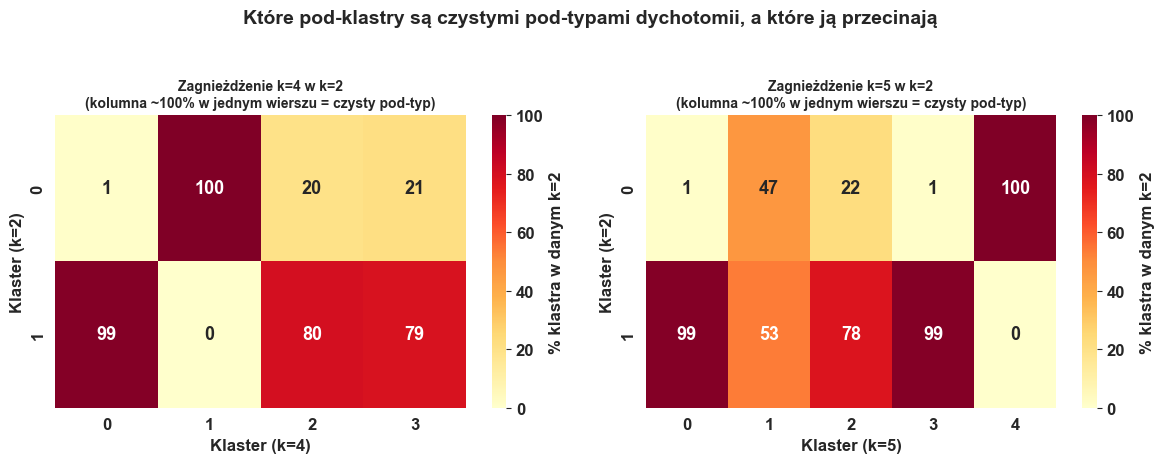


=== Liczności klastrów (kontrola dla logitu/RF) ===

k=2:
Klaster_k2
0     9470
1    27710
  najmniejsza klasa: 9470  (25.5% próby)

k=4:
Klaster_k4
0    10282
1     4949
2    16900
3     5049
  najmniejsza klasa: 4949  (13.3% próby)

k=5:
Klaster_k5
0     8265
1    11649
2     4444
3     9969
4     2853
  najmniejsza klasa: 2853  (7.7% próby)

=== Adjusted Rand Index między podziałami ===
  k=2 vs k=4: ARI = 0.176
  k=2 vs k=5: ARI = 0.123
  k=4 vs k=5: ARI = 0.486

Klaster B2B w k=5: 2 (najwyższe średnie SAMOZ_DOSW)
Rozkład tego klastra po klastrach k=4 (%):
Klaster_k4
0     0.7
1     0.8
2     0.5
3    98.0
  → 98% w jednym klastrze k=4  ⇒  zachowany jako odrębna grupa

Średnie SAMOZ_DOSW per klaster k=4 (czy istnieje wyraźny klaster przedsiębiorców?):
Klaster_k4
0     8.592
1    17.288
2     7.942
3    29.332


In [12]:
# ==========================================
# 11b. PORÓWNANIE k=2 vs k=4 vs k=5 OBOK SIEBIE
# ==========================================
# Cel: k=2 = dominująca oś (PC1, sukces vs trudny start);
#      k=4 / k=5 = rozpięcie drugiej osi (PC2, forma zatrudnienia: etat vs B2B).
# Wszystko liczone na X_pca_reduced (przestrzeń PCA powyżej Kaisera) - spójnie z modelem głównym.

K_LIST = [2, 4, 5]          # <-- tu sterowanie, które k porównać
CMAP = 'viridis'

# --- 1. Etykiety klastrów + silhouette dla każdego k (na tej samej przestrzeni PCA-reduced) ---
labels_by_k, sil_by_k = {}, {}
for k in K_LIST:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pca_reduced)
    col = f'Klaster_k{k}'
    df_analiza[col] = km.labels_
    labels_by_k[k] = km.labels_
    sil_by_k[k] = silhouette_score(X_pca_reduced, km.labels_)

print("Silhouette (przestrzeń PCA):")
for k in K_LIST:
    print(f"  k={k} → {sil_by_k[k]:.3f}")
print("Spadek silhouette przy większym k jest normalny: dane są kontinuum, nie odseparowane wyspy.\n")

# --- 2. Współrzędne 2D do rysowania. PCA jest już policzone (sekcja 7); t-SNE i UMAP
#        liczymy raz i zapisujemy w df_analiza, żeby sekcja 12 nie powtarzała obliczeń. ---
pca_xy = X_pca2
pca_vr = pca_2d.explained_variance_ratio_

if {'TSNE1', 'TSNE2'}.issubset(df_analiza.columns):
    tsne_xy = df_analiza[['TSNE1', 'TSNE2']].values
else:
    print("Liczę t-SNE (chwilę zajmie)...")
    tsne_xy = TSNE(n_components=2, perplexity=30, random_state=42, init='pca').fit_transform(X_scaled)
    df_analiza['TSNE1'], df_analiza['TSNE2'] = tsne_xy[:, 0], tsne_xy[:, 1]

if {'UMAP1', 'UMAP2'}.issubset(df_analiza.columns):
    umap_xy = df_analiza[['UMAP1', 'UMAP2']].values
else:
    print("Liczę UMAP...")
    umap_xy = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                        metric='euclidean', random_state=42).fit_transform(X_scaled)
    df_analiza['UMAP1'], df_analiza['UMAP2'] = umap_xy[:, 0], umap_xy[:, 1]

pc1_lab = f'PC1 ({pca_vr[0]*100:.1f}%)'
pc2_lab = f'PC2 ({pca_vr[1]*100:.1f}%)'

# --- 3. Siatka (len(K_LIST) wierszy) × 3 kolumny (PCA / t-SNE / UMAP) ---
embeddings = [
    ('PCA',   pca_xy,  pc1_lab, pc2_lab),
    ('t-SNE', tsne_xy, 't-SNE 1', 't-SNE 2'),
    ('UMAP',  umap_xy, 'UMAP 1', 'UMAP 2'),
]
n_rows = len(K_LIST)
fig, axes = plt.subplots(n_rows, 3, figsize=(20, 5.4 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

for row, k in enumerate(K_LIST):
    for col, (name, xy, xlab, ylab) in enumerate(embeddings):
        ax = axes[row, col]
        ax.scatter(xy[:, 0], xy[:, 1], c=df_analiza[f'Klaster_k{k}'],
                   cmap=CMAP, alpha=0.7, s=16, linewidths=0)
        ax.set_title(f'{name} — k={k}  (silhouette={sil_by_k[k]:.3f})', fontsize=11)
        ax.set_xlabel(xlab); ax.set_ylabel(ylab)
        ax.grid(alpha=0.25)
        handles = [plt.Line2D([0], [0], marker='o', linestyle='', markersize=7,
                              markerfacecolor=plt.get_cmap(CMAP)(i / max(1, k - 1)),
                              label=f'{i}') for i in range(k)]
        ax.legend(handles=handles, title='Klaster', fontsize=8,
                  loc='best', framealpha=0.85, ncol=1 if k <= 3 else 2)
plt.suptitle('Porównanie k=2 / k=4 / k=5 w trzech rzutach\n'
             'k=2 = oś główna (PC1); k=4 i k=5 rozpinają drugą oś (PC2 – forma zatrudnienia)',
             fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

# --- 4. Profile Z-score (standaryzacja POPULACYJNA) – wszystkie k na WSPÓLNEJ skali kolorów ---
# z-score = ile odchyleń populacyjnych średnia klastra leży od średniej ogólnej.
global_mean = df_analiza[features].mean()
global_std  = df_analiza[features].std().replace(0, np.nan)

profiles_z = {}
for k in K_LIST:
    prof = df_analiza.groupby(f'Klaster_k{k}')[features].mean()
    profiles_z[k] = ((prof - global_mean) / global_std).T   # cechy w wierszach

# wspólna skala dla uczciwego porównania mocy efektów między wszystkimi k
vmax = float(np.nanmax([np.nanmax(np.abs(p.values)) for p in profiles_z.values()]))
vmax = np.ceil(vmax * 10) / 10

fig, axs = plt.subplots(
    1, n_rows, figsize=(4 + sum(K_LIST) * 1.25, max(12, len(features) * 0.22)),
    gridspec_kw={'width_ratios': K_LIST}
)
if n_rows == 1:
    axs = [axs]
for i, k in enumerate(K_LIST):
    last = (i == n_rows - 1)
    sns.heatmap(profiles_z[k], annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-vmax, vmax=vmax, ax=axs[i],
                yticklabels=True if i == 0 else False,
                cbar=last, cbar_kws={'label': 'Z-score względem populacji'} if last else None)
    axs[i].set_title(f'k={k}\n(silhouette={sil_by_k[k]:.3f})', fontsize=11)
    axs[i].set_xlabel('Klaster')
    axs[i].set_ylabel('Cecha' if i == 0 else '')
    if i == 0:
        axs[i].set_yticklabels(axs[i].get_yticklabels(), fontsize=8)
plt.suptitle('Profile Z-score: k=2 / k=4 / k=5 — standaryzacja populacyjna, wspólna skala kolorów\n'
             'Czerwone = POWYŻEJ średniej cechy, niebieskie = PONIŻEJ',
             fontsize=12, y=1.005)
plt.tight_layout()
plt.show()

# --- 5. Zagnieżdżenie: jak k=4 i k=5 rozkładają się wewnątrz k=2 ---
# Pokazuje, które klastry są CZYSTYMI pod-typami dychotomii, a które ją PRZECINAJĄ (oś PC2).
def nesting_report(k_fine, k_coarse=2):
    fine, coarse = f'Klaster_k{k_fine}', f'Klaster_k{k_coarse}'
    if coarse not in df_analiza.columns:
        return
    ct = pd.crosstab(df_analiza[coarse], df_analiza[fine])
    pct = (ct / ct.sum(axis=0) * 100).round(1)   # % kolumny (klastra k_fine) w każdym k_coarse
    print(f"\n=== Zagnieżdżenie k={k_fine} wewnątrz k={k_coarse} ===")
    print("Liczności:")
    print(ct.to_string())
    print("\n% każdego klastra k{} trafiające do danego k{}:".format(k_fine, k_coarse))
    print(pct.to_string())
    purity = pct.max(axis=0)   # dominujący udział = czystość zagnieżdżenia
    print("\nCzystość (max udział w jednym klastrze k{}):".format(k_coarse))
    for cl in purity.index:
        tag = "CZYSTY pod-typ" if purity[cl] >= 90 else (
              "mieszany" if purity[cl] >= 65 else "PRZECINA dychotomię (oś PC2)")
        print(f"  klaster {cl}: {purity[cl]:.0f}%  → {tag}")

fig2, axn = plt.subplots(1, sum(1 for k in K_LIST if k != 2),
                         figsize=(6 * sum(1 for k in K_LIST if k != 2), 4.5))
axn = np.atleast_1d(axn)
ai = 0
for k in K_LIST:
    if k == 2:
        continue
    nesting_report(k, 2)
    ct = pd.crosstab(df_analiza['Klaster_k2'], df_analiza[f'Klaster_k{k}'])
    pct = (ct / ct.sum(axis=0) * 100)
    sns.heatmap(pct, annot=True, fmt='.0f', cmap='YlOrRd', vmin=0, vmax=100,
                cbar_kws={'label': '% klastra w danym k=2'}, ax=axn[ai])
    axn[ai].set_title(f'Zagnieżdżenie k={k} w k=2\n(kolumna ~100% w jednym wierszu = czysty pod-typ)',
                      fontsize=10)
    axn[ai].set_xlabel(f'Klaster (k={k})'); axn[ai].set_ylabel('Klaster (k=2)')
    ai += 1
plt.suptitle('Które pod-klastry są czystymi pod-typami dychotomii, a które ją przecinają', y=1.03)
plt.tight_layout()
plt.show()

# --- 6. Liczności wszystkich podziałów (kontrola minimalnej klasy do części nadzorowanej) ---
print("\n=== Liczności klastrów (kontrola dla logitu/RF) ===")
for k in K_LIST:
    vc = df_analiza[f'Klaster_k{k}'].value_counts().sort_index()
    print(f"\nk={k}:")
    print(vc.to_string())
    print(f"  najmniejsza klasa: {vc.min()}  ({vc.min()/len(df_analiza)*100:.1f}% próby)")

    # --- 7. ARI między podziałami + czy klaster B2B przeżywa przy k=4 ---

print("\n=== Adjusted Rand Index między podziałami ===")
for a, b in [(2, 4), (2, 5), (4, 5)]:
    ari = adjusted_rand_score(df_analiza[f'Klaster_k{a}'], df_analiza[f'Klaster_k{b}'])
    print(f"  k={a} vs k={b}: ARI = {ari:.3f}")

# Klaster samozatrudnionych w k=5 to ten o najwyższym średnim SAMOZ_DOSW.
samoz_cols = [c for c in features if 'SAMOZ_DOSW' in c]
b2b_k5 = df_analiza.groupby('Klaster_k5')[samoz_cols].mean().mean(axis=1).idxmax()
print(f"\nKlaster B2B w k=5: {b2b_k5} (najwyższe średnie SAMOZ_DOSW)")

# Gdzie trafiają jego obserwacje, gdy przejdziemy na k=4?
mask = df_analiza['Klaster_k5'] == b2b_k5
spread = df_analiza.loc[mask, 'Klaster_k4'].value_counts(normalize=True).sort_index() * 100
print("Rozkład tego klastra po klastrach k=4 (%):")
print(spread.round(1).to_string())
top_share = spread.max()
verdict = ("zachowany jako odrębna grupa" if top_share >= 70
           else "ROZBITY — k=4 nie widzi B2B jako osobnej ścieżki")
print(f"  → {top_share:.0f}% w jednym klastrze k=4  ⇒  {verdict}")

# Dla pełni: średni SAMOZ w każdym klastrze k=4 — czy któryś jest „klastrem B2B"?
print("\nŚrednie SAMOZ_DOSW per klaster k=4 (czy istnieje wyraźny klaster przedsiębiorców?):")
print(df_analiza.groupby('Klaster_k4')[samoz_cols].mean().mean(axis=1).round(3).to_string())

FINALNY PODZIAŁ: k = 5

Automatyczne przypisanie nazw (na podstawie profilu Z-score):
  0 → Trudny start                     (N = 8265)
  1 → Stabilny etat                    (N = 11649)
  2 → B2B / samozatrudnienie           (N = 4444)
  3 → Przeciętni / ryzyko bezrobocia   (N = 9969)
  4 → Elita zarobkowa                  (N = 2853)

Osie profilu użyte do nazwania (audyt – średni Z-score po grupach cech):
          WWZ   WWB  ETAT  SAMOZ  CZAS  STUDIA                           nazwa
Klaster                                                                       
0       -0.50 -0.06 -0.49  -0.30  1.15    1.04                    Trudny start
1        0.27 -0.17  0.59  -0.25 -0.47   -0.30                   Stabilny etat
2       -0.29  0.11 -0.70   1.27 -0.18   -0.36          B2B / samozatrudnienie
3       -0.37  0.31 -0.02  -0.25 -0.19   -0.30  Przeciętni / ryzyko bezrobocia
4        2.07 -0.37  0.16   0.76 -0.46   -0.19                 Elita zarobkowa

UWAGA: numery klastrów K-Means są l

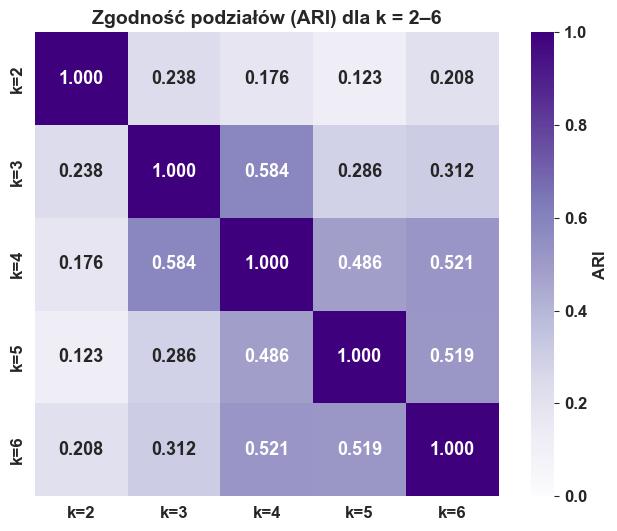

In [13]:
# ==========================================
# 11c. FINALNY WYBÓR: k=5 + AUTOMATYCZNE NAZWY MERYTORYCZNE
# ==========================================
# Decyzja analityczna (uzasadniona w 11b): k=5 jako finalny podział.
#  - k=2 łapie tylko oś sukcesu (PC1),
#  - k=4 trzyma ~46% próby w klastrze bez wyraźnego profilu,
#  - k=5 rozszczepia go na "stabilny etat" i "ryzyko bezrobocia" – obie interpretowalne.
# Od tego miejsca kolumna 'Klaster' = podział k=5; tak czytają ją wszystkie dalsze sekcje.


docelowe_k = 5
df_analiza['Klaster'] = df_analiza['Klaster_k5']

# Automatyczne, odporne na przetasowanie etykiet nazwy (po PROFILU, nie po numerze).
# Numer oryginalnego klastra zostaje w nawiasie: "Nazwa (N)".
nazwy_map, etykiety_map, profil_audyt = assign_cluster_names(
    df_analiza, 'Klaster', features, k_expected=docelowe_k
)
df_analiza['Klaster_nazwa'] = df_analiza['Klaster'].map(nazwy_map)

print("=" * 70)
print(f"FINALNY PODZIAŁ: k = {docelowe_k}")
print("=" * 70)
print("\nAutomatyczne przypisanie nazw (na podstawie profilu Z-score):")
for cid in sorted(nazwy_map):
    n = (df_analiza['Klaster'] == cid).sum()
    print(f"  {cid} → {etykiety_map[cid]:32s} (N = {n})")

print("\nOsie profilu użyte do nazwania (audyt – średni Z-score po grupach cech):")
print(profil_audyt.round(2).to_string())
print("\nUWAGA: numery klastrów K-Means są losowe między uruchomieniami,")
print("ale nazwy są przypisywane PO PROFILU, więc pozostają stabilne.")

# Macierz ARI dla k=2..6: jak bardzo podziały o różnej liczbie klastrów
# są do siebie podobne (uzupełnienie dyskusji o wyborze k).
ks = [2, 3, 4, 5, 6]
lab = {k: KMeans(k, random_state=42, n_init=10).fit_predict(X_pca_reduced) for k in ks}

ari = pd.DataFrame(np.eye(len(ks)), index=[f'k={k}' for k in ks],
                   columns=[f'k={k}' for k in ks])
for a in ks:
    for b in ks:
        if a < b:
            v = adjusted_rand_score(lab[a], lab[b])
            ari.loc[f'k={a}', f'k={b}'] = v
            ari.loc[f'k={b}', f'k={a}'] = v

print("Macierz zgodności ARI między rozwiązaniami:")
print(ari.round(3).to_string())

# heatmapa macierzy ARI
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(ari, annot=True, fmt='.3f', cmap='Purples', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'ARI'}, ax=ax)
ax.set_title('Zgodność podziałów (ARI) dla k = 2–6')
plt.tight_layout()
plt.savefig('rys4_x_ari_macierz.png', dpi=200, bbox_inches='tight')
plt.show()

UWAGA: nie udało się zmapować FCM 1:1 na k-means — kolumny mają surową numerację FCM.
FUZZY C-MEANS (k=5, m=2.0)
FPC (Fuzzy Partition Coefficient, 1=ostre, 1/k=0.20=maks. rozmyte): 0.513
Zgodność FCM z k-means (twarde etykiety): 7.2%

Kierunki GRANICZNE (entropia > 0.80 = 50% maks.): 26367/37180 (70.9%)
To ILOŚCIOWE potwierdzenie, że granice ścieżek są rozmyte — kierunki leżą 'pomiędzy'.


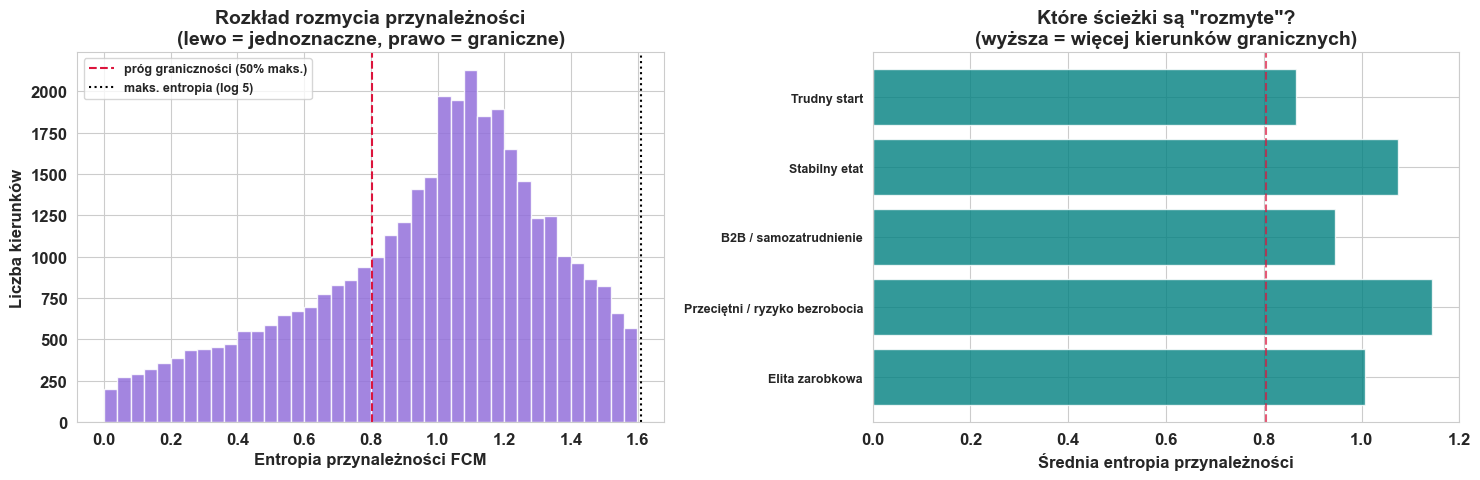


Średnia entropia per ścieżka (wyższa = bardziej rozmyta granica):
  Trudny start                     0.865
  Stabilny etat                    1.075
  B2B / samozatrudnienie           0.946
  Przeciętni / ryzyko bezrobocia   1.143
  Elita zarobkowa                  1.007


In [14]:
# ==========================================
# 11d. FUZZY C-MEANS — miękkie przynależności i rozmycie granic ścieżek
# ==========================================
# K-means daje twardą etykietę (0-4), ale dane tworzą kontinuum (silhouette maleje
# ze wzrostem k, granice grup są nieostre). FCM przypisuje każdemu kierunkowi WEKTOR
# przynależności do 5 ścieżek — kwantyfikuje, które kierunki leżą "pomiędzy". To zamienia
# jakościowy argument "dane są ciągłe" w ilościowy: ile kierunków ma rozmytą przynależność.
#
# FCM liczony na dwóch pierwszych składowych PCA: w pełnej przestrzeni X_pca_reduced
# przynależności degenerują do rozkładu niemal jednostajnego (notka pod komórką),
# a na PC1-PC2 algorytm odtwarza sensowny podział.
try:
    import skfuzzy as fuzz
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-fuzzy'],
                          stdout=subprocess.DEVNULL)
    import skfuzzy as fuzz

FCM_M = 2.0   # parametr rozmycia: m=1 -> twardy (jak k-means), większe m -> bardziej rozmyte

X_fcm = SS().fit_transform(X_pca_reduced[:, :2])
cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(
    X_fcm.T, c=docelowe_k, m=FCM_M, error=0.005, maxiter=2000, init=None, seed=42)
memb = u.T                          # [n_próbek, k] — przynależności do ścieżek
hard_fcm = memb.argmax(axis=1)      # twarda etykieta: ścieżka o maks. przynależności

# --- Mapowanie numeracji FCM na numerację k-means (po największym pokryciu), ---
# żeby "ścieżka 2 wg FCM" = "ścieżka 2 wg k-means" i nazwy się zgadzały.
remap = {}
for f in range(docelowe_k):
    mask = hard_fcm == f
    if mask.sum() > 0:
        remap[f] = pd.Series(df_analiza['Klaster_k5'].values[mask]).mode().iloc[0]

if len(set(remap.values())) == docelowe_k:   # mapowanie 1:1 udane
    memb_mapped = np.zeros_like(memb)
    for f, kk in remap.items():
        memb_mapped[:, kk] = memb[:, f]
    memb = memb_mapped
    hard_fcm = np.array([remap[f] for f in hard_fcm])
    cntr_mapped = np.zeros_like(cntr)
    for f, kk in remap.items():
        cntr_mapped[kk] = cntr[f]
    cntr = cntr_mapped
else:
    print("UWAGA: nie udało się zmapować FCM 1:1 na k-means — kolumny mają surową numerację FCM.")

# --- Entropia przynależności: miara GRANICZNOŚCI kierunku ---
# Niska entropia = kierunek jednoznacznie w jednej ścieżce.
# Wysoka entropia (→ log k) = przynależność rozłożona, kierunek "pomiędzy ścieżkami".
entropia = -np.sum(memb * np.log(memb + 1e-12), axis=1)
entropia_max = np.log(docelowe_k)

# --- Zapis do df_analiza: przynależności, entropia, twarda etykieta ---
for kk in range(docelowe_k):
    df_analiza[f'FCM_przyn_{kk}'] = memb[:, kk]
df_analiza['FCM_entropia'] = entropia
df_analiza['FCM_klaster'] = hard_fcm

print("="*70)
print(f"FUZZY C-MEANS (k={docelowe_k}, m={FCM_M})")
print("="*70)
print(f"FPC (Fuzzy Partition Coefficient, 1=ostre, 1/k={1/docelowe_k:.2f}=maks. rozmyte): {fpc:.3f}")
print(f"Zgodność FCM z k-means (twarde etykiety): "
      f"{(df_analiza['FCM_klaster'] == df_analiza['Klaster_k5']).mean()*100:.1f}%")

# Ile kierunków jest GRANICZNYCH (entropia > 50% maksimum = rozmyta przynależność)
prog = 0.5 * entropia_max
n_granicznych = (entropia > prog).sum()
print(f"\nKierunki GRANICZNE (entropia > {prog:.2f} = 50% maks.): "
      f"{n_granicznych}/{len(df_analiza)} ({n_granicznych/len(df_analiza)*100:.1f}%)")
print("To ILOŚCIOWE potwierdzenie, że granice ścieżek są rozmyte — kierunki leżą 'pomiędzy'.")

# --- Wykres 1: rozkład entropii (ile kierunków jednoznacznych vs granicznych) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(entropia, bins=40, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[0].axvline(prog, color='crimson', linestyle='--', label=f'próg graniczności (50% maks.)')
axes[0].axvline(entropia_max, color='black', linestyle=':', label=f'maks. entropia (log {docelowe_k})')
axes[0].set_xlabel('Entropia przynależności FCM')
axes[0].set_ylabel('Liczba kierunków')
axes[0].set_title('Rozkład rozmycia przynależności\n(lewo = jednoznaczne, prawo = graniczne)')
axes[0].legend(fontsize=9)

# --- Wykres 2: entropia per ścieżka — które ścieżki mają najwięcej granicznych kierunków ---
ent_per_sciezka = df_analiza.groupby('FCM_klaster')['FCM_entropia'].mean().sort_index()
nazwy = [etykiety_map.get(c, c) for c in ent_per_sciezka.index]
axes[1].barh(range(len(ent_per_sciezka)), ent_per_sciezka.values, color='teal', alpha=0.8)
axes[1].set_yticks(range(len(ent_per_sciezka)))
axes[1].set_yticklabels(nazwy, fontsize=9)
axes[1].invert_yaxis()
axes[1].axvline(prog, color='crimson', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Średnia entropia przynależności')
axes[1].set_title('Które ścieżki są "rozmyte"?\n(wyższa = więcej kierunków granicznych)')
plt.tight_layout()
plt.show()

print("\nŚrednia entropia per ścieżka (wyższa = bardziej rozmyta granica):")
for c in ent_per_sciezka.index:
    print(f"  {etykiety_map.get(c, c):32s} {ent_per_sciezka[c]:.3f}")

**Uwaga metodyczna:** FCM w pełnej przestrzeni PCA (10 składowych) degeneruje — przynależności wszystkich obserwacji zbiegają do rozkładu niemal jednostajnego i podział na 5 ścieżek się nie odtwarza. Na dwóch pierwszych składowych FCM działa poprawnie i dobrze zgadza się z k-means (ARI w komórce niżej). To kolejny argument, że ścieżki nie są w pełni odseparowanymi grupami, tylko zagęszczeniami na kontinuum.


In [15]:
# Zgodność twardych etykiet FCM (liczonych na PC1-PC2) z k-means:
# raz z podziałem finalnym (10D), raz z k-means na tych samych dwóch składowych.
# Wysoki ARI w 2D przy niższym w 10D = rozbieżność bierze się z przestrzeni, nie z algorytmu.
print("ARI FCM-2D vs k-means(10D):", adjusted_rand_score(hard_fcm, df_analiza['Klaster_k5']))
print("ARI FCM-2D vs k-means na PC1-PC2:")
km2d = KMeans(docelowe_k, random_state=42, n_init=10).fit(X_fcm)
print("  ", adjusted_rand_score(hard_fcm, km2d.labels_))


ARI FCM-2D vs k-means(10D): 0.32687856731551257
ARI FCM-2D vs k-means na PC1-PC2:
   0.7239524091397925


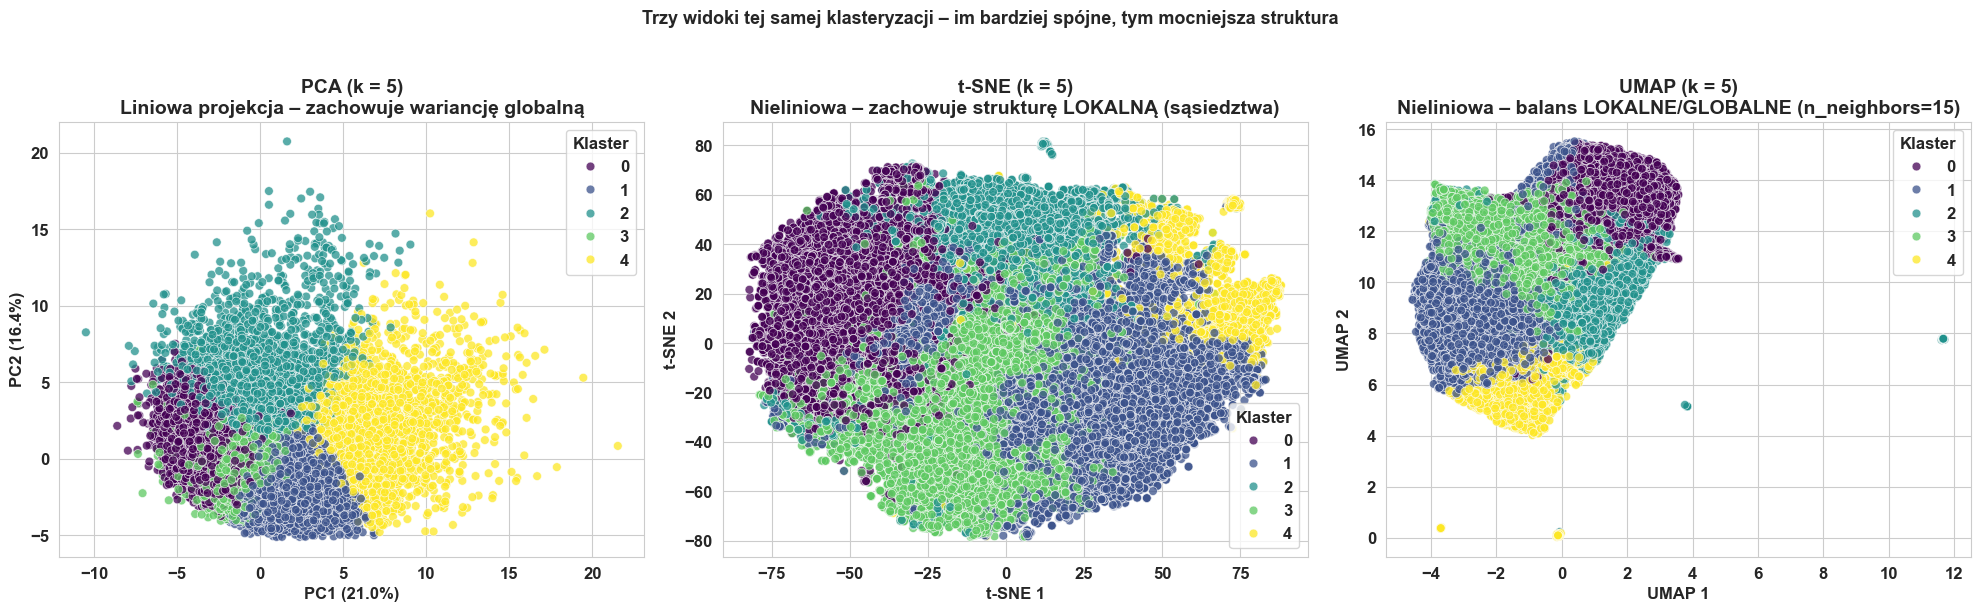


Sprawdzam stabilność UMAP względem n_neighbors...


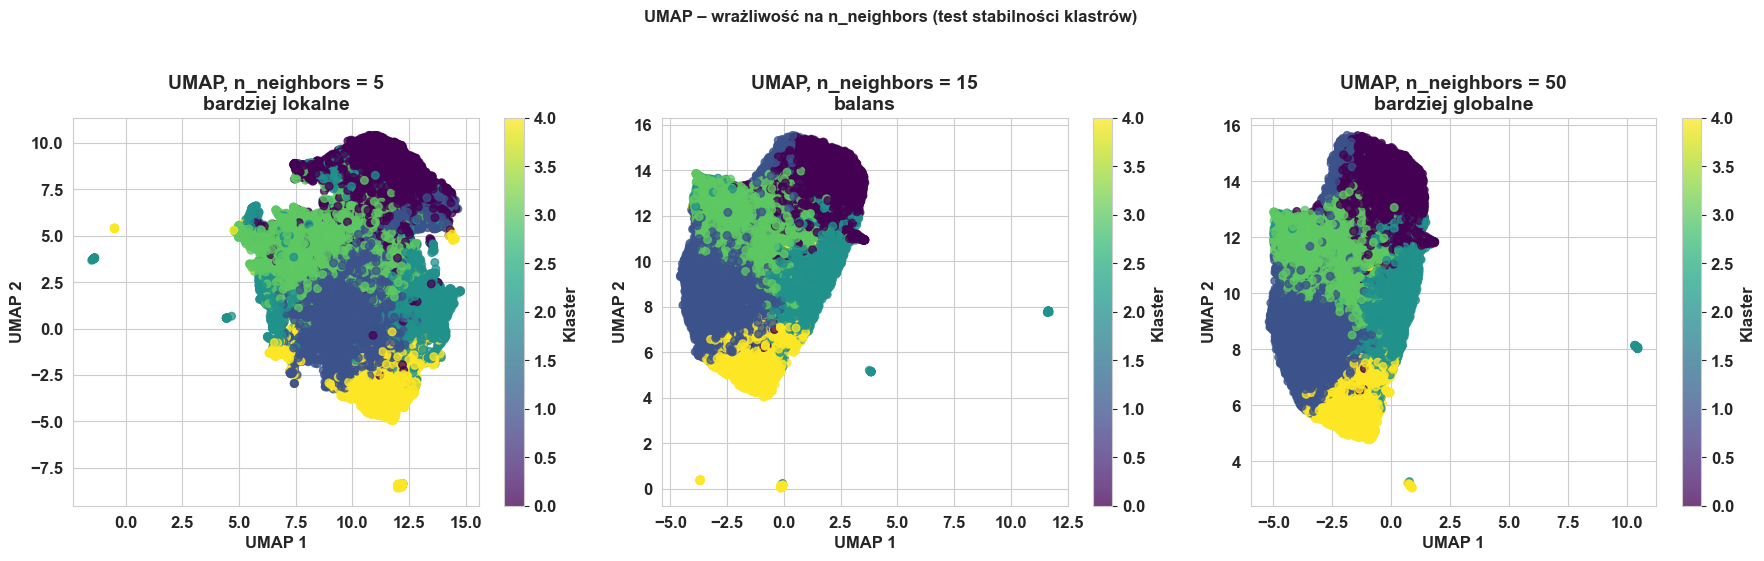

In [16]:
# ==========================================
# 12. WIZUALIZACJA: PCA vs t-SNE vs UMAP
# ==========================================
df_analiza['PCA1'] = X_pca2[:, 0]
df_analiza['PCA2'] = X_pca2[:, 1]

# t-SNE i UMAP mogły już zostać policzone (i zapisane w df_analiza) w sekcji 11b —
# wtedy tylko je odczytujemy; parametry w obu miejscach są identyczne.
if {'TSNE1', 'TSNE2'}.issubset(df_analiza.columns):
    X_tsne = df_analiza[['TSNE1', 'TSNE2']].values
else:
    print("\nRedukcja t-SNE (może chwilę zająć)...")
    X_tsne = TSNE(n_components=2, perplexity=30, random_state=42,
                  init='pca').fit_transform(X_scaled)
    df_analiza['TSNE1'], df_analiza['TSNE2'] = X_tsne[:, 0], X_tsne[:, 1]

if {'UMAP1', 'UMAP2'}.issubset(df_analiza.columns):
    X_umap = df_analiza[['UMAP1', 'UMAP2']].values
else:
    print("Redukcja UMAP...")
    # n_neighbors steruje balansem lokalne/globalne, min_dist upakowaniem grup
    X_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                       metric='euclidean', random_state=42).fit_transform(X_scaled)
    df_analiza['UMAP1'], df_analiza['UMAP2'] = X_umap[:, 0], X_umap[:, 1]

# Trzy panele obok siebie
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(x='PCA1', y='PCA2', hue='Klaster', palette='viridis',
                data=df_analiza, alpha=0.75, s=40, ax=axes[0], legend='full')
axes[0].set_title(f'PCA (k = {docelowe_k})\n'
                  f'Liniowa projekcja – zachowuje wariancję globalną')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')

sns.scatterplot(x='TSNE1', y='TSNE2', hue='Klaster', palette='viridis',
                data=df_analiza, alpha=0.75, s=40, ax=axes[1], legend='full')
axes[1].set_title(f't-SNE (k = {docelowe_k})\n'
                  f'Nieliniowa – zachowuje strukturę LOKALNĄ (sąsiedztwa)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

sns.scatterplot(x='UMAP1', y='UMAP2', hue='Klaster', palette='viridis',
                data=df_analiza, alpha=0.75, s=40, ax=axes[2], legend='full')
axes[2].set_title(f'UMAP (k = {docelowe_k})\n'
                  f'Nieliniowa – balans LOKALNE/GLOBALNE (n_neighbors=15)')
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')

plt.suptitle('Trzy widoki tej samej klasteryzacji – im bardziej spójne, tym mocniejsza struktura',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ----- DODATKOWO: UMAP z różnymi parametrami n_neighbors -----
# To pokazuje stabilność klastrów: jeśli przy n_neighbors=5, 15, 50 obrazy
# są strukturalnie podobne, klastry są realne. Jeśli nie - mogą być artefaktem.
print("\nSprawdzam stabilność UMAP względem n_neighbors...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, n_nb in zip(axes, [5, 15, 50]):
    reducer = umap.UMAP(n_neighbors=n_nb, min_dist=0.1, n_components=2,
                        metric='euclidean', random_state=42)
    coords = reducer.fit_transform(X_scaled)
    scatter = ax.scatter(coords[:, 0], coords[:, 1],
                          c=df_analiza['Klaster'], cmap='viridis',
                          alpha=0.75, s=30)
    ax.set_title(f'UMAP, n_neighbors = {n_nb}\n'
                 f'{"bardziej lokalne" if n_nb<=5 else ("balans" if n_nb<=15 else "bardziej globalne")}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    plt.colorbar(scatter, ax=ax, label='Klaster')
plt.suptitle('UMAP – wrażliwość na n_neighbors (test stabilności klastrów)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


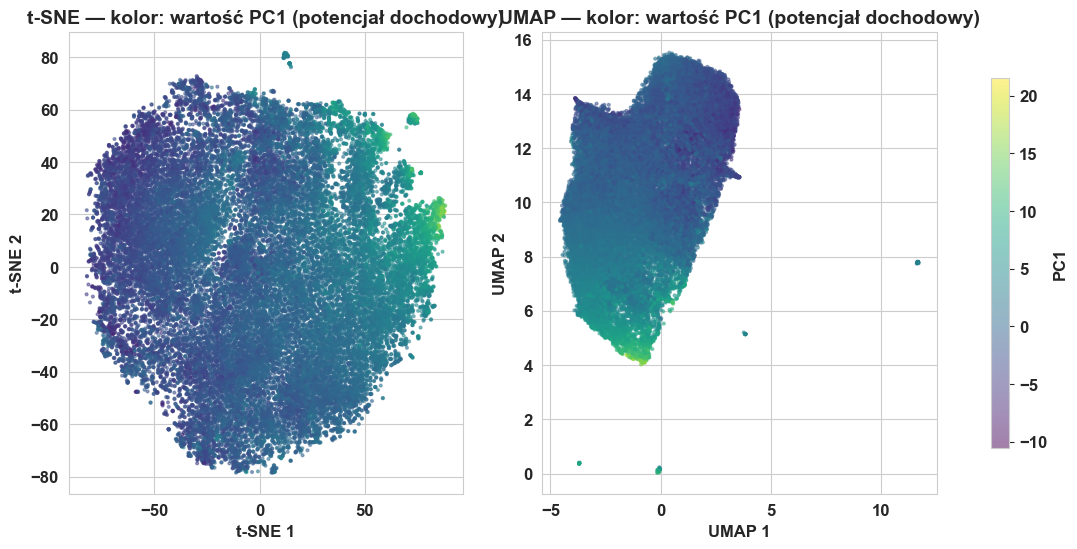

In [17]:
# ==========================================
# 12b. KONTINUUM: t-SNE i UMAP pokolorowane wartością PC1
# ==========================================
# Zamiast twardych etykiet klastrów punkty są kolorowane ciągłą wartością PC1
# (oś potencjału dochodowego). Płynne przejście barw w obu rzutach pokazuje,
# że struktura danych to kontinuum, a nie odseparowane wyspy.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, emb, name in [(axes[0], X_tsne, 't-SNE'), (axes[1], X_umap, 'UMAP')]:
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=X_pca_reduced[:, 0],
                    cmap='viridis', s=4, alpha=0.5)
    ax.set_title(f'{name} — kolor: wartość PC1 (potencjał dochodowy)')
    ax.set_xlabel(f'{name} 1'); ax.set_ylabel(f'{name} 2')
fig.colorbar(sc, ax=axes, label='PC1', shrink=0.8)
plt.savefig('rys4_4_kontinuum.png', dpi=200, bbox_inches='tight')
plt.show()



PROFILOWANIE ŚCIEŻEK KARIERY (k=5)


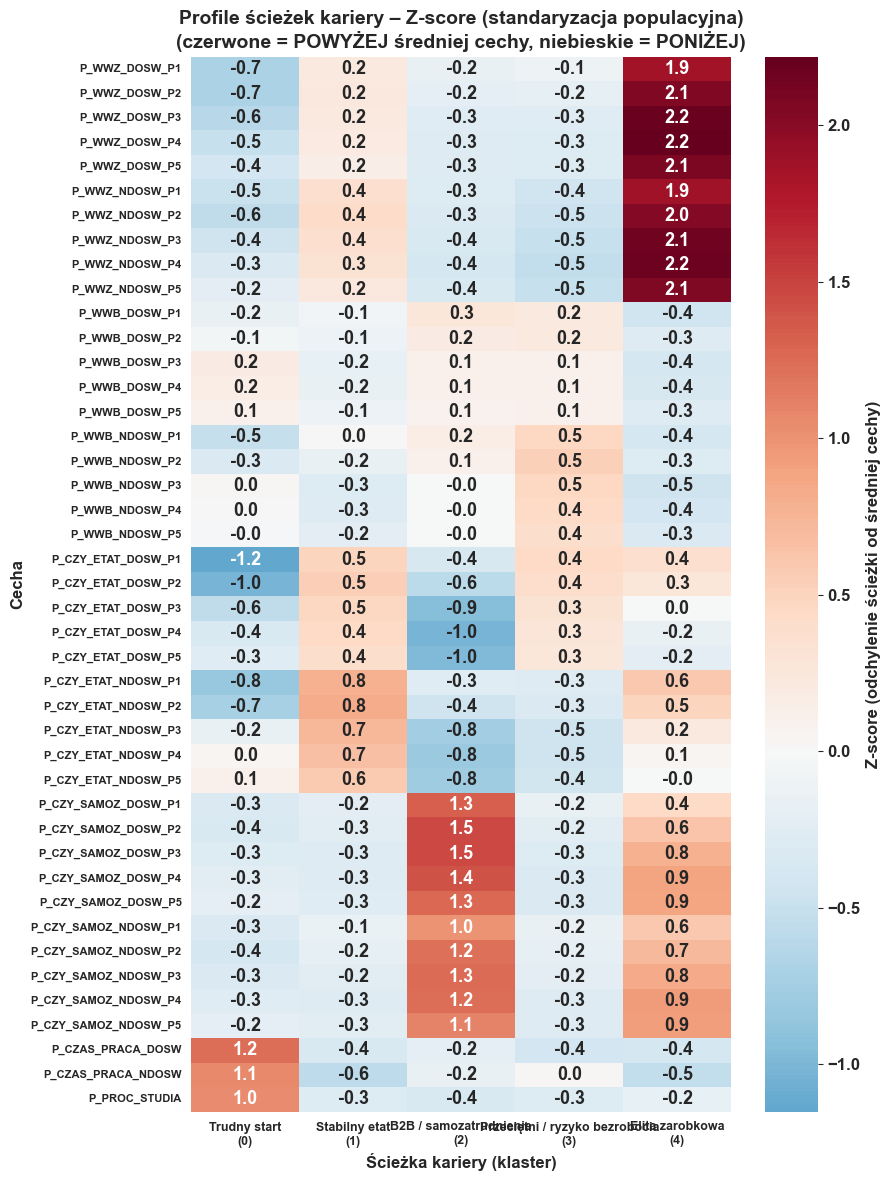


Liczności ścieżek:
  Trudny start                     (0):   8265  (22.2%)
  Stabilny etat                    (1):  11649  (31.3%)
  B2B / samozatrudnienie           (2):   4444  (12.0%)
  Przeciętni / ryzyko bezrobocia   (3):   9969  (26.8%)
  Elita zarobkowa                  (4):   2853  (7.7%)


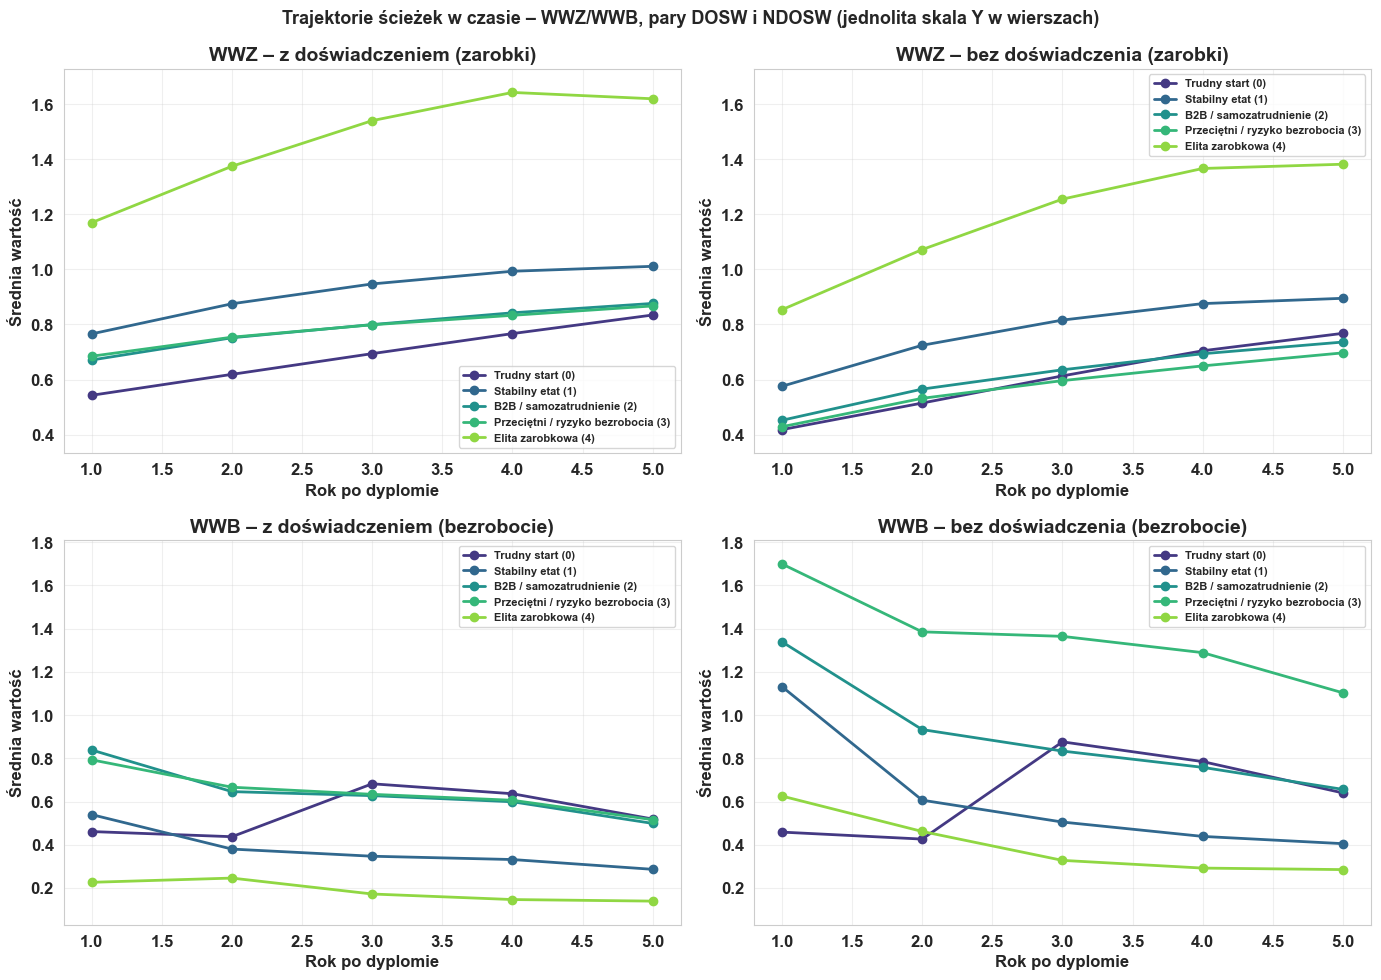


--- Test ANOVA: które cechy najmocniej różnicują ścieżki? ---
Top 10 najmocniej różnicujących cech:
             Cecha            F  p-value
    P_WWZ_NDOSW_P3 10451.389333      0.0
    P_WWZ_NDOSW_P4  9724.662387      0.0
    P_WWZ_NDOSW_P2  9578.268073      0.0
     P_WWZ_DOSW_P3  8993.692613      0.0
     P_WWZ_DOSW_P4  8683.327007      0.0
     P_WWZ_DOSW_P2  8008.091850      0.0
P_CZY_ETAT_DOSW_P1  7565.520390      0.0
    P_WWZ_NDOSW_P5  7398.440352      0.0
 P_CZAS_PRACA_DOSW  7376.295763      0.0
    P_WWZ_NDOSW_P1  6898.892877      0.0

Cechy istotne (p<0.05): 43/43


In [18]:
# ==========================================
# 13. PROFILOWANIE ŚCIEŻEK KARIERY (rozwiązanie finalne k=5)
# ==========================================
print("\n" + "="*70)
print("PROFILOWANIE ŚCIEŻEK KARIERY (k=5)")
print("="*70)

# Sekcja profiluje ROZWIĄZANIE FINALNE (Klaster_k5), niezależnie od tego,
# co głosowanie metryk ustawiło w docelowe_k / kolumnie 'Klaster'.
KLASTER_COL = 'Klaster_k5'
assert KLASTER_COL in df_analiza.columns, \
    f"Brak kolumny {KLASTER_COL} - uruchom najpierw sekcję z podziałem k=5 (11b/11c)."
K_PROFIL = df_analiza[KLASTER_COL].nunique()
assert K_PROFIL == 5, f"Oczekiwano 5 ścieżek, jest {K_PROFIL} - sprawdź {KLASTER_COL}."

klastry_sorted = sorted(df_analiza[KLASTER_COL].unique())
etykieta = lambda c: etykiety_map.get(c, f'Klaster {c}')

cluster_profile = df_analiza.groupby(KLASTER_COL)[features].mean()
global_mean = df_analiza[features].mean()
global_std  = df_analiza[features].std()
cluster_profile_z = (cluster_profile - global_mean) / global_std

# ----- Heatmapa Z-score: kolumny podpisane nazwami merytorycznymi -----
fig, ax = plt.subplots(figsize=(max(9, K_PROFIL * 1.8), max(12, len(features) * 0.22)))
heat = cluster_profile_z.T.copy()
heat.columns = [f'{etykieta(c)}\n({c})' for c in heat.columns]
sns.heatmap(heat, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Z-score (odchylenie ścieżki od średniej cechy)'}, ax=ax,
            yticklabels=True)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=9)
ax.set_title('Profile ścieżek kariery – Z-score (standaryzacja populacyjna)\n'
             '(czerwone = POWYŻEJ średniej cechy, niebieskie = PONIŻEJ)')
ax.set_xlabel('Ścieżka kariery (klaster)')
ax.set_ylabel('Cecha')
plt.tight_layout()
plt.savefig('rys4_9_profile_zscore.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nLiczności ścieżek:")
n_total = len(df_analiza)
for c in klastry_sorted:
    n_c = (df_analiza[KLASTER_COL] == c).sum()
    print(f"  {etykieta(c):32s} ({c}): {n_c:6d}  ({n_c/n_total*100:.1f}%)")

# ----- Trajektorie WWZ i WWB: skala Y dopasowana do ŚREDNICH klastrów, nie do outlierów -----
def ylim_ze_srednich(grupy_cech, pad_frac=0.07):
    """Wspólny zakres Y dla pary paneli: min/max po średnich klastrowych, z marginesem."""
    vals = np.concatenate([
        df_analiza.groupby(KLASTER_COL)[fg].mean().values.ravel()
        for fg in grupy_cech
    ])
    lo, hi = np.nanmin(vals), np.nanmax(vals)
    pad = pad_frac * (hi - lo) if hi > lo else 0.1
    return (lo - pad, hi + pad)

wwz_ylim_traj = ylim_ze_srednich([features_wwz_dosw, features_wwz_ndosw])
wwb_ylim_traj = ylim_ze_srednich([features_wwb_dosw, features_wwb_ndosw])

palette = sns.color_palette('viridis', n_colors=K_PROFIL)
color_for = {c: palette[i] for i, c in enumerate(klastry_sorted)}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
trajectory_specs = [
    (axes[0, 0], features_wwz_dosw,  'WWZ – z doświadczeniem (zarobki)',     wwz_ylim_traj),
    (axes[0, 1], features_wwz_ndosw, 'WWZ – bez doświadczenia (zarobki)',    wwz_ylim_traj),
    (axes[1, 0], features_wwb_dosw,  'WWB – z doświadczeniem (bezrobocie)',  wwb_ylim_traj),
    (axes[1, 1], features_wwb_ndosw, 'WWB – bez doświadczenia (bezrobocie)', wwb_ylim_traj),
]
for ax, feat_group, title, ylim in trajectory_specs:
    for c in klastry_sorted:
        means = df_analiza.loc[df_analiza[KLASTER_COL] == c, feat_group].mean()
        ax.plot(range(1, len(feat_group) + 1), means.values, marker='o', linewidth=2,
                label=f'{etykieta(c)} ({c})', color=color_for[c])
    ax.set_title(title)
    ax.set_xlabel('Rok po dyplomie')
    ax.set_ylabel('Średnia wartość')
    ax.set_ylim(ylim)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.suptitle('Trajektorie ścieżek w czasie – WWZ/WWB, pary DOSW i NDOSW '
             '(jednolita skala Y w wierszach)', fontsize=13)
plt.tight_layout()
plt.savefig('rys4_10_trajektorie_wwz_wwb.png', dpi=200, bbox_inches='tight')
plt.show()

# ----- ANOVA per cecha (grupy = 5 ścieżek) -----
print("\n--- Test ANOVA: które cechy najmocniej różnicują ścieżki? ---")
anova_results = []
for feat in features:
    groups = [df_analiza.loc[df_analiza[KLASTER_COL] == c, feat].values
              for c in klastry_sorted]
    f_stat, p_val = stats.f_oneway(*groups)
    anova_results.append({'Cecha': feat, 'F': f_stat, 'p-value': p_val})
anova_df = pd.DataFrame(anova_results).sort_values('F', ascending=False)
print("Top 10 najmocniej różnicujących cech:")
print(anova_df.head(10).to_string(index=False))
print(f"\nCechy istotne (p<0.05): {(anova_df['p-value'] < 0.05).sum()}/{len(features)}")


UKRYTE POWIĄZANIA: KLASTER × DZIEDZINA STUDIÓW


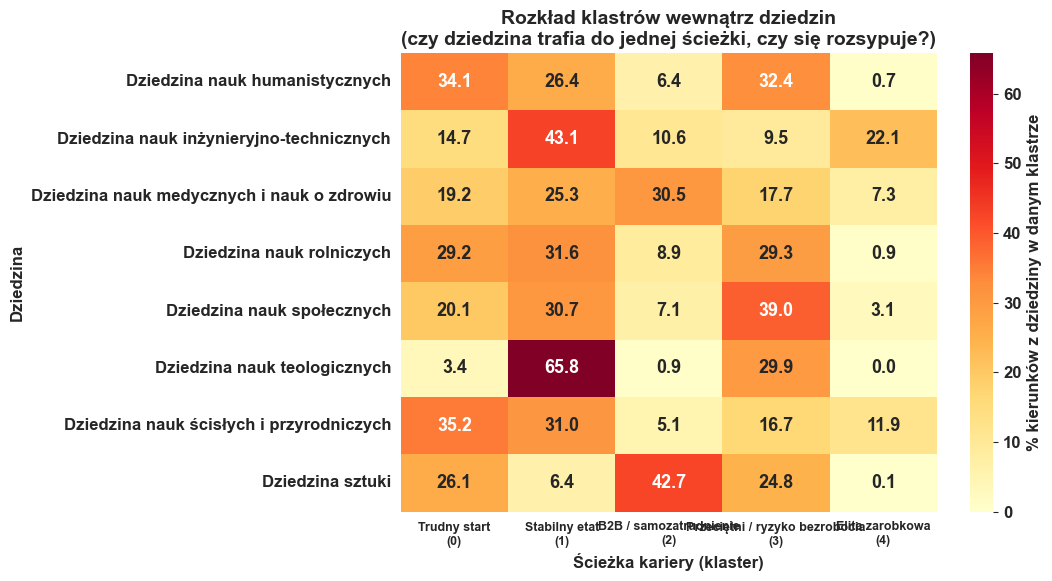

Test chi-kwadrat: chi2 = 9651.37, df = 28, p = 0.0000
=> Klastry są STATYSTYCZNIE ISTOTNIE powiązane z dziedziną studiów.
Cramer's V (siła związku, 0-1): 0.255
Interpretacja: <0.1 słaby, 0.1-0.3 umiarkowany, >0.3 silny związek

UWAGA: silny związek klaster x dziedzina = dziedzina jest dobrym
predyktorem ścieżki kariery → przydatne w części NADZOROWANEJ (supervised).


In [19]:
# ==========================================
# 14. UKRYTE POWIĄZANIA: KLASTER × DZIEDZINA (k=5)
# ==========================================
print("\n" + "="*70)
print("UKRYTE POWIĄZANIA: KLASTER × DZIEDZINA STUDIÓW")
print("="*70)

klastry_sorted = sorted(df_analiza['Klaster'].unique())
kol_nazwy = [f'{etykiety_map.get(c, c)}\n({c})' for c in klastry_sorted]

crosstab_pct = pd.crosstab(df_analiza['P_DZIEDZINA'], df_analiza['Klaster'],
                            normalize='index') * 100
crosstab_pct = crosstab_pct[klastry_sorted]   # kolejność kolumn

fig, ax = plt.subplots(figsize=(max(11, docelowe_k * 2.2), max(6, crosstab_pct.shape[0] * 0.4)))
sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=kol_nazwy,
            cbar_kws={'label': '% kierunków z dziedziny w danym klastrze'}, ax=ax)
ax.set_title('Rozkład klastrów wewnątrz dziedzin\n'
             '(czy dziedzina trafia do jednej ścieżki, czy się rozsypuje?)')
ax.set_xlabel('Ścieżka kariery (klaster)')
ax.set_ylabel('Dziedzina')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

crosstab_raw = pd.crosstab(df_analiza['P_DZIEDZINA'], df_analiza['Klaster'])
chi2, p_chi, dof, exp = stats.chi2_contingency(crosstab_raw)
print(f"Test chi-kwadrat: chi2 = {chi2:.2f}, df = {dof}, p = {p_chi:.4f}")
if p_chi < 0.05:
    print("=> Klastry są STATYSTYCZNIE ISTOTNIE powiązane z dziedziną studiów.")

# Cramer's V - siła związku, niezależna od liczby kategorii
n_obs = crosstab_raw.values.sum()
min_dim = min(crosstab_raw.shape) - 1
cramers_v = np.sqrt(chi2 / (n_obs * min_dim)) if min_dim > 0 else 0
print(f"Cramer's V (siła związku, 0-1): {cramers_v:.3f}")
print("Interpretacja: <0.1 słaby, 0.1-0.3 umiarkowany, >0.3 silny związek")
print("\nUWAGA: silny związek klaster x dziedzina = dziedzina jest dobrym")
print("predyktorem ścieżki kariery → przydatne w części NADZOROWANEJ (supervised).")



PREMIA ZA DOŚWIADCZENIE ZAWODOWE W KAŻDYM KLASTRZE

Średnia (i odchylenie) premia za doświadczenie w każdym klastrze:
                                   premia_WWZ        premia_WWB       
                                         mean    std       mean    std
Trudny start (0)                        0.088  0.123      0.090  0.676
Stabilny etat (1)                       0.141  0.169      0.240  0.554
B2B / samozatrudnienie (2)              0.172  0.210      0.262  1.056
Przeciętni / ryzyko bezrobocia (3)      0.207  0.162      0.725  1.297
Elita zarobkowa (4)                     0.284  0.333      0.212  0.505


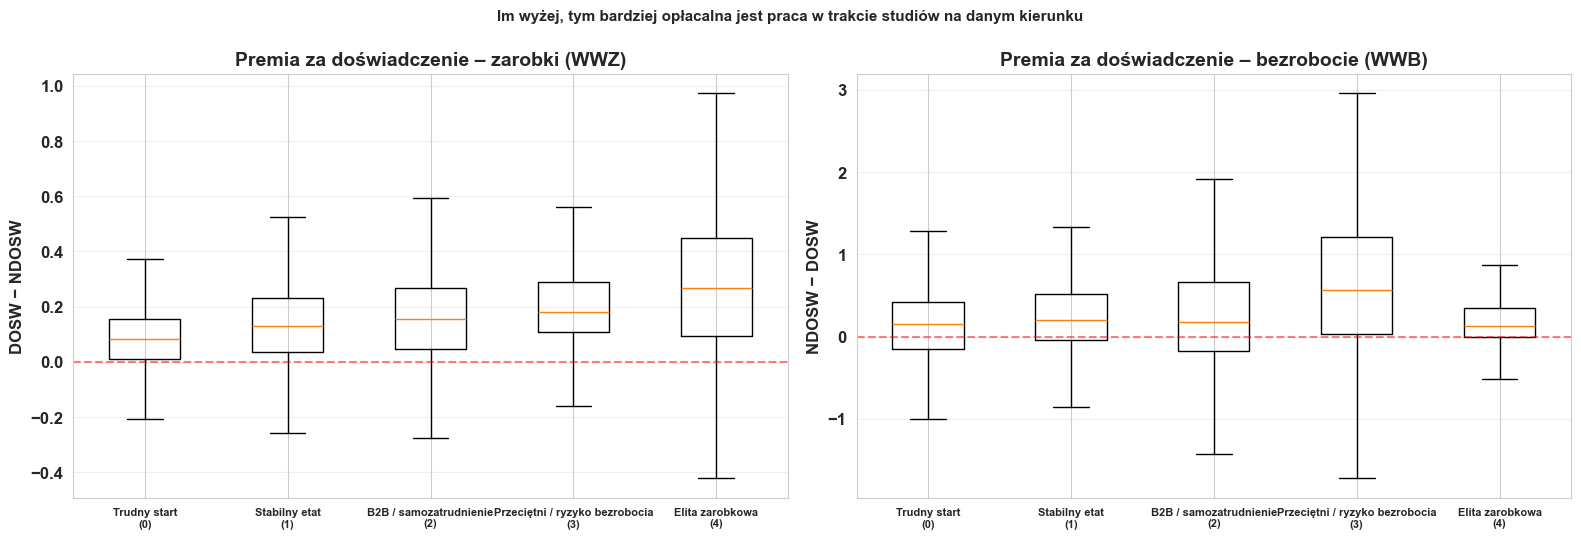

In [20]:
# ==========================================
# 15. EFEKT DOŚWIADCZENIA ZAWODOWEGO (k=5)
# ==========================================
print("\n" + "="*70)
print("PREMIA ZA DOŚWIADCZENIE ZAWODOWE W KAŻDYM KLASTRZE")
print("="*70)

klastry_sorted = sorted(df_analiza['Klaster'].unique())

df_analiza['WWZ_DOSW_avg'] = df_analiza[features_wwz_dosw].mean(axis=1)
df_analiza['WWZ_NDOSW_avg'] = df_analiza[features_wwz_ndosw].mean(axis=1)
df_analiza['premia_WWZ'] = df_analiza['WWZ_DOSW_avg'] - df_analiza['WWZ_NDOSW_avg']

df_analiza['WWB_DOSW_avg'] = df_analiza[features_wwb_dosw].mean(axis=1)
df_analiza['WWB_NDOSW_avg'] = df_analiza[features_wwb_ndosw].mean(axis=1)
df_analiza['premia_WWB'] = df_analiza['WWB_NDOSW_avg'] - df_analiza['WWB_DOSW_avg']

premia = df_analiza.groupby('Klaster')[['premia_WWZ', 'premia_WWB']].agg(['mean', 'std'])
premia.index = [f'{etykiety_map.get(c, c)} ({c})' for c in premia.index]
print("\nŚrednia (i odchylenie) premia za doświadczenie w każdym klastrze:")
print(premia.round(3))

# Boxploty z nazwami na osi X
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
xlabels = [f'{etykiety_map.get(c, c)}\n({c})' for c in klastry_sorted]
for ax, col, title, ylab in [
    (axes[0], 'premia_WWZ', 'Premia za doświadczenie – zarobki (WWZ)', 'DOSW − NDOSW'),
    (axes[1], 'premia_WWB', 'Premia za doświadczenie – bezrobocie (WWB)', 'NDOSW − DOSW'),
]:
    data = [df_analiza.loc[df_analiza['Klaster'] == c, col].dropna().values
            for c in klastry_sorted]
    ax.boxplot(data, labels=xlabels, showfliers=False)
    ax.set_title(title)
    ax.set_ylabel(ylab)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Im wyżej, tym bardziej opłacalna jest praca w trakcie studiów na danym kierunku',
             fontsize=11)
plt.tight_layout()
plt.show()


In [21]:
# ==========================================
# 16. OPIS KAŻDEGO KLASTRA (k=5)
# ==========================================
print("\n" + "="*70)
print("OPIS POSZCZEGÓLNYCH ŚCIEŻEK KARIERY (KLASTRÓW)")
print("="*70)

for c in sorted(df_analiza['Klaster'].unique()):
    sub = df_analiza[df_analiza['Klaster'] == c]
    nazwa = etykiety_map.get(c, f'Klaster {c}')
    print(f"\n--- {nazwa.upper()} (klaster {c}, N = {len(sub)}) ---")
    print(f"Top 3 dziedziny: {dict(sub['P_DZIEDZINA'].value_counts().head(3))}")
    if features_wwz_dosw and features_wwz_ndosw:
        print(f"WWZ (zarobki, P5): DOSW={sub['P_WWZ_DOSW_P5'].mean():.3f}, "
              f"NDOSW={sub['P_WWZ_NDOSW_P5'].mean():.3f}")
    if features_wwb_dosw and features_wwb_ndosw:
        print(f"WWB (bezrobocie, P5): DOSW={sub['P_WWB_DOSW_P5'].mean():.3f}, "
              f"NDOSW={sub['P_WWB_NDOSW_P5'].mean():.3f}")
    if features_etat_dosw:
        print(f"P(etat, P5): DOSW={sub['P_CZY_ETAT_DOSW_P5'].mean():.3f}, "
              f"NDOSW={sub['P_CZY_ETAT_NDOSW_P5'].mean():.3f}")
    if features_samoz_dosw:
        print(f"P(samozatr., P5): DOSW={sub['P_CZY_SAMOZ_DOSW_P5'].mean():.3f}, "
              f"NDOSW={sub['P_CZY_SAMOZ_NDOSW_P5'].mean():.3f}")
    print("Przykładowe kierunki:")
    print(sub[['P_NAZWA_UCZELNI', 'P_KIERUNEK_NAZWA']].head(5).to_string(index=False))



OPIS POSZCZEGÓLNYCH ŚCIEŻEK KARIERY (KLASTRÓW)

--- TRUDNY START (klaster 0, N = 8265) ---
Top 3 dziedziny: {'Dziedzina nauk społecznych': np.int64(2893), 'Dziedzina nauk humanistycznych': np.int64(1565), 'Dziedzina nauk inżynieryjno-technicznych': np.int64(1148)}
WWZ (zarobki, P5): DOSW=0.834, NDOSW=0.768
WWB (bezrobocie, P5): DOSW=0.519, NDOSW=0.640
P(etat, P5): DOSW=77.185, NDOSW=72.896
P(samozatr., P5): DOSW=12.105, NDOSW=8.754
Przykładowe kierunki:
                P_NAZWA_UCZELNI           P_KIERUNEK_NAZWA
            Politechnika Łódzka     Inżynieria materiałowa
            Politechnika Śląska Architektura i urbanistyka
            Politechnika Śląska                     Chemia
Uniwersytet Śląski w Katowicach                Politologia
         Uniwersytet Wrocławski                   Historia

--- STABILNY ETAT (klaster 1, N = 11649) ---
Top 3 dziedziny: {'Dziedzina nauk społecznych': np.int64(4405), 'Dziedzina nauk inżynieryjno-technicznych': np.int64(3371), 'Dziedzina nauk h

In [22]:
# ==========================================
# 17. EKSPORT WYNIKÓW
# ==========================================
output_columns = (identyfikatory + features
                  + ['Klaster', 'Klaster_nazwa',
                     'Klaster_k2', 'Klaster_k4', 'Klaster_k5',
                     'KlasterKMeans_PCA', 'KlasterKMeans_orig',
                     'Klaster_Hier', 'Klaster_GMM',
                     'outlier', 'outlier_score',
                     'PCA1', 'PCA2', 'TSNE1', 'TSNE2', 'UMAP1', 'UMAP2',
                     'premia_WWZ', 'premia_WWB'])
# Zostawiamy tylko kolumny faktycznie obecne (gdyby któraś nie powstała)
output_columns = [c for c in output_columns if c in df_analiza.columns]
df_analiza[output_columns].to_csv('wyniki_klasteryzacji.csv',
                                   sep=';', decimal=',', index=False)

loadings.to_csv('pca_loadings.csv', sep=';', decimal=',')

print("\n" + "="*70)
print("ZAPISANE PLIKI:")
print("  - wyniki_klasteryzacji.csv  (obserwacje + klastry k=2/4/5 + nazwy + UMAP)")
print("  - pca_loadings.csv          (ładunki PCA)")
print("="*70)
print("ANALIZA ZAKOŃCZONA")

# ---- Most do CZĘŚCI II (nadzorowanej) ----
# Część II jest w TYM SAMYM notebooku (poniżej), więc korzysta bezpośrednio
# z obiektów w pamięci: df_analiza, features, identyfikatory, etykiety_map,
# nazwy_map, docelowe_k, df. CSV powyżej to checkpoint na wypadek pracy offline.
print("\nObiekty przekazane do CZĘŚCI II (w pamięci): df_analiza, features,")
print("identyfikatory, etykiety_map, nazwy_map, docelowe_k, df")



ZAPISANE PLIKI:
  - wyniki_klasteryzacji.csv  (obserwacje + klastry k=2/4/5 + nazwy + UMAP)
  - pca_loadings.csv          (ładunki PCA)
ANALIZA ZAKOŃCZONA

Obiekty przekazane do CZĘŚCI II (w pamięci): df_analiza, features,
identyfikatory, etykiety_map, nazwy_map, docelowe_k, df


---
# CZĘŚĆ II — UCZENIE NADZOROWANE

Od tego miejsca wykorzystujemy wynik części I (klastry k=5 jako ścieżki kariery)
do zbudowy modelu nadzorowanego. Wszystkie zmienne z części I są dostępne w pamięci:
`df_analiza`, `features`, `identyfikatory`, `etykiety_map`, `nazwy_map`, `docelowe_k`, `df`.

**Cel (wg ustaleń z promotorem):**
1. **Regresja jako test statystyczny** — istotność efektów (premia za doświadczenie), nie R².
2. **Logit wielomianowy** — przewidywanie 5-klasowej ścieżki ze zmiennych strukturalnych.
3. **Random Forest + SHAP** — pokazanie, że RF bije logit, a XAI odzyskuje interpretację.

**Anty-cyrkularność:** target (ścieżka) powstał ze zmiennych WYNIKOWYCH (WWZ/WWB/ETAT/...),
więc jako PREDYKTORY używamy wyłącznie zmiennych **strukturalnych** (dziedzina, poziom,
forma, profil, województwo, liczność, %doświadczenia) — opisujących kierunek PRZED rynkiem pracy.

In [23]:
# ==========================================
# 18. TARGET (ścieżka kariery) + PREDYKTORY STRUKTURALNE
# ==========================================
# TARGET: 5-klasowa ścieżka kariery z klastrów k=5 (powstała ze zmiennych WYNIKOWYCH).
df_sup = df_analiza.copy()
df_sup['sciezka'] = df_sup['Klaster']                    # 0..4 (numer klastra)
df_sup['sciezka_nazwa'] = df_sup['Klaster'].map(etykiety_map)

# PREDYKTORY STRUKTURALNE — opisują kierunek/uczelnię/kohortę PRZED rynkiem pracy.
# To jedyne zmienne wolne od cyrkularności z targetem.
# Sprawdzamy obecność w ŹRÓDŁOWYM df (część I trzymała w df_analiza tylko
# identyfikatory + features, więc większość predyktorów strukturalnych trzeba dociągnąć).
predyktory_kat = [c for c in ['P_DZIEDZINA', 'P_POZIOM', 'P_FORMA', 'P_PROFIL', 'P_WOJ']
                  if c in df.columns]                # kategoryczne
predyktory_num = [c for c in ['P_N', 'P_PROC_DOSW', 'P_ROKDYP']
                  if c in df.columns]                # liczbowe
predyktory = predyktory_kat + predyktory_num

# Dociągamy te predyktory, których nie ma jeszcze w df_sup, ze źródłowego df.
brakujace = [c for c in predyktory if c not in df_sup.columns]
if brakujace:
    print(f"Dociągam ze źródłowego df: {brakujace}")
    klucz = ['P_NAZWA_UCZELNI', 'P_KIERUNEK_NAZWA']
    df_sup = df_sup.merge(df[klucz + brakujace].drop_duplicates(klucz),
                          on=klucz, how='left')

print("Predyktory KATEGORYCZNE:", predyktory_kat)
print("Predyktory LICZBOWE:    ", predyktory_num)
print("\nRozkład targetu (ścieżka kariery):")
print(df_sup['sciezka_nazwa'].value_counts().to_string())

# Sprawdzenie braków w predyktorach
print("\nBraki w predyktorach:")
print(df_sup[predyktory].isna().sum().to_string())

Dociągam ze źródłowego df: ['P_POZIOM', 'P_FORMA', 'P_PROFIL', 'P_WOJ', 'P_N', 'P_PROC_DOSW', 'P_ROKDYP']
Predyktory KATEGORYCZNE: ['P_DZIEDZINA', 'P_POZIOM', 'P_FORMA', 'P_PROFIL', 'P_WOJ']
Predyktory LICZBOWE:     ['P_N', 'P_PROC_DOSW', 'P_ROKDYP']

Rozkład targetu (ścieżka kariery):
sciezka_nazwa
Stabilny etat                     11649
Przeciętni / ryzyko bezrobocia     9969
Trudny start                       8265
B2B / samozatrudnienie             4444
Elita zarobkowa                    2853

Braki w predyktorach:
P_DZIEDZINA    0
P_POZIOM       0
P_FORMA        0
P_PROFIL       0
P_WOJ          7
P_N            0
P_PROC_DOSW    0
P_ROKDYP       0


In [24]:
# ==========================================
# 19. PRZYGOTOWANIE DANYCH DO MODELI
# ==========================================
# Usuwamy wiersze bez kompletu predyktorów (po dociągnięciu struktury).
df_model = df_sup.dropna(subset=predyktory + ['sciezka']).reset_index(drop=True)
print(f"Obserwacji do modelowania: {len(df_model)} (z {len(df_sup)})")

X_kat = df_model[predyktory_kat].astype('category')
X_num = df_model[predyktory_num].astype(float)
y = df_model['sciezka'].astype(int)

# One-hot wspólny dla logitu i RF. drop_first=False: zostają wszystkie poziomy —
# regularyzacja sklearn radzi sobie ze współliniowością, a współczynniki czyta się per poziom.
X_ohe = pd.get_dummies(df_model[predyktory], columns=predyktory_kat, drop_first=False)
# Zabezpieczenie: usuń ewentualne zduplikowane nazwy kolumn (psują X[c] -> DataFrame)
X_ohe = X_ohe.loc[:, ~X_ohe.columns.duplicated()].copy()
print(f"Cech po one-hot: {X_ohe.shape[1]}")

X_train, X_test, y_train, y_test = train_test_split(
    X_ohe, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")

Obserwacji do modelowania: 37173 (z 37180)
Cech po one-hot: 35
Train: 27879  Test: 9294


## 20. Regresja jako test statystyczny — premia za doświadczenie

Zgodnie z notatką promotora: regresja służy **wyłapaniu istotności**, nie predykcji.
Tu testujemy, czy premia za doświadczenie (DOSW − NDOSW w zarobkach) różni się
istotnie między dziedzinami i czy efekt jest nieliniowy. Zmienna zależna `premia_WWZ`
policzona w części nienadzorowanej.

In [25]:
# ==========================================
# 20. REGRESJA OLS — test istotności premii za doświadczenie (KONFIGUROWALNA)
# ==========================================
# Cel (wg promotora): p-wartości i istotność efektów, NIE maksymalizacja R^2.
# Premia_WWZ = (zarobki z doświadczeniem) − (zarobki bez doświadczenia), policzona w cz. I.
#
# Specyfikacja modelu jest sterowana konfiguracją poniżej:
#   PREDYKTORY_OLS: 'NAZWA_KOLUMNY': {'typ': 'kat'|'num', 'log': True/False (tylko num)}
#     - 'kat' wchodzi jako czynnik C(...) (dummy-coding)
#     - 'num' wchodzi liniowo; 'log': True nakłada log1p (dla zmiennych skośnych)
#   INTERAKCJE_OLS: pary kolumn, np. ('P_DZIEDZINA', 'P_PROFIL') daje człon
#     C(dziedzina):C(profil); działa też dla par num:num i kat:num.
# Zmienna musi istnieć w df_model (predyktory strukturalne dociągnięto w sekcji 18).

PREDYKTORY_OLS = {
    'P_DZIEDZINA': {'typ': 'kat'},
    'P_PROFIL':    {'typ': 'kat'},
    'P_WOJ':       {'typ': 'kat'},    # region – rynki pracy różnią się geograficznie
    'P_POZIOM':    {'typ': 'kat'},    # licencjat vs magister – inna pozycja startowa
    'P_ROKDYP':    {'typ': 'kat'},    # rocznik dyplomu – kontrola koniunktury
    'P_N':         {'typ': 'num', 'log': True},   # liczność kohorty (log, bo skośna)
}

INTERAKCJE_OLS = [
    ('P_DZIEDZINA', 'P_PROFIL'),
]

# ---- Budowa danych i formuły z powyższej konfiguracji ----
import re as _re
reg_df = df_model.copy()

def _clean_name(col):
    """Bezpieczna nazwa zmiennej do formuły patsy (bez spacji/znaków specjalnych)."""
    return 'v_' + _re.sub(r'[^0-9A-Za-z]', '_', str(col))

# Walidacja: zostaw tylko zmienne faktycznie obecne w danych
brak = [c for c in PREDYKTORY_OLS if c not in reg_df.columns]
if brak:
    print(f"UWAGA: pomijam (brak w df_model): {brak}")
PREDYKTORY_OLS = {c: spec for c, spec in PREDYKTORY_OLS.items() if c in reg_df.columns}

# Zbuduj kolumny robocze + człony formuły
terminy, termin_kol = [], {}
for col, spec in PREDYKTORY_OLS.items():
    vname = _clean_name(col)
    if spec['typ'] == 'kat':
        reg_df[vname] = reg_df[col].astype(str)
        term = f'C({vname})'
    else:  # num
        seria = reg_df[col].astype(float)
        if spec.get('log'):
            seria = np.log1p(seria)
        reg_df[vname] = seria
        term = vname
    terminy.append(term)
    termin_kol[col] = (vname, spec['typ'])

# Człony interakcji
for a, b in INTERAKCJE_OLS:
    if a in termin_kol and b in termin_kol:
        (va, ta), (vb, tb) = termin_kol[a], termin_kol[b]
        ea = f'C({va})' if ta == 'kat' else va
        eb = f'C({vb})' if tb == 'kat' else vb
        terminy.append(f'{ea}:{eb}')
    else:
        print(f"UWAGA: pomijam interakcję ({a}, {b}) – brak którejś zmiennej w predyktorach.")

formula = 'premia_WWZ ~ ' + ' + '.join(terminy)

# ---- Dopasowanie modelu ----
model_ols = smf.ols(formula, data=reg_df).fit()

print("=== OLS: premia za doświadczenie — TEST ISTOTNOŚCI ===")
print(f"Predyktory: {list(PREDYKTORY_OLS.keys())}")
print(f"Interakcje: {INTERAKCJE_OLS}")
print(f"\nFormuła: {formula}")
print(f"\nObserwacji: {int(model_ols.nobs)}  |  parametrów: {int(model_ols.df_model)+1}")
print(f"F-test całego modelu: F={model_ols.fvalue:.2f}, p={model_ols.f_pvalue:.3e}")
print(f"\n--- DOPASOWANIE (do porównań między specyfikacjami) ---")
print(f"  R^2:            {model_ols.rsquared:.4f}")
print(f"  Adjusted R^2:   {model_ols.rsquared_adj:.4f}   <- karze za liczbę zmiennych")
print(f"  AIC:            {model_ols.aic:.1f}            <- niższe = lepszy model po karze")
print(f"  BIC:            {model_ols.bic:.1f}")
print("  (R^2 NIE jest celem; adj.R^2/AIC porównują, czy nowe zmienne realnie wnoszą sygnał)")

# Istotne efekty (pojedyncze poziomy) – tylko poglądowo; pełną istotność czynników daje ANOVA (21)
coefs = model_ols.summary2().tables[1]
istotne = coefs[coefs['P>|t|'] < 0.05].sort_values('P>|t|')
print(f"\nIstotnych POJEDYNCZYCH poziomów (p<0.05): {len(istotne)} / {len(coefs)}")
print("(uwaga: to kontrasty pojedynczych poziomów vs referencja – siłę CAŁYCH")
print(" czynników ocenia ANOVA typu II + eta^2 w sekcji 21)")
print("Top 15 najistotniejszych poziomów:")
print(istotne.head(15)[['Coef.', 'Std.Err.', 't', 'P>|t|']].round(4).to_string())


=== OLS: premia za doświadczenie — TEST ISTOTNOŚCI ===
Predyktory: ['P_DZIEDZINA', 'P_PROFIL', 'P_WOJ', 'P_POZIOM', 'P_ROKDYP', 'P_N']
Interakcje: [('P_DZIEDZINA', 'P_PROFIL')]

Formuła: premia_WWZ ~ C(v_P_DZIEDZINA) + C(v_P_PROFIL) + C(v_P_WOJ) + C(v_P_POZIOM) + C(v_P_ROKDYP) + v_P_N + C(v_P_DZIEDZINA):C(v_P_PROFIL)

Obserwacji: 37173  |  parametrów: 47
F-test całego modelu: F=21.88, p=3.227e-178

--- DOPASOWANIE (do porównań między specyfikacjami) ---
  R^2:            0.0264
  Adjusted R^2:   0.0252   <- karze za liczbę zmiennych
  AIC:            -18822.9            <- niższe = lepszy model po karze
  BIC:            -18422.3
  (R^2 NIE jest celem; adj.R^2/AIC porównują, czy nowe zmienne realnie wnoszą sygnał)

Istotnych POJEDYNCZYCH poziomów (p<0.05): 15 / 48
(uwaga: to kontrasty pojedynczych poziomów vs referencja – siłę CAŁYCH
 czynników ocenia ANOVA typu II + eta^2 w sekcji 21)
Top 15 najistotniejszych poziomów:
                                                                  

In [26]:
# ==========================================
# 21. ANOVA (typ II) + ROZMIAR EFEKTU (eta^2) — istotność i SIŁA czynników
# ==========================================
anova_tab = anova_lm(model_ols, typ=2)

# Eta^2 = udział danego czynnika w CAŁKOWITEJ zmienności (sum_sq czynnika / suma wszystkich sum_sq).
# Partial eta^2 = sum_sq czynnika / (sum_sq czynnika + sum_sq reszt) — efekt "oczyszczony".
ss_total = anova_tab['sum_sq'].sum()
ss_resid = anova_tab.loc['Residual', 'sum_sq']
anova_tab['eta_sq'] = anova_tab['sum_sq'] / ss_total
anova_tab['partial_eta_sq'] = anova_tab['sum_sq'] / (anova_tab['sum_sq'] + ss_resid)
# eta^2 nie ma sensu dla wiersza Residual
anova_tab.loc['Residual', ['eta_sq', 'partial_eta_sq']] = float('nan')

print("ANOVA typu II — istotność (PR>F) ORAZ rozmiar efektu (eta^2):")
print(anova_tab.round(4).to_string())

print("\nInterpretacja eta^2 (Cohen, orientacyjnie): 0.01 mały, 0.06 średni, 0.14 duży efekt.")
print("UWAGA: przy bardzo dużej próbie (df reszt =", int(anova_tab.loc['Residual','df']),
      ") niemal każdy efekt jest ISTOTNY,")
print("dlatego o znaczeniu praktycznym decyduje eta^2 (siła), a nie samo p.")

# Czytelne podsumowanie słowne, posortowane wg siły efektu
print("\n--- Ranking czynników wg rozmiaru efektu (eta^2) ---")
czynniki = anova_tab.drop(index='Residual').sort_values('eta_sq', ascending=False)
for nazwa, row in czynniki.iterrows():
    istotny = "istotny" if row['PR(>F)'] < 0.05 else "NIEistotny"
    sila = ("duży" if row['eta_sq'] >= 0.14 else
            "średni" if row['eta_sq'] >= 0.06 else
            "mały" if row['eta_sq'] >= 0.01 else "znikomy")
    print(f"  {nazwa:28s} eta^2={row['eta_sq']:.4f} ({sila:7s}) | p={row['PR(>F)']:.3g} ({istotny})")

print("\nWniosek do pracy: liczy się NIE 'co jest istotne' (przy N≈{} prawie wszystko),".format(len(reg_df)))
print("lecz KTÓRY czynnik ma realną siłę. Porównaj kolumnę eta^2 — zwykle dziedzina")
print("dominuje o rząd wielkości nad profilem i interakcją, a logN jest znikomy.")
print("\nInterakcja C(dziedzina):C(profil) istotna → efekt doświadczenia zależy od")
print("KOMBINACJI dziedziny i profilu (warunkowość/nieliniowość — uzasadnia użycie RF).")


ANOVA typu II — istotność (PR>F) ORAZ rozmiar efektu (eta^2):
                                   sum_sq       df        F  PR(>F)  eta_sq  partial_eta_sq
C(v_P_DZIEDZINA)                  19.8373      7.0  80.4111  0.0000  0.0147          0.0149
C(v_P_PROFIL)                      1.8433      2.0  26.1521  0.0000  0.0014          0.0014
C(v_P_WOJ)                        10.3475     15.0  19.5738  0.0000  0.0077          0.0078
C(v_P_POZIOM)                      0.1109      2.0   1.5732  0.2074  0.0001          0.0001
C(v_P_ROKDYP)                      2.7100      6.0  12.8159  0.0000  0.0020          0.0021
C(v_P_DZIEDZINA):C(v_P_PROFIL)     2.6417     14.0   5.3541  0.0000  0.0020          0.0020
v_P_N                              0.3252      1.0   9.2276  0.0024  0.0002          0.0002
Residual                        1308.4177  37126.0      NaN     NaN     NaN             NaN

Interpretacja eta^2 (Cohen, orientacyjnie): 0.01 mały, 0.06 średni, 0.14 duży efekt.
UWAGA: przy bardzo dużej

## 22. Logit wielomianowy — przewidywanie ścieżki ze zmiennych strukturalnych

Model bazowy interpretowalny. Daje współczynniki/ilorazy szans i istotności.
Predyktory: wyłącznie strukturalne (anty-cyrkularność).

In [27]:
# ==========================================
# 22. MULTINOMIAL LOGIT (statsmodels — poglądowo: pseudo R^2 + OR bez CI)
# ==========================================
# Rola: jakościowy obraz kierunków efektów (ilorazy szans). Formalny TEST ISTOTNOŚCI
# pełni OLS+ANOVA z sekcji 20-21 (logit ma quasi-separację na rzadkich dziedzinach,
# przez co błędy standardowe są niewiarygodne — świadomie ich tu nie używamy).


_num_cols = [c for c in X_train.columns
             if not set(pd.Series(X_train[c]).dropna().unique().tolist())
                    <= {0, 1, 0.0, 1.0, True, False}]
print(f"Standaryzuję kolumny liczbowe przed MNLogit: {_num_cols}")

_scaler_sm = SS()
X_train_sm = X_train.astype(float).copy()
if _num_cols:
    X_train_sm[_num_cols] = _scaler_sm.fit_transform(X_train_sm[_num_cols])

X_sm = sm.add_constant(X_train_sm, has_constant='add')

# Tylko nieregularyzowane dopasowanie (lbfgs). Jeśli nie zbiegnie — raportujemy to i kończymy.
try:
    mnlogit = sm.MNLogit(y_train.values, X_sm).fit(method='lbfgs', maxiter=5000, disp=False)
except Exception as e:
    mnlogit = None
    print(f"MNLogit nie zbiegł ({e}).")

print("=== MULTINOMIAL LOGIT (poglądowo) ===")
zbiegl = (mnlogit is not None and np.isfinite(getattr(mnlogit, 'llf', np.nan))
          and getattr(mnlogit, 'prsquared', -1) >= 0)

if not zbiegl:
    print("Model nie zbiegł poprawnie — interpretację istotności opieramy na OLS/ANOVA (sekcja 21).")
else:
    print(f"Pseudo R^2 (McFadden): {mnlogit.prsquared:.3f}")
    print(f"LLR p-value (model vs null): {mnlogit.llr_pvalue:.3e}")

    klasy_nieref = sorted(set(y_train.unique()))[1:]
    ref = sorted(set(y_train.unique()))[0]
    print(f"\nKlasa referencyjna: {ref} = {etykiety_map.get(ref, ref)}")
    print("Iloraz szans (OR) = exp(coef): OR>1 zwiększa szansę danej ścieżki vs referencyjna.")
    print("(bez przedziałów ufności — patrz nota wyżej; OR tylko orientacyjnie, co do kierunku)")

    params = mnlogit.params
    for j, kl in enumerate(klasy_nieref):
        nazwa = etykiety_map.get(kl, f'klasa {kl}')
        or_j = np.exp(params.iloc[:, j])
        tab = pd.DataFrame({'OR': or_j}).drop(index='const', errors='ignore')
        tab['abs_logOR'] = np.abs(np.log(tab['OR'].replace(0, np.nan)))
        top = tab.sort_values('abs_logOR', ascending=False).head(50)
        print(f"\n--- Ścieżka: {nazwa} ({kl}) vs {etykiety_map.get(ref, ref)} ---")
        print(top[['OR']].round(3).to_string())

Standaryzuję kolumny liczbowe przed MNLogit: ['P_N', 'P_PROC_DOSW', 'P_ROKDYP']
=== MULTINOMIAL LOGIT (poglądowo) ===
Pseudo R^2 (McFadden): 0.126
LLR p-value (model vs null): 0.000e+00

Klasa referencyjna: 0 = Trudny start
Iloraz szans (OR) = exp(coef): OR>1 zwiększa szansę danej ścieżki vs referencyjna.
(bez przedziałów ufności — patrz nota wyżej; OR tylko orientacyjnie, co do kierunku)

--- Ścieżka: Stabilny etat (1) vs Trudny start ---
                                                            OR
P_POZIOM_JM                                             13.688
P_DZIEDZINA_Dziedzina sztuki                             0.229
P_POZIOM_1                                               3.450
P_DZIEDZINA_Dziedzina nauk inżynieryjno-technicznych     2.799
P_DZIEDZINA_Dziedzina nauk teologicznych                 1.698
P_PROC_DOSW                                              1.649
P_WOJ_6.0                                                0.700
P_WOJ_18.0                                          

## 23. Random Forest vs logit — czy nieliniowy model wygrywa?

=== PORÓWNANIE MODELI (zbiór testowy) ===

Logit (multinomial):
  Balanced accuracy: 0.428
  Macro F1:          0.343

Random Forest:
  Balanced accuracy: 0.535
  Macro F1:          0.495

Logit CV balanced acc: 0.427 +/- 0.007

RF CV balanced acc: 0.537 +/- 0.005


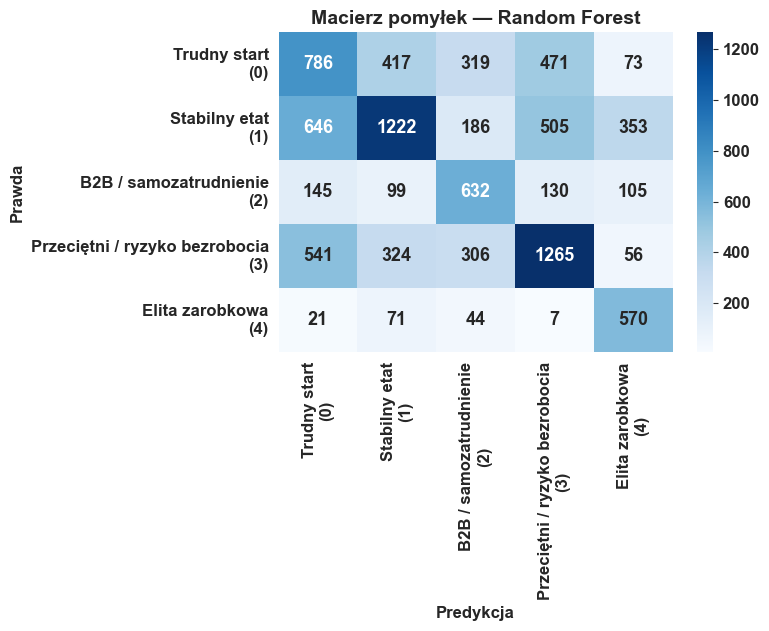

In [28]:
# ==========================================
# 23. RANDOM FOREST + PORÓWNANIE Z LOGITEM
# ==========================================
# .astype(float): one-hot z get_dummies bywa typu bool/object; sklearn to przełyka,
# ale SHAP (sekcja 24) wymaga jednolitej macierzy liczbowej. Ujednolicamy raz, tutaj.
X_train_f = X_train.astype(float)
X_test_f  = X_test.astype(float)
X_ohe_f   = X_ohe.astype(float)

rf = RandomForestClassifier(n_estimators=400, max_depth=None, min_samples_leaf=5,
                            class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_f, y_train)
y_pred_rf = rf.predict(X_test_f)

# Logit sklearn (uczciwe porównanie predykcyjne tą samą metodą walidacji)
logit_sk = LogisticRegression(max_iter=2000, class_weight='balanced')
logit_sk.fit(X_train_f, y_train)
y_pred_lsk = logit_sk.predict(X_test_f)

print("=== PORÓWNANIE MODELI (zbiór testowy) ===")
for nazwa, yp in [('Logit (multinomial)', y_pred_lsk), ('Random Forest', y_pred_rf)]:
    print(f"\n{nazwa}:")
    print(f"  Balanced accuracy: {balanced_accuracy_score(y_test, yp):.3f}")
    print(f"  Macro F1:          {f1_score(y_test, yp, average='macro'):.3f}")

# Walidacja krzyżowa (stabilność wyniku)
cv = StratifiedKFold(5, shuffle=True, random_state=42)
for nazwa, mdl in [('Logit', logit_sk), ('RF', rf)]:
    sc = cross_val_score(mdl, X_ohe_f, y, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
    print(f"\n{nazwa} CV balanced acc: {sc.mean():.3f} +/- {sc.std():.3f}")

# Macierz pomyłek RF z nazwami ścieżek
labels_sorted = sorted(y.unique())
nazwy_osi = [f'{etykiety_map.get(c,c)}\n({c})' for c in labels_sorted]
cm = confusion_matrix(y_test, y_pred_rf, labels=labels_sorted)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nazwy_osi, yticklabels=nazwy_osi, ax=ax)
ax.set_xlabel('Predykcja'); ax.set_ylabel('Prawda')
ax.set_title('Macierz pomyłek — Random Forest')
plt.tight_layout(); plt.show()

# Model wyjaśniany SHAP-em w sekcji 24; po strojeniu (sekcja 23b) można tu podstawić rf_tuned.
rf_final = rf


In [29]:
# ==========================================
# 23b. STROJENIE RANDOM FOREST — RandomizedSearchCV
# ==========================================
# Losowe przeszukiwanie hiperparametrów (40 prób, CV 4-krotna) sprawdza, czy bazowy
# RF z sekcji 23 zostawia zapas jakości. Porównanie na tym samym zbiorze testowym.
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators':     randint(400, 900),
    'max_depth':        [None, 10, 15, 20, 30],
    'min_samples_leaf': randint(3, 30),
    'min_samples_split':randint(2, 20),
    'max_features':     ['sqrt', 'log2', 0.3, 0.5],
}
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
search = RandomizedSearchCV(
    rf_base, param_dist, n_iter=40, cv=StratifiedKFold(4, shuffle=True, random_state=42),
    scoring='balanced_accuracy', random_state=42, n_jobs=-1, verbose=1
)
search.fit(X_train_f, y_train)
print("Najlepsze parametry:", search.best_params_)
print(f"CV balanced acc:     {search.best_score_:.3f}")

rf_tuned = search.best_estimator_
y_pred_tuned = rf_tuned.predict(X_test_f)
print(f"Test balanced acc (strojony): {balanced_accuracy_score(y_test, y_pred_tuned):.3f}")
print(f"Test balanced acc (bazowy):   {balanced_accuracy_score(y_test, y_pred_rf):.3f}")


Fitting 4 folds for each of 40 candidates, totalling 160 fits
Najlepsze parametry: {'max_depth': 15, 'max_features': 0.3, 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 500}
CV balanced acc:     0.529
Test balanced acc (strojony): 0.535
Test balanced acc (bazowy):   0.535


## 24. XAI — SHAP dla Random Forest

SHAP pokazuje, KTÓRE strukturalne cechy pchają absolwenta na daną ścieżkę.
To merytoryczny rdzeń: nie „RF coś znalazł", tylko „dziedzina X / profil praktyczny
podnoszą p-stwo ścieżki B2B" itd.

Klas: 5 | macierzy SHAP: 5 | kształt jednej: (800, 35)

Globalna ważność cech (średni |SHAP| po wszystkich ścieżkach):
P_DZIEDZINA_Dziedzina nauk inżynieryjno-technicznych      0.0361
P_PROC_DOSW                                               0.0264
P_DZIEDZINA_Dziedzina nauk społecznych                    0.0222
P_FORMA_S                                                 0.0191
P_FORMA_N                                                 0.0182
P_N                                                       0.0175
P_DZIEDZINA_Dziedzina nauk medycznych i nauk o zdrowiu    0.0161
P_POZIOM_2                                                0.0154
P_DZIEDZINA_Dziedzina nauk humanistycznych                0.0112
P_WOJ_14.0                                                0.0098
P_DZIEDZINA_Dziedzina sztuki                              0.0085
P_PROFIL_O                                                0.0082
P_ROKDYP                                                  0.0082
P_POZIOM_JM                         

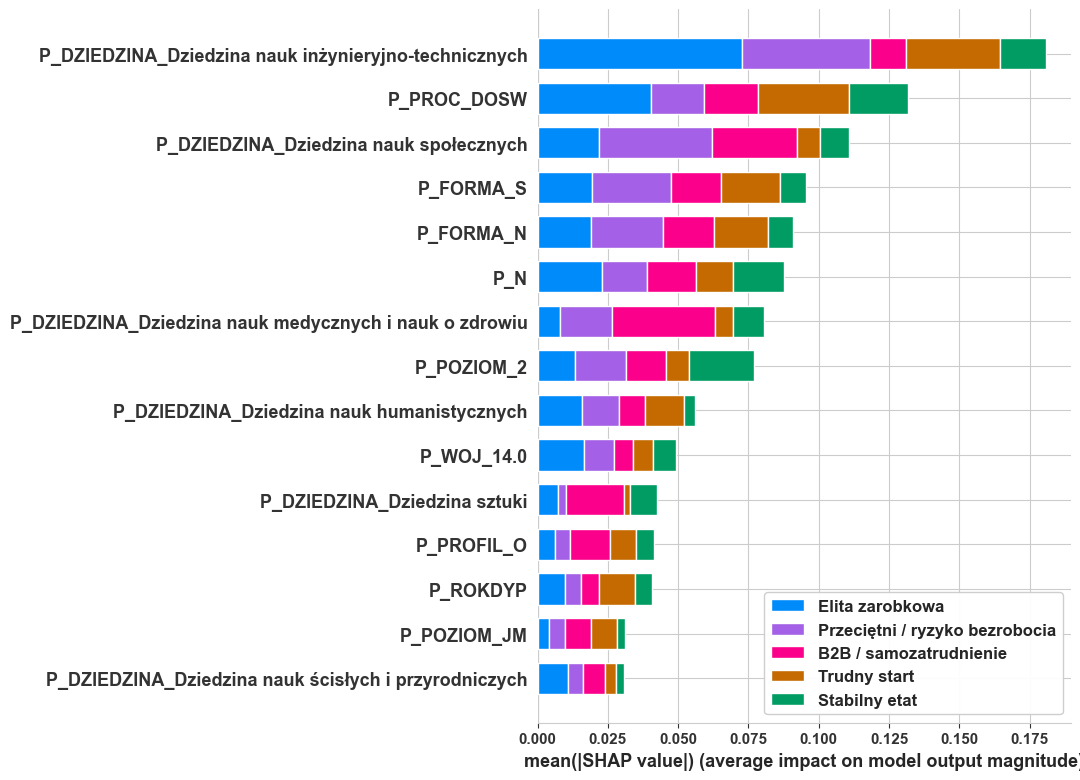

In [30]:
# ==========================================
# 24. SHAP — wyjaśnienie Random Forest (globalnie)
# ==========================================
# Szczegóły techniczne: .astype(float), bo TreeExplainer nie rzutuje bool/object;
# check_additivity=False, bo klasyfikacyjny RandomForest bywa o ułamek niespójny
# w teście addytywności (znana własność biblioteki, nie błąd danych); kształt
# shap_values różni się między wersjami SHAP, stąd normalizacja do listy [per klasa].

expl = shap.TreeExplainer(rf_final)
X_shap = X_test.astype(float).sample(min(800, len(X_test)), random_state=42)
raw_sv = expl.shap_values(X_shap, check_additivity=False)

# Normalizacja kształtu: różne wersje SHAP zwracają albo listę macierzy (po klasie),
# albo tablicę 3D [obs, cechy, klasy]. Sprowadzamy do listy [n_klas] macierzy [obs, cechy].
def _to_per_class(sv, n_classes):
    if isinstance(sv, list):
        return sv
    arr = np.asarray(sv)
    if arr.ndim == 3:
        # może być [obs, cechy, klasy] lub [klasy, obs, cechy]
        if arr.shape[-1] == n_classes:
            return [arr[:, :, k] for k in range(n_classes)]
        if arr.shape[0] == n_classes:
            return [arr[k] for k in range(n_classes)]
    # binarny/pojedynczy przypadek
    return [arr]

shap_list = _to_per_class(raw_sv, len(labels_sorted))
print(f"Klas: {len(labels_sorted)} | macierzy SHAP: {len(shap_list)} | "
      f"kształt jednej: {np.asarray(shap_list[0]).shape}")

# Globalna ważność cech (średni |SHAP| po wszystkich klasach)
mean_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_list], axis=0)
imp = pd.Series(mean_abs, index=X_shap.columns).sort_values(ascending=False)
print("\nGlobalna ważność cech (średni |SHAP| po wszystkich ścieżkach):")
print(imp.head(15).round(4).to_string())

# Summary plot (bar) — globalny wkład cech, z podziałem na ścieżki
shap.summary_plot(shap_list, X_shap, plot_type='bar',
                  class_names=[etykiety_map.get(c, str(c)) for c in labels_sorted],
                  max_display=15, show=False, plot_size=(11, 8))
ax = plt.gca()
ax.legend(loc='lower right', bbox_to_anchor=(1.0, 0.0), frameon=True, framealpha=0.95)
plt.tight_layout()
plt.show()


--- SHAP dla ścieżki: Trudny start (0) ---


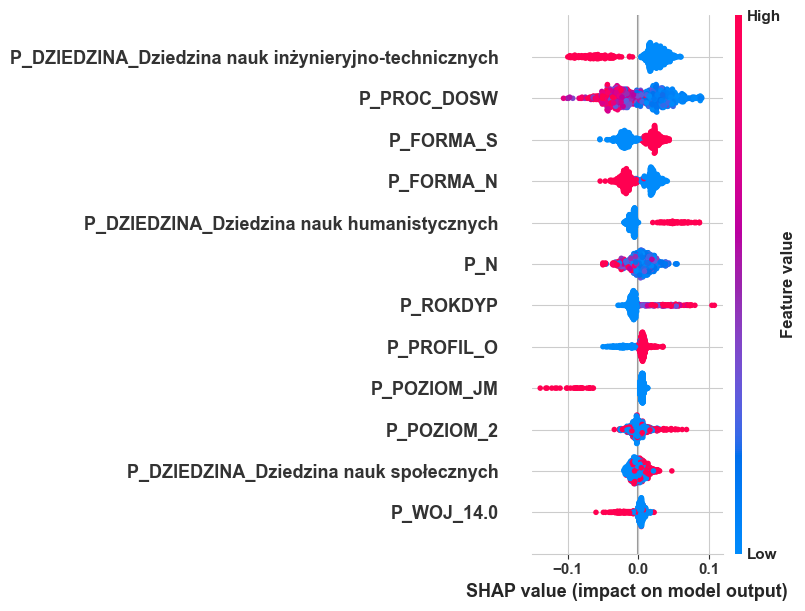


--- SHAP dla ścieżki: Stabilny etat (1) ---


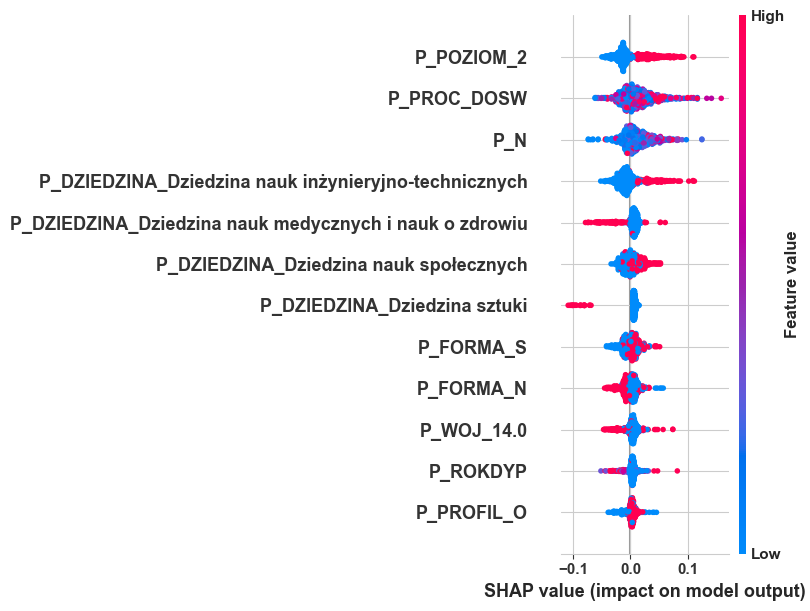


--- SHAP dla ścieżki: B2B / samozatrudnienie (2) ---


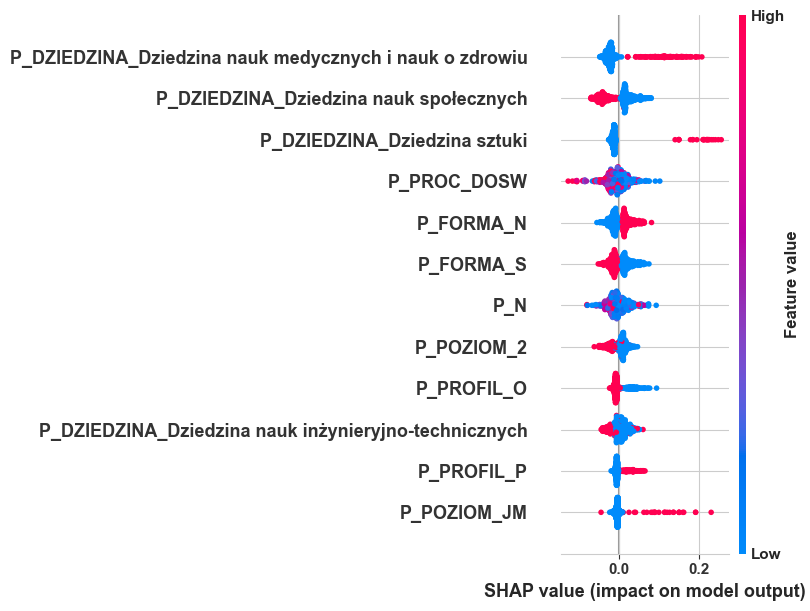


--- SHAP dla ścieżki: Przeciętni / ryzyko bezrobocia (3) ---


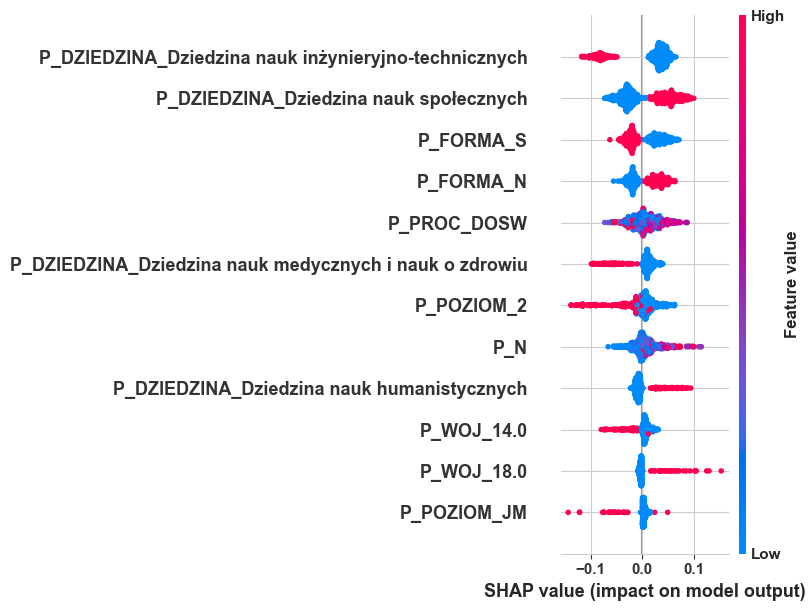


--- SHAP dla ścieżki: Elita zarobkowa (4) ---


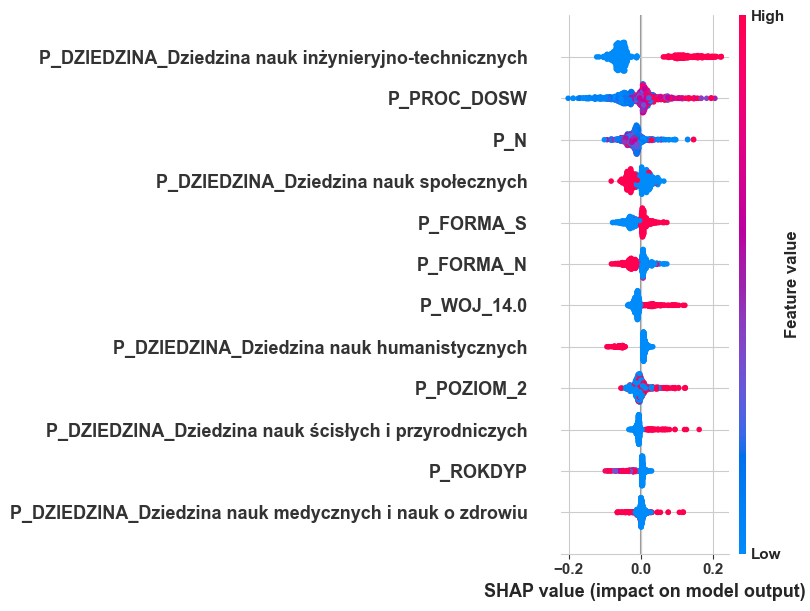

In [31]:
# ==========================================
# 24b. SHAP — per ścieżka (która cecha pcha na KTÓRĄ ścieżkę)
# ==========================================
# Beeswarm dla każdej ścieżki osobno: kolor = wartość cechy, oś X = wpływ na P(ścieżka).
# Korzysta z shap_list (znormalizowane w sekcji 24).
for idx, c in enumerate(labels_sorted):
    print(f"\n--- SHAP dla ścieżki: {etykiety_map.get(c, c)} ({c}) ---")
    shap.summary_plot(shap_list[idx], X_shap, max_display=12, show=True)


In [32]:
# ==========================================
# 25. PODSUMOWANIE — logit vs RF + spójność z XAI
# ==========================================
if mnlogit is not None and np.isfinite(getattr(mnlogit, 'llf', np.nan)):
    logit_opis = (f"pseudo-R2={mnlogit.prsquared:.3f}, model istotny "
                  f"(LLR p={mnlogit.llr_pvalue:.1e})")
else:
    logit_opis = "model nie zbiegł — istotność oparta na OLS/ANOVA (sekcje 20-21)"

print("="*70)
print("PODSUMOWANIE CZĘŚCI NADZOROWANEJ")
print("="*70)
print(f"""
1. REGRESJA jako test: ANOVA wskazała istotne czynniki premii za doświadczenie
   (sekcje 20-21) — to odpowiedź na pytanie 'co istotnie różnicuje', nie 'jak dobrze
   przewidujemy'.

2. LOGIT wielomianowy: {logit_opis}.
   Daje ilorazy szans i kierunki efektów predyktorów.

3. RANDOM FOREST vs LOGIT: porównanie balanced accuracy w sekcji 23 — jeśli RF > logit,
   to znak, że zależność predyktory→ścieżka jest NIELINIOWA / ma interakcje,
   których logit nie łapie.

4. SHAP: pokazuje, które STRUKTURALNE cechy (dziedzina, profil, uczelnia, %DOSW)
   pchają na poszczególne ścieżki — i czy kierunki zgadzają się z ilorazami szans
   z logitu (walidacja krzyżowa interpretacji).

ANTY-CYRKULARNOŚĆ: predyktory to wyłącznie zmienne strukturalne; target powstał
ze zmiennych wynikowych. Model odpowiada na realne pytanie: czy z tego, co student
wybiera PRZED rynkiem pracy, da się przewidzieć jego ścieżkę kariery.
""")


PODSUMOWANIE CZĘŚCI NADZOROWANEJ

1. REGRESJA jako test: ANOVA wskazała istotne czynniki premii za doświadczenie
   (sekcje 20-21) — to odpowiedź na pytanie 'co istotnie różnicuje', nie 'jak dobrze
   przewidujemy'.

2. LOGIT wielomianowy: pseudo-R2=0.126, model istotny (LLR p=0.0e+00).
   Daje ilorazy szans i kierunki efektów predyktorów.

3. RANDOM FOREST vs LOGIT: porównanie balanced accuracy w sekcji 23 — jeśli RF > logit,
   to znak, że zależność predyktory→ścieżka jest NIELINIOWA / ma interakcje,
   których logit nie łapie.

4. SHAP: pokazuje, które STRUKTURALNE cechy (dziedzina, profil, uczelnia, %DOSW)
   pchają na poszczególne ścieżki — i czy kierunki zgadzają się z ilorazami szans
   z logitu (walidacja krzyżowa interpretacji).

ANTY-CYRKULARNOŚĆ: predyktory to wyłącznie zmienne strukturalne; target powstał
ze zmiennych wynikowych. Model odpowiada na realne pytanie: czy z tego, co student
wybiera PRZED rynkiem pracy, da się przewidzieć jego ścieżkę kariery.



In [33]:
# ==========================================
# 26. EFEKT UCZELNI — czy instytucja dodaje sygnał ponad dziedzinę?
# ==========================================
# P_NAZWA_UCZELNI ma setki poziomów → one-hot wysadziłby model. Używamy
# TARGET ENCODING liczonego OUT-OF-FOLD (każda obserwacja kodowana z foldów,
# do których NIE należy) — to eliminuje wyciek danych. Z wygładzaniem (shrinkage)
# do prior, żeby małe uczelnie nie dostawały skrajnych wartości.


UCZ_COL = 'P_NAZWA_UCZELNI'
assert UCZ_COL in df_model.columns, f"Brak {UCZ_COL} w df_model — dociągnij z df jak w sekcji 18."

def oof_target_encode(df_src, X_base, y, cat_col, n_splits=5, seed=42, smoothing=10):
    """Out-of-fold mean-target encoding kategorii o wielu poziomach (multiclass).
    Dla każdej klasy tworzy kolumnę = wygładzony udział tej klasy w danym poziomie."""
    classes = sorted(y.unique())
    enc = pd.DataFrame(0.0, index=X_base.index,
                       columns=[f'TE_UCZ_kl{c}' for c in classes])
    skf = StratifiedKFold(n_splits, shuffle=True, random_state=seed)
    global_rate = pd.get_dummies(y).mean()  # prior = ogólny udział klas
    for tr, va in skf.split(X_base, y):
        d_tr = df_src.iloc[tr]
        y_tr_dum = pd.get_dummies(y.iloc[tr])
        cnt = d_tr[cat_col].value_counts()
        for ci, c in enumerate(classes):
            grp = y_tr_dum[c].groupby(d_tr[cat_col]).mean()
            # shrinkage: małe uczelnie ciągnięte ku prior
            smooth = (grp * cnt + global_rate[c] * smoothing) / (cnt + smoothing)
            mapped = df_src.iloc[va][cat_col].map(smooth).fillna(global_rate[c])
            enc.iloc[va, ci] = mapped.values
    return enc

print("Liczę out-of-fold target encoding uczelni...")
te_ucz = oof_target_encode(df_model, X_ohe, y, UCZ_COL)
X_plus = pd.concat([X_ohe.astype(float).reset_index(drop=True),
                    te_ucz.reset_index(drop=True)], axis=1)

# Porównanie: model bez uczelni vs z uczelnią (ta sama walidacja, ten sam RF)
cv = StratifiedKFold(5, shuffle=True, random_state=42)
rf_cmp = RandomForestClassifier(n_estimators=400, min_samples_leaf=5,
                                class_weight='balanced', random_state=42, n_jobs=-1)
ba_base = cross_val_score(rf_cmp, X_ohe.astype(float), y, cv=cv,
                          scoring='balanced_accuracy', n_jobs=-1)
ba_plus = cross_val_score(rf_cmp, X_plus, y, cv=cv,
                          scoring='balanced_accuracy', n_jobs=-1)

print(f"\nBalanced accuracy (CV, 5-fold):")
print(f"  BEZ uczelni:  {ba_base.mean():.3f} +/- {ba_base.std():.3f}")
print(f"  Z uczelnią:   {ba_plus.mean():.3f} +/- {ba_plus.std():.3f}")
print(f"  Przyrost:     {ba_plus.mean() - ba_base.mean():+.3f}")
print("\nINTERPRETACJA:")
print("  Wyraźny przyrost → prestiż/jakość uczelni to realny, brakujący czynnik")
print("    (ta sama dziedzina prowadzi do różnych ścieżek zależnie od uczelni).")
print("  Brak przyrostu → w PL liczy się KIERUNEK, nie szyld uczelni — też ważny wynik.")

Liczę out-of-fold target encoding uczelni...

Balanced accuracy (CV, 5-fold):
  BEZ uczelni:  0.537 +/- 0.005
  Z uczelnią:   0.538 +/- 0.005
  Przyrost:     +0.001

INTERPRETACJA:
  Wyraźny przyrost → prestiż/jakość uczelni to realny, brakujący czynnik
    (ta sama dziedzina prowadzi do różnych ścieżek zależnie od uczelni).
  Brak przyrostu → w PL liczy się KIERUNEK, nie szyld uczelni — też ważny wynik.


Zmienna sukcesu: PCA1 (pierwsza składowa = indeks sukcesu rynkowego)

--- A. Sekwencyjny przyrost wyjaśnionej wariancji (R^2) ---
  dziedzina        R^2 = 0.169   (przyrost +0.169)
  uczelnia         R^2 = 0.296   (przyrost +0.127)
  województwo      R^2 = 0.297   (przyrost +0.001)
  Reszta do 1.0 = wariancja NIEwyjaśniona przez te poziomy (czynniki indywidualne).


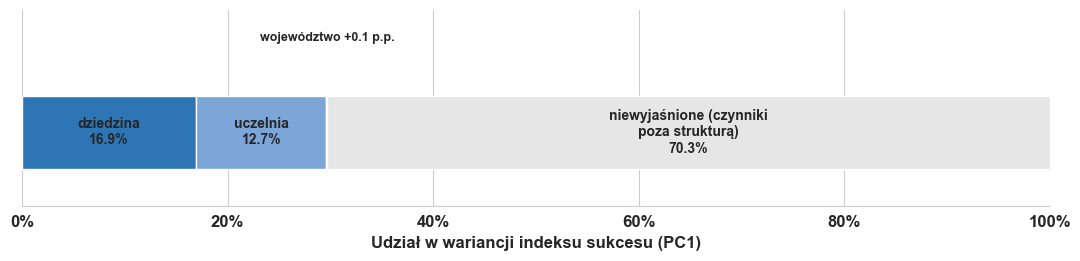


--- B. Model mieszany (MixedLM): ICC uczelni ---
  Wariancja między-uczelniana: 1.233
  Wariancja resztowa:          6.447
  ICC = 0.161  → tyle wariancji sukcesu (po uwzględnieniu dziedziny)
        leży na poziomie UCZELNI, nie pojedynczego kierunku.


In [34]:
# ==========================================
# 27. DEKOMPOZYCJA WARIANCJI — co i NA ILE definiuje sukces?
# ==========================================
# Pytanie badawcze wprost: jaka część losów absolwenta leży na poziomie DZIEDZINY,
# UCZELNI, REGIONU, a ile zostaje niewyjaśnione? Dwa komplementarne podejścia.


# Zmienna zależna: ciągły indeks sukcesu = PC1 (data-driven, policzony w cz. I).
# Jeśli PCA1 jest w df_analiza, używamy go; inaczej fallback do premia_WWZ.
dekomp_df = df_model.copy()
if 'PCA1' in dekomp_df.columns:
    dekomp_df['sukces'] = dekomp_df['PCA1']
    print("Zmienna sukcesu: PCA1 (pierwsza składowa = indeks sukcesu rynkowego)")
else:
    dekomp_df['sukces'] = dekomp_df['premia_WWZ']
    print("Zmienna sukcesu: premia_WWZ (PCA1 niedostępne)")

# Czyszczenie nazw do formuły
import re as _re
def _cl(c): return 'w_' + _re.sub(r'[^0-9A-Za-z]', '_', str(c))
for src_c in ['P_DZIEDZINA', 'P_NAZWA_UCZELNI', 'P_WOJ']:
    if src_c in dekomp_df.columns:
        dekomp_df[_cl(src_c)] = dekomp_df[src_c].astype(str)

# --- A. Sekwencyjne R^2: ile wariancji DOKŁADA każdy poziom ---
print("\n--- A. Sekwencyjny przyrost wyjaśnionej wariancji (R^2) ---")
poziomy = [('dziedzina', f'C({_cl("P_DZIEDZINA")})')]
if 'P_NAZWA_UCZELNI' in dekomp_df.columns:
    poziomy.append(('uczelnia', f'C({_cl("P_NAZWA_UCZELNI")})'))
if 'P_WOJ' in dekomp_df.columns:
    poziomy.append(('województwo', f'C({_cl("P_WOJ")})'))

wyniki_dekomp = []
terms, prev_r2 = [], 0.0
for nazwa, term in poziomy:
    terms.append(term)
    r2 = smf.ols('sukces ~ ' + ' + '.join(terms), dekomp_df).fit().rsquared
    wyniki_dekomp.append((nazwa, r2, r2 - prev_r2))
    print(f"  {nazwa:16s} R^2 = {r2:.3f}   (przyrost {r2 - prev_r2:+.3f})")
    prev_r2 = r2
print("  Reszta do 1.0 = wariancja NIEwyjaśniona przez te poziomy (czynniki indywidualne).")

# --- Wykres do pracy: budżet wariancji indeksu sukcesu (Rys. 5.8) ---
segmenty = [(nazwa, przyrost) for (nazwa, _, przyrost) in wyniki_dekomp]
segmenty.append(('niewyjaśnione (czynniki\npoza strukturą)', 1.0 - wyniki_dekomp[-1][1]))
kolory = ['#2E75B6', '#7CA6D8', '#B4C7E7', '#E7E6E6'][:len(segmenty)]

fig, ax = plt.subplots(figsize=(11, 2.8))
left = 0.0
for (lab, val), col in zip(segmenty, kolory):
    ax.barh(0, val, left=left, color=col, edgecolor='white', height=0.6)
    if val >= 0.06:   # etykieta w środku segmentu
        ax.text(left + val/2, 0, f'{lab}\n{val*100:.1f}%',
                ha='center', va='center', fontsize=10, fontweight='bold')
    else:             # wąski segment: adnotacja nad paskiem
        ax.annotate(f'{lab} +{val*100:.1f} p.p.',
                    xy=(left + val/2, 0.30), xytext=(left + val/2, 0.75),
                    ha='center', fontsize=9,
                    arrowprops=dict(arrowstyle='-', lw=0.9))
    left += val

ax.set_xlim(0, 1); ax.set_ylim(-0.6, 1.0)
ax.set_yticks([])
ax.set_xticks([0, .2, .4, .6, .8, 1.0])
ax.set_xticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])
ax.set_xlabel('Udział w wariancji indeksu sukcesu (PC1)')
for sp in ('top', 'right', 'left'):
    ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig('rys5_8_dekompozycja.png', dpi=200, bbox_inches='tight')
plt.show()
# --- B. Model mieszany: uczelnia jako efekt losowy, ICC ---
if 'P_NAZWA_UCZELNI' in dekomp_df.columns:
    print("\n--- B. Model mieszany (MixedLM): ICC uczelni ---")
    try:
        md = smf.mixedlm(f'sukces ~ C({_cl("P_DZIEDZINA")})',
                         dekomp_df, groups=dekomp_df[_cl('P_NAZWA_UCZELNI')])
        mfit = md.fit(reml=True)
        v_ucz = float(mfit.cov_re.iloc[0, 0])
        v_res = float(mfit.scale)
        icc = v_ucz / (v_ucz + v_res)
        print(f"  Wariancja między-uczelniana: {v_ucz:.3f}")
        print(f"  Wariancja resztowa:          {v_res:.3f}")
        print(f"  ICC = {icc:.3f}  → tyle wariancji sukcesu (po uwzględnieniu dziedziny)")
        print(f"        leży na poziomie UCZELNI, nie pojedynczego kierunku.")
    except Exception as e:
        print(f"  MixedLM nie zbiegł ({e}). Zostań przy sekwencyjnym R^2 z części A.")

Macierz przejść między ŚCIEŻKAMI (wiersz = rok t, kolumna = rok t+1):
                                Trudny start  Stabilny etat  B2B / samozatrudnienie  Przeciętni / ryzyko bezrobocia  Elita zarobkowa
Trudny start                            0.58           0.18                    0.07                            0.16             0.01
Stabilny etat                           0.00           0.83                    0.03                            0.04             0.10
B2B / samozatrudnienie                  0.02           0.09                    0.78                            0.05             0.06
Przeciętni / ryzyko bezrobocia          0.03           0.31                    0.07                            0.58             0.01
Elita zarobkowa                         0.00           0.10                    0.03                            0.00             0.87

Średnia STABILNOŚĆ (przekątna): 0.73
  Trudny start                     zostaje: 0.58
  Stabilny etat                    zostaje: 0

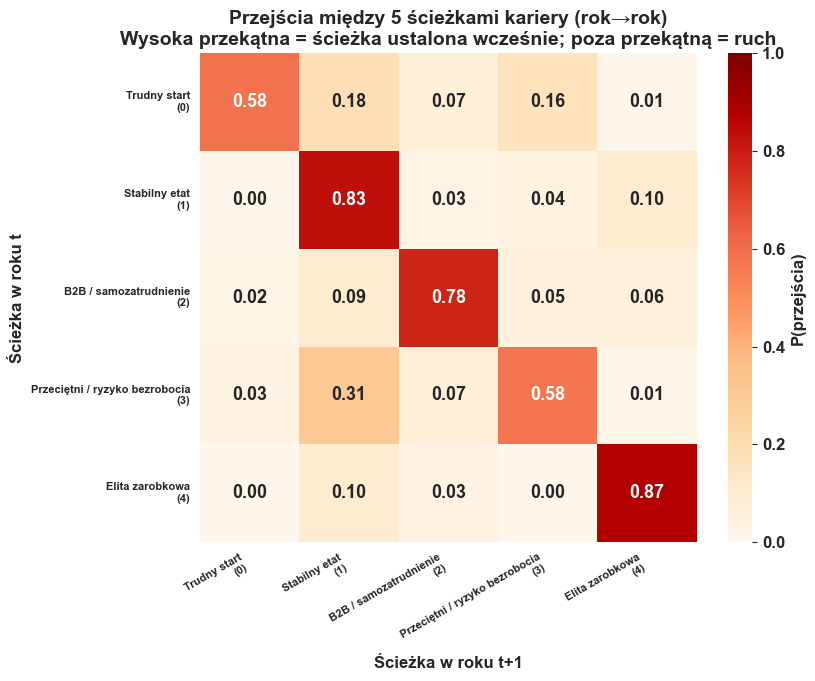


INTERPRETACJA:
  Patrz, KTÓRE ścieżki są trwałe (wysoka przekątna), a które przejściowe.
  Częste przejścia z X do Y = X bywa etapem w drodze do Y (np. trudny start → stabilny etat).

ZASTRZEŻENIE (do pracy): cechy WWZ/WWB są z natury trwałe w czasie, więc część
stabilności jest wbudowana w dane (autokorelacja), nie tylko 'realny' brak ruchu.


In [35]:
# ==========================================
# 28. TRAJEKTORIE NA 5 ORYGINALNYCH ŚCIEŻKACH — czy absolwent wędruje między nimi?
# ==========================================
# Kierunek przypisujemy do jednej z pięciu ścieżek OSOBNO w każdym roku P1..P5.
# Model finalny (Klaster_k5) był liczony w przestrzeni PCA, ale do podstawiania
# wartości z kolejnych lat potrzebne są centroidy w pełnej przestrzeni cech —
# dlatego dopasowujemy tu nowy KMeans k=5 na pełnym standaryzowanym X i mapujemy
# jego etykiety na numerację finalną po największym pokryciu. Stany są więc
# przybliżeniem ścieżek z części I w pełnej przestrzeni cech.
#
# Mechanika: dla każdego roku p budujemy wektor w pełnej przestrzeni cech (cechy
# szeregowe biorą wartość z _Pp; agregaty CZAS/STUDIA są stałe w czasie), skalujemy
# tym samym scalerem i przypisujemy do najbliższego centroidu.


# --- 1. Scaler i KMeans k=5 na PEŁNEJ przestrzeni 'features' ---
# (Deterministyczne: random_state=42. Numeracja etykiet może się różnić od kolumny
# 'Klaster', stąd mapowanie poniżej.)
_X_full = df_analiza[features].astype(float)
_scaler_traj = SS().fit(_X_full)
_Xs_full = _scaler_traj.transform(_X_full)
_km_traj = KMeans(n_clusters=docelowe_k, random_state=42, n_init=10).fit(_Xs_full)

# Zgodność z istniejącym podziałem: jeśli etykiety się różnią od df_analiza['Klaster']
# (przez inną numerację), mapujemy nowe etykiety na stare przez najczęstsze pokrycie.
_ref = df_analiza['Klaster'].values
_new = _km_traj.labels_
_remap = {}
for nl in range(docelowe_k):
    mask = _new == nl
    if mask.sum() > 0:
        _remap[nl] = pd.Series(_ref[mask]).mode().iloc[0]
# jeśli mapowanie nie jest bijekcją, zostaw surowe (i tak liczy ruch, nie nazwy)
if len(set(_remap.values())) == docelowe_k:
    _apply = lambda arr: np.array([_remap[a] for a in arr])
else:
    _apply = lambda arr: arr
    print("UWAGA: nie udało się 1:1 zmapować na oryginalną numerację — używam surowych etykiet.")

# --- 2. Bazy cech szeregowych (mają warianty _P1.._P5) i agregaty (stałe w czasie) ---
def _base_of(feat):
    # 'P_WWZ_DOSW_P3' -> 'P_WWZ_DOSW'; agregat bez _P# -> sam siebie
    parts = feat.split('_')
    return '_'.join(parts[:-1]) if (parts[-1].startswith('P') and parts[-1][1:].isdigit()) else feat

_seria_bases = sorted({_base_of(f) for f in features
                       if _base_of(f) != f})           # te, które mają _P#
_agg_feats   = [f for f in features if _base_of(f) == f]  # bez roku (CZAS, STUDIA)

# --- 3. Zbuduj wektor każdego roku w pełnej przestrzeni 'features' i przypisz do ścieżki ---
def _year_matrix(p):
    M = pd.DataFrame(index=df_analiza.index, columns=features, dtype=float)
    for f in features:
        if f in _agg_feats:
            M[f] = df_analiza[f]
        else:
            src = f'{_base_of(f)}_P{p}'
            M[f] = df_analiza[src] if src in df_analiza.columns else df_analiza[f]
    return M

lata = list(range(1, 6))
stany = {}
for p in lata:
    Mp = _year_matrix(p)
    Xp = _scaler_traj.transform(Mp[features])
    stany[p] = _apply(_km_traj.predict(Xp))

wide = pd.DataFrame(stany, index=df_analiza.index)   # wiersz=kierunek, kolumna=rok, wartość=ścieżka
sciezki_ids = sorted(df_analiza['Klaster'].unique())
n_sciezek = len(sciezki_ids)

# --- 4. Macierz przejść 5x5 (rok t -> t+1) ---
T = np.zeros((n_sciezek, n_sciezek))
pos = {c: i for i, c in enumerate(sciezki_ids)}
for i in range(len(lata) - 1):
    a_col, b_col = lata[i], lata[i + 1]
    for _, r in wide[[a_col, b_col]].dropna().iterrows():
        T[pos[r[a_col]], pos[r[b_col]]] += 1
Tn = T / T.sum(axis=1, keepdims=True)

nazwy = [f'{etykiety_map.get(c, c)}\n({c})' for c in sciezki_ids]
print("Macierz przejść między ŚCIEŻKAMI (wiersz = rok t, kolumna = rok t+1):")
print(pd.DataFrame(Tn, index=[etykiety_map.get(c, c) for c in sciezki_ids],
                   columns=[etykiety_map.get(c, c) for c in sciezki_ids]).round(2).to_string())

print(f"\nŚrednia STABILNOŚĆ (przekątna): {np.diag(Tn).mean():.2f}")
for c in sciezki_ids:
    print(f"  {etykiety_map.get(c, c):32s} zostaje: {Tn[pos[c], pos[c]]:.2f}")
stale = (wide.nunique(axis=1) == 1).sum()
print(f"\nKierunki przez całe 5 lat w JEDNEJ ścieżce: {stale}/{len(wide)} "
      f"({stale/len(wide)*100:.0f}%)")

# --- 5. Wizualizacja ---
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(Tn, annot=True, fmt='.2f', cmap='OrRd', vmin=0, vmax=1,
            xticklabels=nazwy, yticklabels=nazwy, ax=ax,
            cbar_kws={'label': 'P(przejścia)'})
ax.set_title('Przejścia między 5 ścieżkami kariery (rok→rok)\n'
             'Wysoka przekątna = ścieżka ustalona wcześnie; poza przekątną = ruch')
ax.set_xlabel('Ścieżka w roku t+1'); ax.set_ylabel('Ścieżka w roku t')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout(); plt.show()

print("\nINTERPRETACJA:")
print("  Patrz, KTÓRE ścieżki są trwałe (wysoka przekątna), a które przejściowe.")
print("  Częste przejścia z X do Y = X bywa etapem w drodze do Y (np. trudny start → stabilny etat).")
print("\nZASTRZEŻENIE (do pracy): cechy WWZ/WWB są z natury trwałe w czasie, więc część")
print("stabilności jest wbudowana w dane (autokorelacja), nie tylko 'realny' brak ruchu.")

Entropia FCM (rozmycie przestrzenne) a wędrówka w czasie:
  Kierunki STABILNE w czasie (1 stan):   średnia entropia = 0.957  (N=7815)
  Kierunki WĘDRUJĄCE w czasie (>1 stan):  średnia entropia = 0.968  (N=29365)

  Test Manna-Whitneya (czy wędrujące mają WYŻSZĄ entropię): p = 6.01e-03
  => POTWIERDZONE: kierunki graniczne w przestrzeni FCM to te same,
     które wędrują między ścieżkami w czasie. Rozmycie i ruch to jedno zjawisko.


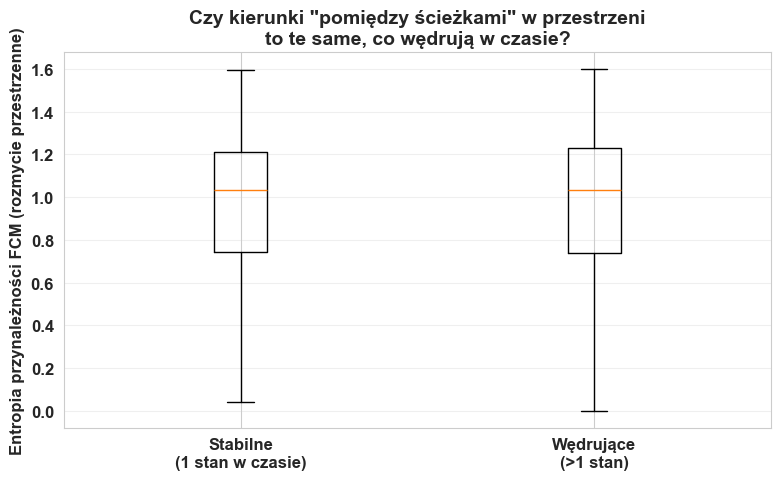

In [36]:
# ==========================================
# 28b. ROZMYCIE PRZESTRZENNE (FCM) vs WĘDRÓWKA W CZASIE (trajektorie)
# ==========================================
# Hipoteza: kierunki GRANICZNE w przestrzeni (wysoka entropia FCM) to te same,
# które WĘDRUJĄ między ścieżkami w czasie. Jeśli się pokrywają — rozmycie i ruch
# to dwa oblicza tego samego: niektóre kierunki nie mają jednej wyraźnej ścieżki.
if 'wide' in dir() and 'FCM_entropia' in df_analiza.columns:
    # liczba różnych stanów, w których kierunek był przez P1..P5 (1 = stabilny, >1 = wędrował)
    n_stanow = wide.nunique(axis=1)
    wspolne = df_analiza.loc[wide.index].copy()
    wspolne['n_stanow_w_czasie'] = n_stanow.values

    # porównanie entropii FCM: kierunki stabilne (1 stan) vs wędrujące (>1 stan)
    ent_stabilne = wspolne.loc[wspolne['n_stanow_w_czasie'] == 1, 'FCM_entropia']
    ent_wedrujace = wspolne.loc[wspolne['n_stanow_w_czasie'] > 1, 'FCM_entropia']

    print("Entropia FCM (rozmycie przestrzenne) a wędrówka w czasie:")
    print(f"  Kierunki STABILNE w czasie (1 stan):   średnia entropia = {ent_stabilne.mean():.3f}  (N={len(ent_stabilne)})")
    print(f"  Kierunki WĘDRUJĄCE w czasie (>1 stan):  średnia entropia = {ent_wedrujace.mean():.3f}  (N={len(ent_wedrujace)})")

    from scipy import stats as _st
    if len(ent_stabilne) > 1 and len(ent_wedrujace) > 1:
        t, p = _st.mannwhitneyu(ent_wedrujace, ent_stabilne, alternative='greater')
        print(f"\n  Test Manna-Whitneya (czy wędrujące mają WYŻSZĄ entropię): p = {p:.2e}")
        if p < 0.05:
            print("  => POTWIERDZONE: kierunki graniczne w przestrzeni FCM to te same,")
            print("     które wędrują między ścieżkami w czasie. Rozmycie i ruch to jedno zjawisko.")
        else:
            print("  => Brak istotnego związku — rozmycie przestrzenne i wędrówka to różne zjawiska.")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.boxplot([ent_stabilne.dropna(), ent_wedrujace.dropna()],
               labels=['Stabilne\n(1 stan w czasie)', 'Wędrujące\n(>1 stan)'], showfliers=False)
    ax.set_ylabel('Entropia przynależności FCM (rozmycie przestrzenne)')
    ax.set_title('Czy kierunki "pomiędzy ścieżkami" w przestrzeni\nto te same, co wędrują w czasie?')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Potrzebne: 'wide' (z sekcji 28) i 'FCM_entropia' (z sekcji 11d). Uruchom oba najpierw.")

In [37]:
# ==========================================
# 29. STATYSTYKI OPISOWE ZMIENNYCH (tabele do rozdziału o danych)
# ==========================================
# Zmienne wynikowe z df_analiza; strukturalne (P_N, P_PROC_DOSW) z df_model.
stat_vars = ['P_WWZ_DOSW_P1','P_WWZ_DOSW_P5','P_WWZ_NDOSW_P1','P_WWZ_NDOSW_P5',
             'P_WWB_DOSW_P1','P_WWB_DOSW_P5','P_WWB_NDOSW_P1','P_WWB_NDOSW_P5',
             'P_CZY_ETAT_DOSW_P5','P_CZY_SAMOZ_DOSW_P5',
             'P_CZAS_PRACA_DOSW','P_CZAS_PRACA_NDOSW','P_PROC_STUDIA']
tab3 = df_analiza[stat_vars].agg(['count','mean','std','median','min','max']).T.round(3)
print(tab3.to_string())
# strukturalne (z df_model po sekcji 18):
print(df_model[['P_N','P_PROC_DOSW']].agg(['count','mean','std','median','min','max']).T.round(2).to_string())

                       count    mean     std  median   min     max
P_WWZ_DOSW_P1        37180.0   0.714   0.246    0.68  0.00    3.42
P_WWZ_DOSW_P5        37180.0   0.964   0.315    0.91  0.02    3.66
P_WWZ_NDOSW_P1       37180.0   0.508   0.184    0.48  0.00    5.15
P_WWZ_NDOSW_P5       37180.0   0.832   0.266    0.78  0.03    7.11
P_WWB_DOSW_P1        37180.0   0.602   0.857    0.35  0.00   19.86
P_WWB_DOSW_P5        37180.0   0.414   0.931    0.05  0.00   24.10
P_WWB_NDOSW_P1       37180.0   1.120   1.247    0.77  0.00   23.80
P_WWB_NDOSW_P5       37180.0   0.665   1.108    0.35  0.00   30.53
P_CZY_ETAT_DOSW_P5   37180.0  81.209  15.115   83.30  0.00  100.00
P_CZY_SAMOZ_DOSW_P5  37180.0  15.090  14.383   12.50  0.00  100.00
P_CZAS_PRACA_DOSW    37180.0   3.735   4.479    2.00  0.00   47.67
P_CZAS_PRACA_NDOSW   37180.0  10.918   6.630    9.68  0.00   49.33
P_PROC_STUDIA        37180.0  48.388  30.718   47.40  0.00  100.00
               count   mean    std  median   min     max
P_N  

In [38]:
# ==========================================
# 30. LICZBY CYTOWANE W TEKŚCIE PRACY — jeden przebieg
# ==========================================
# Zbiera wartości wstawiane do tabel 4.1-4.5 oraz wersje środowiska obliczeniowego.
import sklearn, numpy, pandas, matplotlib, scipy   # obiekty modułów do odczytu wersji
print("Python:", sys.version.split()[0])
for m in [numpy, pandas, sklearn, scipy, matplotlib, umap, sm, shap]:
    print(f"  {m.__name__}: {m.__version__}")

print("\nUczelnie:", df_analiza['P_NAZWA_UCZELNI'].nunique())
print("Roczniki:", int(df['P_ROKDYP'].min()), "-", int(df['P_ROKDYP'].max()))

print("\nTabela 4.1 (przestrzen PCA):")
for k in [2, 3, 4, 5, 6]:
    km = KMeans(k, random_state=42, n_init=10).fit(X_pca_reduced)
    print(f"  k={k}: sil={silhouette_score(X_pca_reduced, km.labels_):.3f}"
          f"  DB={davies_bouldin_score(X_pca_reduced, km.labels_):.3f}"
          f"  CH={calinski_harabasz_score(X_pca_reduced, km.labels_):.0f}"
          f"  WCSS={km.inertia_:.0f}")

print("\nLicznosci sciezek (Tabela 4.3):")
print(df_analiza['Klaster_k5'].map(etykiety_map).value_counts())

ct = pd.crosstab(df_analiza['P_DZIEDZINA'], df_analiza['Klaster_k5'])
chi2, pv, dof, _ = stats.chi2_contingency(ct)
V = (chi2 / (ct.values.sum() * (min(ct.shape) - 1))) ** 0.5
print(f"\n4.4: chi2={chi2:.0f}, df={dof}, p={pv:.2e}, V Cramera={V:.3f}")

print("\n4.5 premia per sciezka (srednie):")
print(df_analiza.groupby(df_analiza['Klaster_k5'].map(etykiety_map))[['premia_WWZ']].mean().round(3))

Python: 3.12.0
  numpy: 2.4.4
  pandas: 3.0.2
  sklearn: 1.8.0
  scipy: 1.17.1
  matplotlib: 3.10.9
  umap: 0.5.12
  statsmodels.api: 0.14.6
  shap: 0.52.0

Uczelnie: 463
Roczniki: 2014 - 2023

Tabela 4.1 (przestrzen PCA):
  k=2: sil=0.210  DB=1.796  CH=7540  WCSS=1011512
  k=3: sil=0.176  DB=1.865  CH=6953  WCSS=885454
  k=4: sil=0.163  DB=1.720  CH=6461  WCSS=799683
  k=5: sil=0.143  DB=1.797  CH=5868  WCSS=745785
  k=6: sil=0.138  DB=1.792  CH=5392  WCSS=705206

Licznosci sciezek (Tabela 4.3):
Klaster_k5
Stabilny etat                     11649
Przeciętni / ryzyko bezrobocia     9969
Trudny start                       8265
B2B / samozatrudnienie             4444
Elita zarobkowa                    2853
Name: count, dtype: int64

4.4: chi2=9651, df=28, p=0.00e+00, V Cramera=0.255

4.5 premia per sciezka (srednie):
                                premia_WWZ
Klaster_k5                                
B2B / samozatrudnienie               0.172
Elita zarobkowa                      0.284
Pr